# Detecting the Language of Greenwashing: Specificity Classification of Climate Disclosures

**Course:** Advanced Methods in Natural Language Processing

**Authors:** Cameron Armour, Marco Canal, Michael Duarte Gonçalves, Mircea-Adrian Guinea

**Repository:** `BSE_greenwashing-detection-nlp`

**Task:** Binary text classification of corporate climate-disclosure paragraphs as **specific vs non-specific** (the ClimateBERT "cheap talk" specificity task of Bingler et al.), studied under a 32-label few-shot constraint with augmentation, LLM methods and model distillation.

**Dataset:** `climatebert/climate_specificity` on the HuggingFace Hub (1,000 train / 320 test, human-annotated).

---

### AI-use disclosure (required by the rubric)
> All code in this notebook was generated with the assistance of an AI tool (Claude). The analytical cells were written by us. This paragraph is the complete declaration of AI use in the notebook. AI use is not annotated again, cell by cell, in order to avoid repetition of what was just stated


---

## Part 0: Setup

This section establishes functions that are re-used throughout the analysis and loads the dataset (discussed more in Part 1).

In [1]:
%matplotlib inline
import os
import random
import time
import warnings
from pathlib import Path
import pandas as pd
from textwrap import fill
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import numpy as np

warnings.filterwarnings("ignore")
# Keep the outputs clean: silence the library load-time advisory warnings.
import logging as _logging

os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
_logging.getLogger("transformers").setLevel(_logging.ERROR)
try:
    import transformers

    transformers.logging.set_verbosity_error()
except Exception:
    pass
try:
    import datasets as _datasets

    _datasets.logging.set_verbosity_error()
except Exception:
    pass

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch

    torch.backends.quantized.engine = (
        "qnnpack"  # int8 backend for Part 4 (Apple Silicon)
    )

    torch.manual_seed(SEED)
    if torch.backends.mps.is_available():
        DEVICE = "mps"
    elif torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        DEVICE = "cuda"
    else:
        DEVICE = "cpu"
except Exception:
    DEVICE = "cpu"

try:
    from transformers import set_seed as hf_set_seed

    hf_set_seed(SEED)
except Exception:
    pass

# FAST_MODE shrinks epochs so the notebook runs on a laptop. Set False to reproduce full numbers.
FAST_MODE = True
EPOCHS = 3 if FAST_MODE else 5
FS_EPOCHS = 10 if FAST_MODE else 20  # Part-2 few-sample runs train longer
BATCH_SIZE = 16
MAX_LEN = 256  # paragraphs: median ~64 words, up to ~450
# Base encoder: what ClimateBERT itself is built on. Domain-matched alternative:
# climatebert/distilroberta-base-climate-f
BASE_MODEL = "distilroberta-base"


# The dataset loads from the HuggingFace Hub, so reading the notebook needs no local
# files. The folders below only hold the cached LLM responses (so the LLM cells rerun
# without an API key) and the saved figures; they sit alongside this notebook's folder.
PROJECT_ROOT = Path.cwd().parent
GEN_DIR = PROJECT_ROOT / "data" / "cache" / "generated"
OUT_DIR = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR = PROJECT_ROOT / "outputs" / "tables"
for d in (GEN_DIR, OUT_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(
    "Device:",
    DEVICE,
    "| FAST_MODE:",
    FAST_MODE,
    "| epochs:",
    EPOCHS,
    "| base:",
    BASE_MODEL,
)

from sklearn.metrics import classification_report, confusion_matrix, f1_score


def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


def _torch_dataset(texts, labels, tokenizer):
    import torch

    enc = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )

    class DS(torch.utils.data.Dataset):
        def __len__(self):
            return len(labels)

        def __getitem__(self, i):
            item = {k: v[i] for k, v in enc.items()}
            item["labels"] = torch.tensor(labels[i], dtype=torch.long)
            return item

    return DS()


def train_eval(
    train_texts,
    train_labels,
    test_texts,
    test_labels,
    base=BASE_MODEL,
    epochs=EPOCHS,
    lr=2e-5,
    label="",
    seed=SEED,
):
    """Fine-tune base and return (macro_f1, predictions, model, tokenizer)."""
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        Trainer,
        TrainingArguments,
    )

    tok = AutoTokenizer.from_pretrained(base)
    model = AutoModelForSequenceClassification.from_pretrained(
        base,
        num_labels=len(LABELS),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )
    args = TrainingArguments(
        output_dir=str(OUT_DIR / f"run_{label or 'tmp'}"),
        num_train_epochs=epochs,
        per_device_train_batch_size=BATCH_SIZE,
        learning_rate=lr,
        logging_strategy="no",
        save_strategy="no",
        report_to="none",
        disable_tqdm=True,
        log_level="error",
        seed=seed,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=_torch_dataset(train_texts, train_labels, tok),
    )
    trainer.train()
    preds = trainer.predict(_torch_dataset(test_texts, test_labels, tok))
    y_pred = preds.predictions.argmax(axis=1)
    f1 = macro_f1(test_labels, y_pred)
    print(f"[{label}] macro-F1 = {f1:.4f}  (train n={len(train_texts)})")
    return f1, y_pred, model, tok


RESULTS = {}
PREDS = {}  # method -> test predictions (label-ids), parallel to RESULTS  # method name -> macro-F1

# Investigation toolkit. Our question runs: is "specific" hard because the model fails or because the labels
# are ambiguous and what does that imply about fine-tuning a small model versus prompting a large one? These
# helpers turn each qualitative claim in the analysis into a number we can point at.
import numpy as np
import pandas as pd


def errors_for_class(y_true, y_pred, texts, klass="specific", n=20):
    """Test rows where gold == klass but the model missed it (the hard direction)."""
    cid = LABEL2ID[klass]
    rows = [
        {
            "idx": i,
            "gold": ID2LABEL[y_true[i]],
            "pred": ID2LABEL[y_pred[i]],
            "text": texts[i][:160],
        }
        for i in range(len(y_true))
        if y_true[i] == cid and y_pred[i] != cid
    ]
    print(
        f"{len(rows)} '{klass}' paragraphs missed (of {sum(t == cid for t in y_true)} gold-{klass})."
    )
    return pd.DataFrame(rows).head(n)


def disagreement(pred_dict, y_true, texts, n=25):
    """Rows where every method in pred_dict AGREES with the others but all contradict gold.
    These are the 'is the gold label even right?' candidates - the fuzzy-label evidence."""
    keys = list(pred_dict)
    rows = []
    for i in range(len(y_true)):
        vals = {pred_dict[k][i] for k in keys}
        if len(vals) == 1 and next(iter(vals)) != y_true[i]:
            rows.append(
                {
                    "idx": i,
                    "gold": ID2LABEL[y_true[i]],
                    "all_say": ID2LABEL[next(iter(vals))],
                    "text": texts[i][:160],
                }
            )
    print(
        f"{len(rows)} rows where {keys} all agree with each other yet contradict the gold label."
    )
    return pd.DataFrame(rows).head(n)


def paired_bootstrap(y_true, predA, predB, n=1000, seed=SEED):
    """95% CI on macro-F1(B) - macro-F1(A) by paired test-set resampling. >0 favours B."""
    from sklearn.metrics import f1_score

    y_true, predA, predB = np.array(y_true), np.array(predA), np.array(predB)
    rng = np.random.default_rng(seed)
    N = len(y_true)
    diffs = []
    base = f1_score(y_true, predB, average="macro") - f1_score(
        y_true, predA, average="macro"
    )
    for _ in range(n):
        idx = rng.integers(0, N, N)
        diffs.append(
            f1_score(y_true[idx], predB[idx], average="macro")
            - f1_score(y_true[idx], predA[idx], average="macro")
        )
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    verdict = (
        "B clearly better"
        if lo > 0
        else "A clearly better"
        if hi < 0
        else "NOT distinguishable (CI crosses 0)"
    )
    print(
        f"macro-F1 diff (B-A) = {base:+.4f}, 95% CI [{lo:+.4f}, {hi:+.4f}]  ->  {verdict}"
    )
    return base, lo, hi


def synth_vs_real(real_texts, synth_texts):
    """Is the LLM-generated data a free lunch? Compare length, lexical richness, vocab overlap."""

    def stats(ts):
        toks = [t.lower().split() for t in ts]
        allw = [w for x in toks for w in x]
        return (
            np.mean([len(x) for x in toks]),
            len(set(allw)) / max(1, len(allw)),
            set(allw),
        )

    rl, rttr, rv = stats(real_texts)
    sl, sttr, sv = stats(synth_texts)
    print(f"             mean_len   type-token-ratio")
    print(f"  real        {rl:6.1f}        {rttr:.3f}")
    print(f"  synthetic   {sl:6.1f}        {sttr:.3f}")
    print(
        f"  share of synthetic vocabulary that also appears in the real training text: {len(rv & sv) / max(1, len(sv)):.1%}"
    )
    return {
        "real_len": rl,
        "synth_len": sl,
        "real_ttr": rttr,
        "synth_ttr": sttr,
        "vocab_overlap": len(rv & sv) / max(1, len(sv)),
    }


def perclass_delta(y_true, pred_a, pred_b, names=("fp32", "int8")):
    """Per-class F1 for two models + the delta, plus the confusion of the second. Where does it hurt?"""
    from sklearn.metrics import f1_score, confusion_matrix

    out = []
    for cid, lab in ID2LABEL.items():
        bt = [1 if t == cid else 0 for t in y_true]
        fa = f1_score(bt, [1 if p == cid else 0 for p in pred_a])
        fb = f1_score(bt, [1 if p == cid else 0 for p in pred_b])
        out.append(
            {
                "class": lab,
                names[0]: round(fa, 3),
                names[1]: round(fb, 3),
                "delta": round(fb - fa, 3),
            }
        )
    df = pd.DataFrame(out)
    print(df.to_string(index=False))
    print(f"\nconfusion ({names[1]}), rows=true / cols=pred [{LABELS}]:")
    print(confusion_matrix(y_true, pred_b, labels=[0, 1]))
    return df


# Convenience: load a cached LLM prediction column as label-ids aligned to the test set.
def llm_preds(kind, model):
    p = (ZS_DIR if kind == "zeroshot" else FS_DIR if kind == "fewshot" else GEN_DIR) / f"{kind}_{model}.csv"
    d = pd.read_csv(p).sort_values("idx")
    return d["pred"].map(LABEL2ID).tolist()


print(
    "investigation toolkit ready: errors_for_class, disagreement, paired_bootstrap, synth_vs_real, perclass_delta, llm_preds,\n"
    "  confidence_gap, prob_hist, difficulty_score, method_agreement_matrix, calibration_curve"
)

# --- confidence-magnitude lens: not just which method disagrees, but how sure each one is. ---
PROBS = {}  # method -> per-test-row max softmax probability (confidence in its own predicted label)


def bert_maxprob(model, tok, texts, bs=32):
    """Per-row (predicted_label_id list, max-softmax-prob list) for a fine-tuned BERT, aligned to texts."""
    import torch

    model = model.to(DEVICE).eval()
    pr, mx = [], []
    for i in range(0, len(texts), bs):
        enc = tok(
            texts[i : i + bs],
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            p = torch.softmax(model(**enc).logits, -1).cpu().numpy()
        pr += p.argmax(1).tolist()
        mx += [float(v) for v in p.max(1)]
    return pr, mx


def confidence_gap(a, b, threshold=0.3, n=12):
    """Rows where methods a and b predict the SAME label but their confidence differs by > threshold.
    Reads PREDS[a],PREDS[b] (labels) and PROBS[a],PROBS[b] (max-probs). The magnitude that plain
    disagreement misses: one model is sure, the other hedging, on the same answer."""
    pa, pb, ca, cb = PREDS[a], PREDS[b], PROBS[a], PROBS[b]
    rows = [
        {
            "idx": i,
            "label": ID2LABEL[pa[i]],
            "gold": ID2LABEL[TEST_LABELS[i]],
            f"{a}_conf": round(ca[i], 2),
            f"{b}_conf": round(cb[i], 2),
            "gap": round(abs(ca[i] - cb[i]), 2),
            "text": TEST_TEXTS[i][:140],
        }
        for i in range(len(pa))
        if pa[i] == pb[i] and abs(ca[i] - cb[i]) > threshold
    ]
    df = (
        pd.DataFrame(rows).sort_values("gap", ascending=False)
        if rows
        else pd.DataFrame()
    )
    print(
        f"{len(df)} rows where {a} and {b} agree on the label but differ in confidence by > {threshold}."
    )
    return df.head(n)


def prob_hist(names, path=None, bins=20):
    """Overlaid max-probability histograms. Overconfident-on-small-data -> mass piled near 1.0;
    better-calibrated -> more mass near 0.5 (the binary chance line)."""
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    for nm in names:
        if nm in PROBS:
            plt.hist(
                PROBS[nm],
                bins=bins,
                range=(0.5, 1.0),
                alpha=0.5,
                label=f"{nm} (n={len(PROBS[nm])})",
            )
    plt.xlabel("max softmax probability (confidence in predicted label)")
    plt.ylabel("test paragraphs")
    plt.title("Confidence distribution by method")
    plt.legend(fontsize=7)
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=130)
    plt.show()


# --- difficulty stratification, method redundancy and calibration. ---


def difficulty_score(text):
    """Combine 1b's two ambiguity lenses for one test paragraph. lex = |token_score| (small = lexically flat,
    no strong specific cue); nbr = NBR_DISAGREE for that row (large = its nearest neighbours disagree).
    'hard' = both at once: no surface cue AND a contested neighbourhood."""
    lex = abs(token_score(text))
    idx = TEST_TEXT2IDX.get(text)
    nbr = float(NBR_DISAGREE[idx]) if idx is not None else float("nan")
    return {
        "lex": round(lex, 3),
        "nbr": round(nbr, 3),
        "hard": lex < 0.05 and nbr > 0.4,
    }


def difficulty_score_at(i):
    """difficulty_score for test row i (the indexed convenience form)."""
    return difficulty_score(TEST_TEXTS[i])


def method_agreement_matrix(methods, kappa=True):
    """Pairwise method-vs-method agreement: macro-F1 treating the column method's predictions as ground
    truth and Cohen's kappa (chance-corrected). High off-diagonal => the two methods do the same thing."""
    from sklearn.metrics import f1_score, cohen_kappa_score

    methods = [m for m in methods if m in PREDS]
    F = pd.DataFrame(index=methods, columns=methods, dtype=float)
    K = pd.DataFrame(index=methods, columns=methods, dtype=float)
    for a in methods:
        for b in methods:
            F.loc[a, b] = (
                1.0 if a == b else f1_score(PREDS[b], PREDS[a], average="macro")
            )
            K.loc[a, b] = 1.0 if a == b else cohen_kappa_score(PREDS[a], PREDS[b])
    print("pairwise macro-F1 (column method treated as ground truth):")
    print(F.round(2).to_string())
    if kappa:
        print("\npairwise Cohen's kappa (label agreement, chance-corrected):")
        print(K.round(2).to_string())
    return (F, K) if kappa else F


def calibration_curve(method, n_bins=10, ax=None):
    """Reliability curve + expected calibration error (ECE) for a graded-probability method. Bins the
    predicted max-prob into n_bins over [0.5, 1.0] and compares mean confidence to empirical accuracy per
    bin. Categorical methods (PROBS pinned at the 1.0/0.5 fallback) have no graded signal -> skipped (nan)."""
    import numpy as np
    import matplotlib.pyplot as plt

    probs = np.array(PROBS[method])
    preds = np.array(PREDS[method])
    gold = np.array(TEST_LABELS)
    if set(np.unique(probs)).issubset({0.5, 1.0}):
        print(
            f"[{method}] categorical probabilities (1.0 fallback): calibration not defined, skipped."
        )
        return float("nan")
    correct = (preds == gold).astype(float)
    edges = np.linspace(0.5, 1.0, n_bins + 1)
    xs, ys, ece = [], [], 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (probs >= lo) & ((probs < hi) | (hi >= 1.0))
        if m.sum() == 0:
            continue
        conf, acc = probs[m].mean(), correct[m].mean()
        xs.append(conf)
        ys.append(acc)
        ece += (m.sum() / len(probs)) * abs(acc - conf)
    own = ax is None
    if own:
        plt.figure(figsize=(5, 5))
        ax = plt.gca()
    ax.plot([0.5, 1.0], [0.5, 1.0], "--", c="#999")
    ax.plot(xs, ys, "o-", label=f"{method} (ECE={ece:.3f})")
    ax.set_xlabel("predicted confidence")
    ax.set_ylabel("empirical accuracy")
    ax.legend(fontsize=7)
    if own:
        ax.set_title(f"Calibration: {method}")
        plt.tight_layout()
        plt.show()
    return float(ece)

Device: mps | FAST_MODE: True | epochs: 3 | base: distilroberta-base
investigation toolkit ready: errors_for_class, disagreement, paired_bootstrap, synth_vs_real, perclass_delta, llm_preds,
  confidence_gap, prob_hist, difficulty_score, method_agreement_matrix, calibration_curve


In [2]:
# ----------------------------------------------
# Load the dataset and conduct train/test split
# ----------------------------------------------

ds = load_dataset("climatebert/climate_specificity")

LABELS = ["non-specific", "specific"]  # matches the dataset ClassLabel order (0, 1)
LABEL2ID = {lab: i for i, lab in enumerate(LABELS)}
ID2LABEL = {i: lab for lab, i in LABEL2ID.items()}

train_df = ds["train"].to_pandas().rename(columns={"label": "label_id"})
test_df = ds["test"].to_pandas().rename(columns={"label": "label_id"})
for d in (train_df, test_df):
    d["label"] = d["label_id"].map(ID2LABEL)
    

# Carve a stratified validation set from train (the dataset has no val split).
tr_idx, val_idx = train_test_split(
    range(len(train_df)),
    test_size=0.15,
    stratify=train_df["label_id"],
    random_state=SEED,
)

pool_df = train_df.iloc[list(tr_idx)].reset_index(
    drop=True
)  # training / unlabelled pool (~850)
val_df = train_df.iloc[list(val_idx)].reset_index(drop=True)  # validation (~150)

TEST_TEXTS, TEST_LABELS = test_df["text"].tolist(), test_df["label_id"].tolist()
VAL_TEXTS, VAL_LABELS = val_df["text"].tolist(), val_df["label_id"].tolist()

print(f"pool(train): {len(pool_df)} | val: {len(val_df)} | test: {len(TEST_TEXTS)}")
print("test class balance:", dict(test_df["label"].value_counts()))

# index for difficulty_score's neighbour lookup
TEST_TEXT2IDX = {t: i for i, t in enumerate(TEST_TEXTS)}


pool(train): 850 | val: 150 | test: 320
test class balance: {'non-specific': np.int64(197), 'specific': np.int64(123)}


## Part 1 - Setting up the problem (1.5 pts)

### 1a. Bibliography and state of the art (0.25)

**Motivation and Business-case**

Climate and other sustainability-related factors are increasingly being incorporated into the investment decisions of retail investors, fund managers and the vast collection of financial actors. To manage climate risks, investors rely on corporate climate disclosures and are often subject to regulatory and internal compliance requirements that demand careful assessment of a company’s climate risks before being able to invest in it. However, climate disclosures can suffer from what the industry calls "greenwashing" – that is, the misrepresenting of the decisions/actions undertaken by a given company as "greener" than they, in fact, are. It's much easier to get away with greenwashing when a company's disclosures or commitments remain vague and non-specific compared to specific statements around which is much more difficult to manoeuvre.

In this context, our project uses NLP techniques to support investors and regulators in the early screening of potential greenwashing in corporate climate disclosures. In particular, following a path already marked by practitioners and academics alike, we classify disclosures around climate-related actions as either **specific** (concrete, quantified, checkable) or **non-specific** (vague). A precise-sounding claim can, of course, still be empty or false. Thus, our project does not directly identify greenwashing. Instead, specificity labelling provides an interpretable first-stage screening tool that regulators and investors can use to identify disclosures that require further review.

**Dataset** 

For this project, we use the `climatebert/climate_specificity` dataset. This dataset was built by Bingler, Kraus, Leippold & Webersinke for their climate-disclosure analysis (discussed more below). It contains 1320 hand-labelled corporate-report paragraphs, where each row is a climate-related paragraph from a corporate annual or sustainability report, labelled **specific** (concrete, quantified, verifiable detail, e.g. "we emitted 13.4 million tonnes CO2 of Scope 2") or **non-specific** (vague, generic language). We produce some examples below that clearly demonstrate the different types of climate commitments.

| Split | Rows |
|---|---|
| train | 1,000 |
| test  | 320  |

**Related work** 

Our project builds directly on the climate-disclosure specificity literature. Bingler et al. (2022) introduce the “cheap talk” framing, where, as mentioned, firms make climate-related statements that sound committed but lack concrete, verifiable detail. Bingler et al. (2024) then operationalise this as a specificity classification task, defining specificity in line with the IASB (2018) notion of materiality and providing the dataset and benchmark we use, which makes it the central reference for our classification setup and state-of-the-art comparison. In addition, Calamai et al. (2025) provide a very useful survey of the literature on classifying greenwashing using more or less recent NLP techniques. Finally, Plank (2022) shows that when labels involve subjective human judgement, disagreement should not always be treated as simple noise. This helps us reframing the hardest cases that we encounter in our project: the paragraphs models get "wrong" may be genuinely ambiguous rather than simple errors, which, ultimately, motivates us to treat label disagreement as a measure of task difficulty rather than noise to be eliminated.

**State of the Art** 

The relevant state-of-the-art benchmark is the released **ClimateBERT** specificity classifier, which reports a weighted-average F1 of approximately 0.77. This is only slightly above classical baselines, including Naive Bayes and SVM-based approaches, which achieve around 0.75–0.76. However, the original authors do not report macro-F1 for this task. Because we evaluate on macro-F1, which the original authors do not report and which is more demanding on an imbalanced dataset, our results are not directly comparable to their weighted-F1 figures. Hence, we make no claim to beat the published state of the art. Instead, we reproduce the ClimateBERT classifier and use it as our benchmark under this stricter, imbalance-aware metric (that is, macro-F1).

In [3]:
for idx in [10, 16]:
    row = train_df.loc[idx]
    print(f"\n{row['label'].upper()} EXAMPLE")
    print("-" * 80)
    print(fill(row["text"], width=90))


SPECIFIC EXAMPLE
--------------------------------------------------------------------------------
Offsetting our emissions Australian Ethical offsets emissions by purchasing carbon credits
in worthwhile projects. Emissions of 149.5 tCO2-e will be offset during FY15. Total
emissions calculated include greenhouse gases emissions from energy and from travel.
Projects that our carbon offset credits will assist are ‘Cookstove’ projects in Mali and
Cambodia. The projects replace high polluting traditional cookstoves with fuel efficient
stoves. Large volumes of wood and charcoal are required for the traditional cookstoves,
which contribute to CO2 emissions from burning these fuels, but also increased
desertification. The traditional stoves also contribute to indoor air pollution, which is
linked to respiratory and eye diseases.

NON-SPECIFIC EXAMPLE
--------------------------------------------------------------------------------
We want to contribute to the transition to a circular economy. 

### 1b. Dataset description and descriptive statistics (0.5)

The dataset has 1320 observations, split into 1000 training observations and 320 test observations. While this is a relatively small dataset, the labels were produced by the authors together with finance and sustainable-finance students, which lends them reasonable reliability and makes the dataset suitable for supervised classification. We begin, now, our EDA.

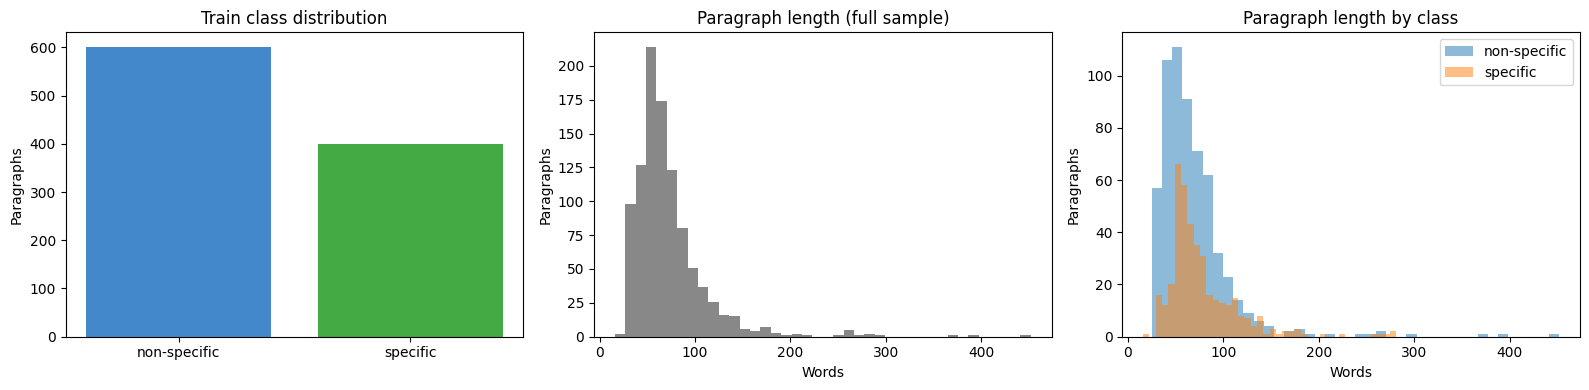


OVERALL DATASET SUMMARY


,Metric,Value
0,Train size,1000.0
1,Test size,320.0
2,Mean length (words),72.2
3,Median length (words),63.0
4,Minimum length (words),16.0
5,90th percentile length (words),113.0
6,Maximum length (words),452.0



MISSING/DUPLICATED DATA (0 indicates no issue)


text           0
label_id       0
label          0
text_length    0
dtype: int64

0

LENGTH BY CLASS


...


CLASS BALANCE


,label,Percentage
0,non-specific,60.1
1,specific,39.9



TRAIN/TEST CLASS BALANCE


,Train (%),Test (%)
label,,
non-specific,60.1,61.6
specific,39.9,38.4



SELECTED EXAMPLES OF LENGTH OUTLIERS

SHORTEST NON-SPECIFIC EXAMPLE
Length: 25 words
------------------------------------------------------------------------------------------
Additionally, specialists from the Corporate Responsibility department coordinate climate-
related research activities and support and facilitate climate risk and climate
opportunity management activities across the Group.

LONGEST NON-SPECIFIC EXAMPLE
Length: 452 words
------------------------------------------------------------------------------------------
44 National Australia Bank delayed in the 2020 financial year, due to COVID-19, but is
expected to be completed in the 2021 financial year. - Climate Measurement Standards
Initiative (CMSI) - The Group joined and supported this cross-sector industry initiative
which formed in the 2020 financial year. The CMSI includes representatives from across the
banking, insurance and investment sectors alongside pre-eminent Australian climate
scientists working togethe

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

vc = train_df["label"].value_counts().reindex(LABELS)

ax[0].bar(vc.index, vc.values, color=["#48c", "#4a4"])
ax[0].set_title("Train class distribution")
ax[0].set_ylabel("Paragraphs")

train_df["text_length"] = train_df["text"].str.split().str.len()
test_df["text_length"] = test_df["text"].str.split().str.len()

lengths = train_df["text_length"]

ax[1].hist(lengths, bins=40, color="#888")
ax[1].set_title("Paragraph length (full sample)")
ax[1].set_xlabel("Words")
ax[1].set_ylabel("Paragraphs")

for label in LABELS:
    subset_lengths = (
        train_df.loc[train_df["label"] == label, "text"].str.split().str.len()
    )
    ax[2].hist(subset_lengths, bins=40, alpha=0.5, label=label)

ax[2].set_title("Paragraph length by class")
ax[2].set_xlabel("Words")
ax[2].set_ylabel("Paragraphs")
ax[2].legend()

plt.tight_layout()
plt.show()



# Display basic statistics
summary = pd.DataFrame(
    {
        "Metric": [
            "Train size",
            "Test size",
            "Mean length (words)",
            "Median length (words)",
            "Minimum length (words)",
            "90th percentile length (words)",
            "Maximum length (words)",
        ],
        "Value": [
            len(train_df),
            len(test_df),
            round(lengths.mean(), 1),
            int(lengths.median()),
            int(lengths.min()),
            int(np.percentile(lengths, 90)),
            int(lengths.max()),
        ],
    }
)


class_balance = (
    (vc / vc.sum() * 100)
    .round(1)
    .rename("Percentage")
    .reset_index()
    .rename(columns={"index": "Class"})
)

length_by_class = (
    train_df.assign(text_length=lengths)
    .groupby("label")["text_length"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        **{"90th percentile length": lambda x: np.percentile(x, 90)},
        Maximum="max",
    )
    .round(1)
    .reset_index()
    .rename(columns={"label": "Class"})
)

print("\n" + "=" * 60)
print("OVERALL DATASET SUMMARY")
print("=" * 60)
display(summary)

print("\n" + "=" * 60)
print("MISSING/DUPLICATED DATA (0 indicates no issue)")
print("=" * 60)
display(train_df.isna().sum())
print(train_df["text"].duplicated().sum())

print("\n" + "=" * 60)
print("LENGTH BY CLASS")
print("=" * 60)
display(length_by_class)

print("\n" + "=" * 60)
print("CLASS BALANCE")
print("=" * 60)
display(class_balance)

print("\n" + "=" * 60)
print("TRAIN/TEST CLASS BALANCE")
print("=" * 60)
split_balance = pd.DataFrame(
    {
        "Train (%)": train_df["label"].value_counts(normalize=True).mul(100).round(1),
        "Test (%)": test_df["label"].value_counts(normalize=True).mul(100).round(1),
    }
).reindex(LABELS)

display(split_balance)

print("\n" + "=" * 60)
print("SELECTED EXAMPLES OF LENGTH OUTLIERS")
print("=" * 60)
for label in LABELS:
    label_df = train_df[train_df["label"] == label]

    examples = {
        "Shortest": label_df.sort_values("text_length").iloc[0],
        "Longest": label_df.sort_values("text_length", ascending=False).iloc[0],
    }

    for kind, row in examples.items():
        print("\n" + "=" * 90)
        print(f"{kind.upper()} {label.upper()} EXAMPLE")
        print(f"Length: {int(row['text_length'])} words")
        print("-" * 90)
        print(fill(row["text"], width=90))

The class distribution is slightly unbalanced. Around 60% of observations are labelled non-specific, while the remaining 40% are labelled specific (this imbalance is similar across the training and test sets). This imbalance guides our choice in terms of which metrics to use for evaluation of our models' performance. So, we privilege metrics that are more robust to imbalances than simple accuracy: namely, precision, recall and F1-score alongside overall accuracy.

The average paragraph is around 70 words (median 63), but the distribution is right-skewed, with most paragraphs being relatively short and a smaller number of much longer paragraphs. This pattern appears both in the full sample and inside each of our two classes. The 90th percentile is around 110 words, while the longest examples are considerably longer, reaching 281 words for the specific class and as much as 452 words for the non-specific class. These long-tail observations are important to notice and, then, to consider as very long paragraphs may contain multiple claims, background context or mixed levels of specificity which could make classification more difficult.

To ensure that these length outliers do not reflect data quality issues (which we would not expect to find given the origin of the dataset), we still inspect the shortest and longest examples from each class. The examples above appear relevant to the research question and do not seem to be misleading entries. As we see, the shortest specific example still contains a concrete climate-related commitment, while the longest examples appears to simply be detailed corporate disclosures. All good. We can now proceed in the next step of our EDA, at the word level.

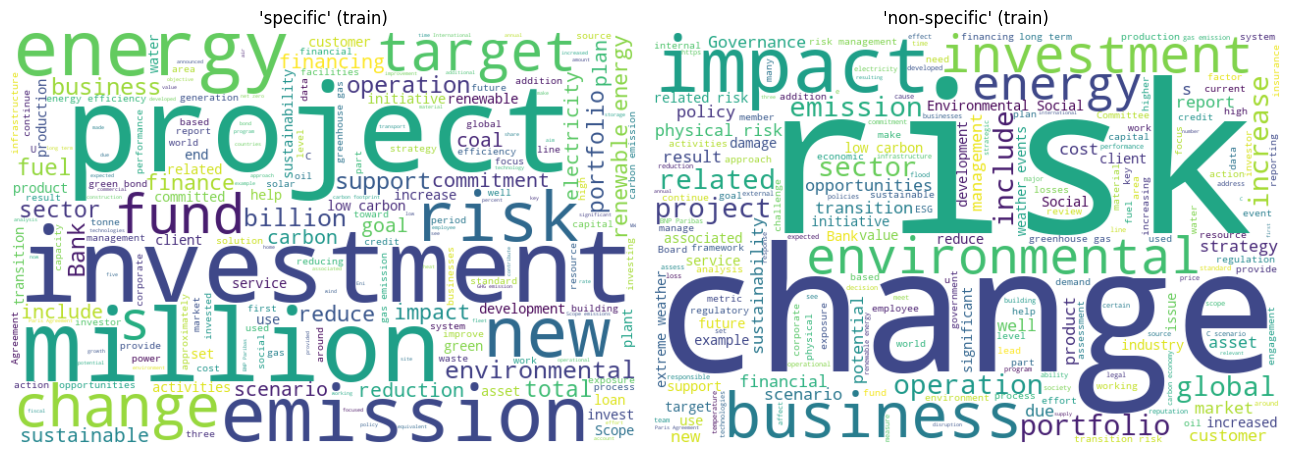

In [5]:
# Word clouds: the most frequent words in each class (common stopwords removed). A first, visual
# look at whether the two classes even draw on different vocabulary.
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
_sw = set(STOPWORDS) | {"climate","company","companies","group","will","may","year","years","also",
                        "including","within","across","one","two","per","cent"}
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, lab in zip(ax, ["specific", "non-specific"]):
    _txt = " ".join(train_df.loc[train_df["label"]==lab, "text"].astype(str))
    _wc = WordCloud(width=640, height=420, background_color="white", stopwords=_sw,
                    colormap="viridis", random_state=SEED).generate(_txt)
    a.imshow(_wc, interpolation="bilinear"); a.axis("off"); a.set_title(f"'{lab}' (train)")
plt.tight_layout(); plt.show()

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
    min_df=5,
    binary=True
)

X_terms = vectorizer.fit_transform(train_df["text"])
terms = pd.Series(vectorizer.get_feature_names_out())

specific_mask = train_df["label"].values == "specific"
nonspecific_mask = train_df["label"].values == "non-specific"

specific_rate = pd.Series(
    X_terms[specific_mask].mean(axis=0).A1,
    index=terms
)

nonspecific_rate = pd.Series(
    X_terms[nonspecific_mask].mean(axis=0).A1,
    index=terms
)

common_df = pd.DataFrame({
    "term": terms,
    "specific_rate": specific_rate.values,
    "non_specific_rate": nonspecific_rate.values,
})

common_df["min_rate"] = common_df[["specific_rate", "non_specific_rate"]].min(axis=1)
common_df["abs_difference"] = (
    common_df["specific_rate"] - common_df["non_specific_rate"]
).abs()

shared_terms = (
    common_df
    .query("min_rate >= 0.05")
    .sort_values(["min_rate", "abs_difference"], ascending=[False, True])
    .head(20)
)

display(shared_terms[["term", "specific_rate", "non_specific_rate", "abs_difference"]].round(3))

,term,specific_rate,non_specific_rate,abs_difference
229,climate,0.291,0.506,0.215
179,carbon,0.283,0.193,0.090
449,energy,0.343,0.183,0.160
463,environmental,0.168,0.190,0.022
206,change,0.163,0.343,0.180
438,emissions,0.328,0.160,0.169
167,business,0.145,0.210,0.064
618,group,0.120,0.141,0.021
1153,related,0.118,0.191,0.074
589,gas,0.165,0.115,0.051


In [7]:
term_df = pd.DataFrame({
    "term": terms,
    "specific_rate": specific_rate.values,
    "non_specific_rate": nonspecific_rate.values,
})

term_df["diff"] = term_df["specific_rate"] - term_df["non_specific_rate"]

top_specific = term_df.sort_values("diff", ascending=False).head(10)
top_nonspecific = term_df.sort_values("diff", ascending=True).head(10)

print("Most specific-skewed terms:")
display(top_specific.round(3))

print("Most non-specific-skewed terms:")
display(top_nonspecific.round(3))

Most specific-skewed terms:


,term,specific_rate,non_specific_rate,diff
874,million,0.298,0.005,0.293
438,emissions,0.328,0.160,0.169
449,energy,0.343,0.183,0.160
147,billion,0.165,0.015,0.150
1476,year,0.183,0.042,0.141
1080,projects,0.170,0.052,0.119
1161,renewable,0.170,0.053,0.117
1394,total,0.115,0.012,0.104
614,green,0.125,0.023,0.102
1362,target,0.113,0.017,0.096


Most non-specific-skewed terms:


,term,specific_rate,non_specific_rate,diff
1209,risks,0.053,0.313,-0.260
229,climate,0.291,0.506,-0.215
206,change,0.163,0.343,-0.180
1208,risk,0.108,0.276,-0.168
659,impact,0.088,0.213,-0.125
1002,physical,0.020,0.135,-0.115
1462,weather,0.015,0.115,-0.100
488,events,0.020,0.103,-0.083
662,impacts,0.045,0.125,-0.080
539,financial,0.095,0.175,-0.079


The word clouds, unsurprisingly, show that the two classes share much of the same broad corporate climate-disclosure vocabulary. Terms such as **investment**, **energy**, **risk**, **business**, **carbon** and **emissions** appear in both classes. The frequency table also suggests that many common terms appear in both **specific** and **non-specific** disclosures at meaningful rates. We can safely conclude that both classes are written in the same corporate reporting register which, of course, also implies that our classification problem is more difficult than a simple keyword-matching task.

Nonetheless, the skewed-term tables we produce above also show that some lexical cues do exist, but they are only partial. As expected, words such as **million**, **billion**, **emissions**, **energy**, **renewable** and **target** appear more often in **specific** disclosures, which is consistent with the idea that specificity is often associated with measurable quantities, emissions figures or dated commitments (that is, by a certain year something will be done about X, Y, Z). By contrast, terms such as **risk**, **risks**, **climate**, **change**, **impact**, **weather** and **financial** are more common in **non-specific** disclosures, reflecting broader discussion of climate exposure and business risk. However, as we see, these terms do not define the label on their own. A paragraph can mention emissions or targets without making a concrete, verifiable claim, while climate-risk language can be either vague or specific depending on the surrounding detail. 

Overall, our EDA suggests that the dataset is clean and appropriate for what we set out to do, class-imbalance and vocabulary-similarity notwithstanding.

Something truly very important to mention at this point is that the dataset creators note that the labels were produced by several annotators (the authors together with finance and sustainable-finance students), with close verdicts and ties discussed by the authors before a final decision. Not only that: even the labels that did not come down to a tie were not necessarily clean-cut, since a simple majority (and not unanimity) was enough to settle the label. We are given the final labels and the final labels only. So, we have no way of seeing which labels were more contested and, because of that, some labels that look definite (0 or 1) are, in truth, much less definite than others in the dataset, making our classification task even more difficult. Having explored and noticed what we have, we move on to the next subpoint.

### 1c. Random classifier performance (0.25)


Before we bring in anything sophisticated, we want a floor to beat, so we start with two very simple random baselines. The first just flips a fair coin: it predicts each class with equal probability, $P(\hat{y}=0)=P(\hat{y}=1)=0.5$. On a binary problem, that gives an expected accuracy of

$$
\mathbb{E}[\text{Accuracy}] = 0.5P(y=0) + 0.5P(y=1) = 0.5
$$


The second is a touch cleverer: instead of flipping a fair coin, it predicts each class as often as that class actually shows up in the training data. So if the class priors are $p_0$ and $p_1$, then $P(\hat{y}=i)=p_i$. With our roughly 60% non-specific and 40% specific split, the expected accuracy works out to

$$
\mathbb{E}[\text{Accuracy}] = \sum_{i=0}^{1} p_i^2 = 0.6^2 + 0.4^2 = 0.52
$$

In [8]:
rng = np.random.default_rng(SEED)

train_priors = train_df["label"].value_counts(normalize=True).reindex(LABELS).values
uniform_priors = np.array([0.5, 0.5])

uniform_pred = rng.choice(len(LABELS), size=len(TEST_LABELS), p=uniform_priors)
imbalance_pred = rng.choice(len(LABELS), size=len(TEST_LABELS), p=train_priors)

baseline_summary = pd.DataFrame(
    {
        "Classifier": ["Uniform random", "Imbalance-aware random"],
        "Expected accuracy": [0.5, float((train_priors**2).sum())],
        "Empirical test accuracy": [
            (uniform_pred == TEST_LABELS).mean(),
            (imbalance_pred == TEST_LABELS).mean(),
        ],
    }
).round(3)

display(baseline_summary)

RESULTS["random"] = macro_f1(TEST_LABELS, imbalance_pred)
PREDS["random"] = list(imbalance_pred)


,Classifier,Expected accuracy,Empirical test accuracy
0,Uniform random,0.50,0.484
1,Imbalance-aware random,0.52,0.475


As the table above shows, both baselines are a little bit below the accuracies we would have expected. That is, almost certainly, just noise: we run, in the end, each classifier only once, rather than averaging over many repeated simulations. For the imbalance-aware one, a small part of the gap might also come from the fact that we estimate the class proportions on the training set but score them on the test set (though, since the train and test distributions look very similar we would not expect that to make much of a difference but still).

### 1d. Rule-based baseline (0.5)

We set up a very simple and transparent rule to identify specificity: a paragraph is **specific** if it carries concrete, checkable detail, a number paired with a unit, a percentage, an emissions figure (tonnes CO2, Scope 1/2/3) or an explicit dated target and **non-specific** otherwise. We set it up in this fashion to see how far a simple rule like this can carry us before any learning.

In [9]:
import re
from sklearn.feature_extraction.text import CountVectorizer

# ------------------------------------------------------------
# Initial hand-built rule / dictionary
# ------------------------------------------------------------

NUM_UNIT = re.compile(
    r"\d[\d,.]*\s?(%|percent|tonnes?|tons?|co2|mwh|gwh|kwh|kg|mw|gw|kt|mt|million|billion|km|hectares?)",
    re.I,
)

PCT = re.compile(r"\d[\d,.]*\s?%")

KEYWORDS = [
    "scope 1",
    "scope 2",
    "scope 3",
    "by 2020",
    "by 2025",
    "by 2030",
    "by 2040",
    "by 2050",
    "net zero by",
    "reduction of",
    "reduce by",
    "target of",
]


def make_pattern(terms):
    if not terms:
        return re.compile(r"a^")  # matches nothing
    return re.compile(r"\b(?:" + "|".join(re.escape(t) for t in terms) + r")\b", re.I)


KEYWORD_PATTERN = make_pattern(KEYWORDS)


def rule_specific(text):
    return (
        "specific"
        if NUM_UNIT.search(text) or PCT.search(text) or KEYWORD_PATTERN.search(text)
        else "non-specific"
    )


# ------------------------------------------------------------
# Helper: learn extra specificity terms from false negatives
# ------------------------------------------------------------


def label_ids(df):
    return np.array(
        [LABEL2ID[x] if isinstance(x, str) else int(x) for x in df["label"]]
    )


def learn_terms(
    error_texts,
    comparison_texts,
    min_count=5,
    min_ratio=2.0,
    top_n=20,
    ngram_range=(1, 2),
    exclude_terms=None,
):

    exclude_terms = set() if exclude_terms is None else set(exclude_terms)

    vec = CountVectorizer(
        stop_words="english", ngram_range=ngram_range, token_pattern=r"\b[a-zA-Z]{3,}\b"
    )

    X = vec.fit_transform(error_texts + comparison_texts)
    terms = np.array(vec.get_feature_names_out())

    error_counts = np.asarray(X[: len(error_texts)].sum(axis=0)).ravel()
    comparison_counts = np.asarray(X[len(error_texts) :].sum(axis=0)).ravel()

    df = pd.DataFrame(
        {
            "term": terms,
            "false_negative_count": error_counts.astype(int),
            "non_specific_count": comparison_counts.astype(int),
        }
    )

    df["ratio"] = (df["false_negative_count"] + 1) / (df["non_specific_count"] + 1)

    df = (
        df[
            (df["false_negative_count"] >= min_count)
            & (df["ratio"] >= min_ratio)
            & (~df["term"].isin(exclude_terms))
        ]
        .sort_values(["ratio", "false_negative_count"], ascending=False)
        .reset_index(drop=True)
    )

    return df.head(top_n)["term"].tolist(), df


# ------------------------------------------------------------
# Rule v1: evaluate initial dictionary
# ------------------------------------------------------------

TRAIN_TEXTS = train_df["text"].tolist()
TRAIN_LABELS = label_ids(train_df)

specific_id = LABEL2ID["specific"]
nonspecific_id = LABEL2ID["non-specific"]

rule_pred = [LABEL2ID[rule_specific(t)] for t in TEST_TEXTS]
rule_f1 = macro_f1(TEST_LABELS, rule_pred)

print(f"Rule v1 macro-F1: {rule_f1:.4f}")
print(
    classification_report(TEST_LABELS, rule_pred, target_names=LABELS, zero_division=0)
)

RESULTS["rule_based"] = rule_f1
PREDS["rule_based"] = list(rule_pred)

Rule v1 macro-F1: 0.6638
              precision    recall  f1-score   support

non-specific       0.71      0.92      0.80       197
    specific       0.77      0.40      0.52       123

    accuracy                           0.72       320
   macro avg       0.74      0.66      0.66       320
weighted avg       0.73      0.72      0.70       320



As we can see above, the initial rule-based classifier achieves a macro-F1 score of 0.664, outperforming the random classifiers as expected. It performs quite well on the **non-specific** class, with recall of 0.92, but performs much worse on **specific** (only 0.40). This tells us that when the rule predicts specificity it is usually right, but it also misses many specific disclosures, (a conservative dictionary, ours).

So, we try to grow the dictionary automatically. TF-IDF-style, we look for terms that are relatively distinctive of the **specific** class, rather than simply the most frequent words overall. As such, we take the paragraphs where our simple rule missed (its false negatives) and extract the unigram and bigram terms that occur disproportionately often there relative to non-specific training examples and, then, add them as extra specificity cues, hoping it would improve our results.

In [10]:
# ------------------------------------------------------------
# Find v1 false negatives on the training set
# ------------------------------------------------------------

train_rule_pred = [LABEL2ID[rule_specific(t)] for t in TRAIN_TEXTS]

# False negatives: genuinely specific paragraphs that v1 missed
train_false_negative_texts = [
    text
    for text, gold, pred in zip(TRAIN_TEXTS, TRAIN_LABELS, train_rule_pred)
    if gold == specific_id and pred != specific_id
]

# Comparison group: genuinely non-specific training paragraphs
train_nonspecific_texts = [
    text for text, gold in zip(TRAIN_TEXTS, TRAIN_LABELS) if gold == nonspecific_id
]

print("\n" + "=" * 60)
print("TRAINING FALSE NEGATIVES FROM RULE V1")
print("=" * 60)
print(f"False negatives: {len(train_false_negative_texts)}")


# ------------------------------------------------------------
# Learn specificity words from false negatives
# ------------------------------------------------------------

MIN_ERROR_COUNT = 5
MIN_RATIO = 2.0
TOP_N = 20

learned_specific_words, learned_specific_df = learn_terms(
    error_texts=train_false_negative_texts,
    comparison_texts=train_nonspecific_texts,
    min_count=MIN_ERROR_COUNT,
    min_ratio=MIN_RATIO,
    top_n=TOP_N,
)

print("\n" + "=" * 60)
print("LEARNED SPECIFICITY WORDS FROM FALSE NEGATIVES")
print("=" * 60)
display(learned_specific_df.head(TOP_N))
print("Specificity cue words:", learned_specific_words)


TRAINING FALSE NEGATIVES FROM RULE V1
False negatives: 131

LEARNED SPECIFICITY WORDS FROM FALSE NEGATIVES


,term,false_negative_count,non_specific_count,ratio
0,factor index,12,0,13.000000
1,balanced factor,10,0,11.000000
2,tilts,10,0,11.000000
3,controversial,6,0,7.000000
4,divested,7,1,4.000000
5,palm,7,1,4.000000
6,index,20,5,3.500000
7,achieved,6,1,3.500000
8,carbon neutrality,6,1,3.500000
9,companies divested,6,1,3.500000


Specificity cue words: ['factor index', 'balanced factor', 'tilts', 'controversial', 'divested', 'palm', 'index', 'achieved', 'carbon neutrality', 'companies divested', 'neutrality', 'palm oil', 'certification', 'cent', 'factor', 'balanced', 'metric', 'phase', 'stage', 'built']


Looks like the learned list is a mixed bag: it contains several clearly relevant terms ("carbon neutrality" and "divested" seem some obvious ones to us) next to some corpus-specific quirks ("factor index", "tilts"). So, far from perfect.Still, it is more justifiable than simply using the most frequent words, since it is selected for class distinctiveness rather than raw frequency. Now, we take these cues and we insert them into the original rule to produce **rule v2** and we proceed to re-score on the test set.

In [11]:
# ------------------------------------------------------------
# Rule v2: original rule + learned specificity words
# ------------------------------------------------------------

specific_pattern = make_pattern(learned_specific_words)


def rule_v2_specific(text):
    if rule_specific(text) == "specific" or specific_pattern.search(text):
        return "specific"

    return "non-specific"


rule_v2_pred = [LABEL2ID[rule_v2_specific(t)] for t in TEST_TEXTS]
rule_v2_f1 = macro_f1(TEST_LABELS, rule_v2_pred)

print(
    f"\nrule v1 macro-F1 = {rule_f1:.4f}  ->  "
    f"rule v2 (+ auto specificity words from FNs) macro-F1 = {rule_v2_f1:.4f}"
)

print(
    classification_report(
        TEST_LABELS, rule_v2_pred, target_names=LABELS, zero_division=0
    )
)

RESULTS["rule_v2_auto_fn"] = rule_v2_f1
PREDS["rule_v2_auto_fn"] = list(rule_v2_pred)


rule v1 macro-F1 = 0.6638  ->  rule v2 (+ auto specificity words from FNs) macro-F1 = 0.6806
              precision    recall  f1-score   support

non-specific       0.73      0.88      0.80       197
    specific       0.71      0.47      0.57       123

    accuracy                           0.72       320
   macro avg       0.72      0.67      0.68       320
weighted avg       0.72      0.72      0.71       320



The refinement helps but not that much: macro-F1 improves from 0.664 to 0.681 and specific-class recall rises from 0.40 to 0.47. If that improves, however, something else seems to give: specific-class precision falls from 0.77 to 0.71, reflecting that the updated rule catches more specific disclosures but also introduces more false positives. To see what the rule still gets wrong (and why), we highlight the trigger phrases inside a few paragraphs and inspect the rows that v2 newly flips.

In [12]:
import re

ID2LABEL = {v: k for k, v in LABEL2ID.items()}
keyword_pattern = make_pattern(KEYWORDS)

trigger_patterns = [NUM_UNIT, PCT, keyword_pattern, specific_pattern]

# Plain-text output (no HTML): cues in bold red, paragraphs hard-wrapped to a fixed
# width so they read top-to-bottom with no horizontal scrolling. Wrapping is done by
# VISIBLE width, so the ANSI escape codes never distort line lengths and cues are not split.
RED = "\033[1;31m"
BOLD = "\033[1m"
RESET = "\033[0m"
WIDTH = 90


def _cue_mask(text):
    """Mark which characters fall inside a non-overlapping rule-trigger span."""
    spans = []
    for pattern in trigger_patterns:
        for m in pattern.finditer(text):
            spans.append((m.start(), m.end()))
    spans.sort(key=lambda x: (x[0], -(x[1] - x[0])))
    mask = [False] * len(text)
    end, n = -1, 0
    for s, e in spans:
        if s >= end:
            n += 1
            for k in range(s, e):
                mask[k] = True
            end = e
    return mask, n


def highlight_wrapped(text, width=WIDTH):
    """Word-wrap to `width` visible columns, painting cue characters bold red."""
    mask, n_cues = _cue_mask(text)

    def paint(a, b):
        out, k = [], a
        while k < b:
            run = k
            while run < b and mask[run] == mask[k]:
                run += 1
            out.append(f"{RED}{text[k:run]}{RESET}" if mask[k] else text[k:run])
            k = run
        return "".join(out)

    lines, line, vis = [], [], 0
    for m in re.finditer(r"\S+", text):
        wlen = m.end() - m.start()
        if line and vis + 1 + wlen > width:
            lines.append("".join(line))
            line, vis = [], 0
        if line:
            line.append(" ")
            vis += 1
        line.append(paint(m.start(), m.end()))
        vis += wlen
    if line:
        lines.append("".join(line))
    return "\n".join(lines), n_cues


def show_errors(y_true, y_pred, texts, gold_label, n=5, start=0):
    gold_id = LABEL2ID[gold_label]
    idxs = [
        i for i, (g, p) in enumerate(zip(y_true, y_pred))
        if g == gold_id and p != gold_id
    ]
    selected = idxs[start : start + n]

    if gold_label == "non-specific":
        title = "NON-SPECIFIC EXAMPLES WRONGLY CLASSIFIED AS SPECIFIC"
        note = f"Terms in {RED}red{RESET} are the cues that wrongly triggered a 'specific' prediction."
    else:
        title = "SPECIFIC EXAMPLES WRONGLY CLASSIFIED AS NON-SPECIFIC"
        note = "The rule fired none of its cues here, even though these paragraphs are genuinely specific."

    bar = "=" * WIDTH
    print(bar)
    print(f"{BOLD}{title}{RESET}")
    print(note)
    print(f"Showing errors {start + 1} to {start + len(selected)} of {len(idxs)}.")
    print(bar)

    for i in selected:
        marked, n_cues = highlight_wrapped(texts[i])
        print(
            f"\n{BOLD}Test row {i}{RESET}   gold: {ID2LABEL[y_true[i]]}   "
            f"predicted: {ID2LABEL[y_pred[i]]}   cues found: {n_cues}"
        )
        print("-" * WIDTH)
        print(marked)
    print()


N_MISS = 2
N_FP = 2

show_errors(TEST_LABELS, rule_v2_pred, TEST_TEXTS, "specific", n=N_MISS, start=11)
show_errors(TEST_LABELS, rule_v2_pred, TEST_TEXTS, "non-specific", n=N_FP, start=10)

newly_caught = [
    i for i in range(len(TEST_TEXTS))
    if rule_pred[i] != specific_id
    and rule_v2_pred[i] == specific_id
    and TEST_LABELS[i] == specific_id
]

new_false_positives = [
    i for i in range(len(TEST_TEXTS))
    if rule_pred[i] != specific_id
    and rule_v2_pred[i] == specific_id
    and TEST_LABELS[i] != specific_id
]

print(
    f"\nRule v2 newly catches {len(newly_caught)} gold-specific rows; "
    f"introduces {len(new_false_positives)} new false positives."
)


SPECIFIC EXAMPLES WRONGLY CLASSIFIED AS NON-SPECIFIC
The rule fired none of its cues here, even though these paragraphs are genuinely specific.
Showing errors 12 to 13 of 65.

Test row 99   gold: specific   predicted: non-specific   cues found: 0
------------------------------------------------------------------------------------------
Our audits help us rate our suppliers according to their social and environmental
compliance performance with a C-KPI and E-KPI rating tool, respectively. As we continue to
increase our focus on added-value advisory services and empowerment projects, which go
beyond our regular audit routine, the number of audits conducted by our own in-house team
has decreased to 251 in 2020 (2019: 299). Similarly, audits conducted by third-party
monitors also decreased to 612 at the end of 2020 (2019: 658).

Test row 102   gold: specific   predicted: non-specific   cues found: 0
------------------------------------------------------------------------------------------


As we can see above, v2's new cues are a bit of a wash: they newly catch 9 genuinely specific rows, but they also create 9 new false positives. The (red) highlighted examples show us why where our approach failed. The specific paragraphs we miss often really do contain real detail, but their specificity lives in the context, not in any keyword the rule can exploit. The non-specific paragraphs we wrongly flag are the opposite trap: they happen to carry a statistic or some target-like phrasing that, however, once we look close, has absolutely nothing to do with climate action (a stray sentence about global population growth, say). This is really the crux of the difficulty of our dataset (already highlighted in previous cells). These are full corporate-report paragraphs, not neat one-line claims, so a single observation can easily bury a number, a date or a target inside otherwise vague background, while a genuinely specific disclosure can be written without a single obvious trigger word.

So, where does this leave the rule? As a transparent, interpretable baseline that does its job and shows how far plain surface cues can take us before any learning. But getting past its mistakes would ask much more of a model: said model would need to be able to judge whether a number actually points to a concrete climate action, whether a paragraph is reporting something done or just musing about general risk and whether specific-sounding language is, in the end, actually checkable. Which, our rule-based model seems to tell us, can't be done in this way. So, we need  models that can represent context and meaning more flexibly, to which we now turn

## Part 2 - Data-scientist challenge: 32 labels (3.5 pts)

The constraint: only **32 labelled examples** may be used as supervised data. Everything else in `train` is treated as unlabelled. The 32 are sampled stratified (16 specific / 16 non-specific), seeded, from the training pool and every model is evaluated on the held-out `test` split.

In [13]:
def stratified_sample(frame, n, label_col="label_id", seed=SEED):
    per = n // len(LABELS)
    parts = [
        g.sample(min(len(g), per), random_state=seed)
        for _, g in frame.groupby(label_col)
    ]
    out = pd.concat(parts)
    if len(out) < n:
        extra = frame.drop(out.index).sample(n - len(out), random_state=seed)
        out = pd.concat([out, extra])
    return out.reset_index(drop=True)


budget32 = stratified_sample(pool_df, 32)
print("32-label budget class counts:", dict(budget32["label"].value_counts()))
X32, y32 = budget32["text"].tolist(), budget32["label_id"].tolist()

32-label budget class counts: {'non-specific': np.int64(16), 'specific': np.int64(16)}


### 2a. BERT with 32 labelled examples (0.5)

So, we now fine-tune DistilRoBERTa using only 32 labelled training examples. As we find ourselves to be in a low-data setting we train for more epochs than in the full-data experiments: with only 32 examples, a small number of epochs gives very few gradient updates and the model can easily default toward the majority **non-specific** class. Because few-shot fine-tuning is notoriously unstable we train across several random seeds and report the **median** as our headline `bert_32`, keeping the full range of results visible.

In [14]:
# Few-sample BERT is unstable: a single 32-label run collapses to the prior (~0.38) on roughly a
# third of seeds, nondeterministically (MPS is not bit-deterministic). So we train several seeds and
# report the MEDIAN as bert_32 - robust to the occasional collapse - keeping the full spread visible
# so the unlucky-draw collapse reads as the variance it is, not the headline number.
import numpy as np
_seeds = [42, 43, 44, 7, 123, 2024, 99]
_runs = [train_eval(X32, y32, TEST_TEXTS, TEST_LABELS, epochs=FS_EPOCHS, seed=_s, label=f"bert32_s{_s}")
         for _s in _seeds]
_scores = [r[0] for r in _runs]
_med = sorted(range(len(_runs)), key=lambda k: _scores[k])[len(_runs) // 2]  # the median run
f1_32, pred_32, model_32, tok_32 = _runs[_med]
RESULTS["bert_32"] = f1_32
PREDS["bert_32"] = list(pred_32)
PROBS["bert_32"] = bert_maxprob(model_32, tok_32, TEST_TEXTS)[1]
print(f"\nBERT-32 over {len(_seeds)} seeds {_seeds}:\n  scores = {[round(s, 3) for s in _scores]}")
print(f"  median (reported as bert_32) = {f1_32:.4f} | mean = {np.mean(_scores):.4f} +/- {np.std(_scores):.4f}"
      f" | worst = {min(_scores):.3f} (an unlucky-draw collapse)")
print(classification_report(TEST_LABELS, pred_32, target_names=LABELS, digits=3, zero_division=0))

{'train_runtime': 8.3626, 'train_samples_per_second': 38.266, 'train_steps_per_second': 2.392, 'train_loss': 0.6776745796203614, 'epoch': 10.0}


[bert32_s42] macro-F1 = 0.3810  (train n=32)


{'train_runtime': 8.1235, 'train_samples_per_second': 39.392, 'train_steps_per_second': 2.462, 'train_loss': 0.6734132766723633, 'epoch': 10.0}


[bert32_s43] macro-F1 = 0.6228  (train n=32)


{'train_runtime': 8.1257, 'train_samples_per_second': 39.381, 'train_steps_per_second': 2.461, 'train_loss': 0.6754286766052247, 'epoch': 10.0}


...

{'train_runtime': 8.267, 'train_samples_per_second': 38.708, 'train_steps_per_second': 2.419, 'train_loss': 0.6773984909057618, 'epoch': 10.0}


[bert32_s2024] macro-F1 = 0.4162  (train n=32)


{'train_runtime': 8.2269, 'train_samples_per_second': 38.897, 'train_steps_per_second': 2.431, 'train_loss': 0.6775574684143066, 'epoch': 10.0}


[bert32_s99] macro-F1 = 0.6950  (train n=32)



BERT-32 over 7 seeds [42, 43, 44, 7, 123, 2024, 99]:
  scores = [0.381, 0.623, 0.621, 0.659, 0.746, 0.416, 0.695]
  median (reported as bert_32) = 0.6228 | mean = 0.5916 +/- 0.1287 | worst = 0.381 (an unlucky-draw collapse)
              precision    recall  f1-score   support

non-specific      0.691     0.873     0.771       197
    specific      0.648     0.374     0.474       123

    accuracy                          0.681       320
   macro avg      0.669     0.624     0.623       320
weighted avg      0.674     0.681     0.657       320



So the few-shot model is, at best, a mixed result. Across the 7 seeds the macro-F1 swings all over the place: two unlucky draws collapse straight back to the majority-class prior (0.381 and 0.416), while the other five land between 0.62 and 0.75. Taking the **median** as our headline gives `bert_32` = 0.623, comfortably above the random baselines, so the model is clearly picking up some signal from the 32 examples. But even at its median, our bert_32 still loses to our humble rule-based classifier (0.664 before refinement, 0.681 after). As we want to see how/where is losing, we examine the per-class results.

In [15]:
# Is BERT-32 learning, or collapsing onto the majority class?
from sklearn.metrics import classification_report, confusion_matrix

print("BERT-32 (seed 43) per-class on test:")
print(
    classification_report(
        TEST_LABELS, pred_32, target_names=LABELS, zero_division=0, digits=3
    )
)
print(
    "confusion (rows=true, cols=pred):\n",
    confusion_matrix(TEST_LABELS, pred_32, labels=[0, 1]),
)
_pred_ns = (np.array(pred_32) == LABEL2ID["non-specific"]).mean()
_prior_ns = (np.array(TEST_LABELS) == LABEL2ID["non-specific"]).mean()
print(
    f"\nBERT-32 says 'non-specific' for {_pred_ns:.0%} of the test set (the prior is {_prior_ns:.0%})."
)
if abs(_pred_ns - _prior_ns) < 0.10:
    print("Prediction share is close to the class prior, suggesting the model is not simply collapsing.")
elif _pred_ns > _prior_ns + 0.10:
    print("The model over-predicts the non-specific class, suggesting majority-class bias.")
else:
    print("The model under-predicts the non-specific class relative to the test prior.")

BERT-32 (seed 43) per-class on test:
              precision    recall  f1-score   support

non-specific      0.691     0.873     0.771       197
    specific      0.648     0.374     0.474       123

    accuracy                          0.681       320
   macro avg      0.669     0.624     0.623       320
weighted avg      0.674     0.681     0.657       320

confusion (rows=true, cols=pred):
 [[172  25]
 [ 77  46]]

BERT-32 says 'non-specific' for 78% of the test set (the prior is 62%).
The model over-predicts the non-specific class, suggesting majority-class bias.


And our splitting delivers what we hoped. On the majority **non-specific** class the model does fine (recall 0.873), but on the **specific** class it falls apart, catching little more than a third of them (recall 0.374). The confusion matrix tells pretty much the same story: 172 of 197 non-specific paragraphs are labelled correctly but only 46 of 123 specific ones are caught, with the other 77 classified as non-specific. With just 32 examples to learn from, it seems to settle on a cautious rule that leans on the prior, without ever seeing enough of the many versions specificity comes in to recognise them. The natural, next question is if it is making these calls confidently or just hedging. So, we now look at the probability distributions

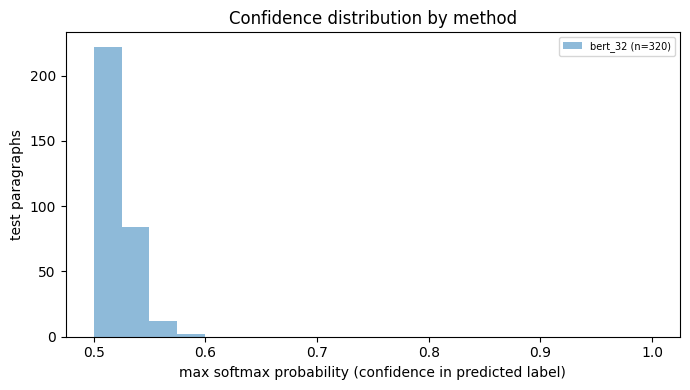

BERT-32 max-probability mass: piled near 1.0 = confident, near 0.5 = hedging at the binary chance line.
(BERT-versus-categorical-LLM confidence is not observable from outside the API, a limitation we return to.)


In [16]:
# Is BERT-32 collapsing confidently or while hedging? Its own max-probability
# distribution answers that with the one graded method available at this point. A graded BERT-versus-LLM
# comparison is not possible: the categorical LLM API returns no log-probabilities, so its confidence is a 1.0
# placeholder, not a measurement. The meaningful graded comparison (BERT-32 versus NLI zero-shot) comes later.
prob_hist(["bert_32"], path=OUT_DIR / "confidence_2a.png")
print(
    "BERT-32 max-probability mass: piled near 1.0 = confident, near 0.5 = hedging at the binary chance line."
)
print(
    "(BERT-versus-categorical-LLM confidence is not observable from outside the API, a limitation we return to.)"
)

And it is mostly hedging. The histogram shows the model's top probabilities bunched in the 0.50 to 0.55 with almost nothing above 0.6. So, the predictions are not just biased toward **non-specific**, they are also made with very little conviction: the model has found *some* signal, but nothing like a clean separation between the two classes.

Where does 2a leave us? BERT-32 lands between the random baselines and the rule. The rule has the advantage, we reckon, because specificity so often shows up as surface cues (the numbers, percentages, dated targets we showed above) that a dictionary can grab with no training at all. BERT, on the other hand, has to learn the whole task from 32 examples, while its weak specific-class recall says it simply has not seen enough of the many ways specificity gets phrased in corporate disclosures. The obvious fix is to relieve that few-shot bottleneck by feeding the model more label-preserving variation, which is exactly what we try next.

*Sidenote: since DistilRoBERTa could not beat the rule-based baseline, we also tried a SetFit model, which is built precisely for few-shot settings. Unresolved package-version conflicts kept us from running it reliably inside the project environment, so we do not report numbers here, but we flag it as a promising extension since it is still a BERT-based approach.*

### 2b. Dataset augmentation without an LLM (1.0)

The assignment rules out LLMs here, so the idea is simple: can we squeeze more out of our 32 labelled examples using nothing but old-fashioned, rule-based augmentation? We try three classic families below

1. **EDA word swap / deletion**: randomly swapping and dropping the odd word to create noisy variants (Wei & Zou 2019).
2. **Numeric perturbation**: specificity lives in numbers, so we rescale a figure by ±15% ("13.4 million tonnes" → "12.1 million tonnes") to mint a fresh *specific* paragraph without ever flipping its label. Of course, we only touch paragraphs that have a number to begin with.
3. **Lexical substitution**: a small hand-written list of disclosure-register paraphrases (for example, "committed to" becomes "dedicated to"), the vague-language counterpart of the numeric trick.

A quick note on reproducibility: we seed the randomness from the text itself (a CRC32 checksum), so the same paragraph always gets the same augmentation. Python's built-in `hash()` changes from run to run, so it would not work here. We, then, retrain on the same 32-example budget as 2a and measure the difference.

In [17]:
import re, zlib, random

LEX_SWAPS = [
    ("committed to", "dedicated to"),
    ("aims to", "intends to"),
    ("strive to", "seek to"),
    ("sustainability", "environmental responsibility"),
    ("climate change", "global climate challenges"),
    ("initiatives", "programmes"),
    ("our goal", "our ambition"),
]

def _rng(text, salt=0):
    return random.Random(SEED + salt + zlib.crc32(text.encode("utf-8")))

def eda_augment(text, n_aug=2, p_delete=0.10):
    rng, words, out = _rng(text), text.split(), []
    for _ in range(n_aug):
        w = words[:]
        if len(w) > 3:
            i, j = rng.randrange(len(w)), rng.randrange(len(w))
            w[i], w[j] = w[j], w[i]
            w = [x for x in w if rng.random() > p_delete] or w
        out.append(" ".join(w))
    return out

def perturb_numbers(text):
    rng = _rng(text, salt=1)

    def rep(m):
        s = m.group(0)
        try:
            v = float(s.replace(",", ""))
        except ValueError:
            return s

        # Do not perturb years, since target dates are meaningful.
        if s.isdigit() and len(s) == 4 and 1900 <= int(s) <= 2100:
            return s

        v *= rng.uniform(0.85, 1.15)
        return f"{v:,.1f}" if ("." in s or "," in s) else str(max(1, round(v)))

    out = re.sub(r"\d[\d,]*\.?\d*", rep, text)
    return out if out != text else None

def lexical_swap(text):
    out = text
    for a, b in LEX_SWAPS:
        out = re.sub(re.escape(a), b, out, flags=re.I)
    return out if out != text else None

def build_augmented_set(families=("eda", "numeric", "lexical"), n_eda=2):
    rows, counts = [], {f: 0 for f in families}

    for idx, (t, y) in enumerate(zip(X32, y32)):
        if "eda" in families:
            for a in eda_augment(t, n_aug=n_eda):
                rows.append((idx, "eda", a, y))
                counts["eda"] += 1

        if "numeric" in families:
            a = perturb_numbers(t)
            if a:
                rows.append((idx, "numeric", a, y))
                counts["numeric"] += 1

        if "lexical" in families:
            a = lexical_swap(t)
            if a:
                rows.append((idx, "lexical", a, y))
                counts["lexical"] += 1

    aug_df = pd.DataFrame(rows, columns=["source_idx", "family", "text", "label"])
    X_out = X32 + aug_df["text"].tolist()
    y_out = y32 + aug_df["label"].tolist()

    return X_out, y_out, aug_df, counts

# ------------------------------------------------------------
# Full augmented model only: EDA + numeric + lexical
# ------------------------------------------------------------

X_aug, y_aug, aug_df, fam = build_augmented_set(
    families=("eda", "numeric", "lexical")
)

print(f"Augmented training set: {len(X32)} -> {len(X_aug)} examples | {fam}")

f1_aug, pred_aug, model_aug, tok_aug = train_eval(
    X_aug,
    y_aug,
    TEST_TEXTS,
    TEST_LABELS,
    epochs=FS_EPOCHS,
    label="bert32_all_aug"
)

RESULTS["bert_32_all_aug"] = f1_aug
PREDS["bert_32_all_aug"] = list(pred_aug)
PROBS["bert_32_all_aug"] = bert_maxprob(model_aug, tok_aug, TEST_TEXTS)[1]

RESULTS["bert_32_augmented"] = f1_aug
PREDS["bert_32_augmented"] = list(pred_aug)
PROBS["bert_32_augmented"] = PROBS["bert_32_all_aug"]


Augmented training set: 32 -> 126 examples | {'eda': 64, 'numeric': 19, 'lexical': 11}


{'train_runtime': 32.4136, 'train_samples_per_second': 38.873, 'train_steps_per_second': 2.468, 'train_loss': 0.2570150375366211, 'epoch': 10.0}


[bert32_all_aug] macro-F1 = 0.5973  (train n=126)


Those three families between them turn our 32 seeds into 126 training rows: 64 from EDA word swaps and deletions, 19 from numeric perturbation and 11 from lexical substitution. Straight away, though, the headline is somewhat depressing: even on 126 rows the model only manages a macro-F1 of 0.597, below the 0.623 we got from the plain 32 in 2a. As we want to see how and where the extra data hurts us, we line up every metric against that plain baseline.

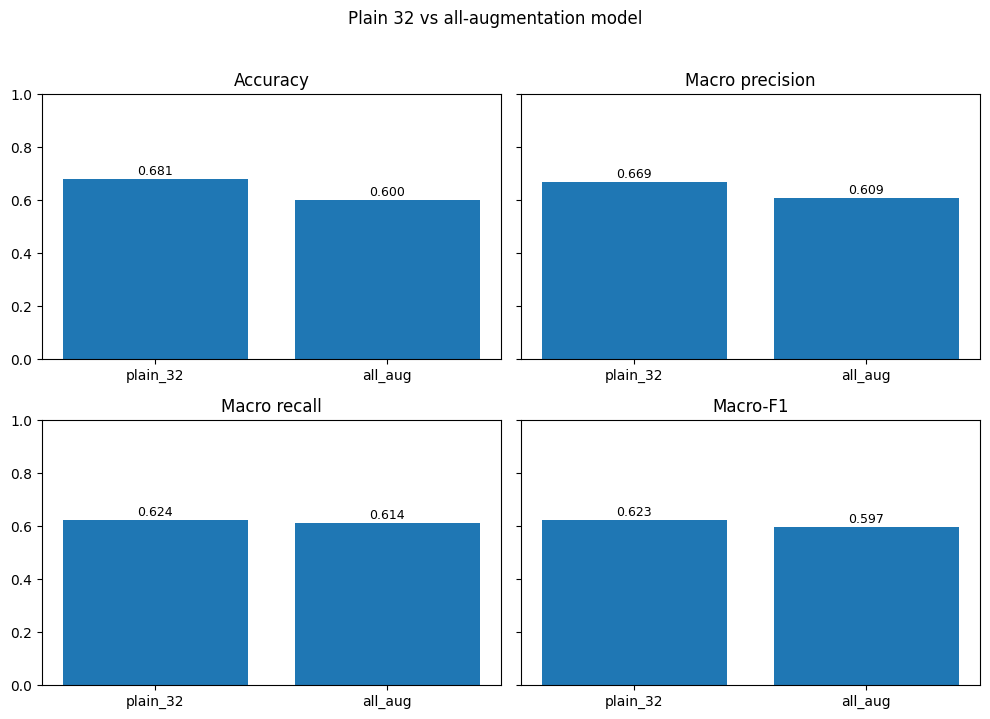

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

plain_pred = np.array(pred_32)
all_aug_pred = np.array(pred_aug)

metrics_df = pd.DataFrame([
    {
        "model": "plain_32",
        "accuracy": accuracy_score(TEST_LABELS, plain_pred),
        "macro_precision": precision_score(TEST_LABELS, plain_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(TEST_LABELS, plain_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(TEST_LABELS, plain_pred, average="macro", zero_division=0),
    },
    {
        "model": "all_aug",
        "accuracy": accuracy_score(TEST_LABELS, all_aug_pred),
        "macro_precision": precision_score(TEST_LABELS, all_aug_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(TEST_LABELS, all_aug_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(TEST_LABELS, all_aug_pred, average="macro", zero_division=0),
    },
]).round(4)

plot_specs = [
    ("accuracy", "Accuracy"),
    ("macro_precision", "Macro precision"),
    ("macro_recall", "Macro recall"),
    ("macro_f1", "Macro-F1"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.ravel()

for ax, (col, title) in zip(axes, plot_specs):
    values = metrics_df[col].values
    labels = metrics_df["model"].values

    ax.bar(labels, values)
    ax.set_title(title)
    ax.set_ylim(0, 1)

    for i, v in enumerate(values):
        ax.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)

fig.suptitle("Plain 32 vs all-augmentation model", y=1.02)
plt.tight_layout()

plt.savefig(OUT_DIR / "plain32_vs_allaug_2x2_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

And the plot is very clear: every metric worsens. Accuracy drops from 0.681 to 0.600, macro precision from 0.669 to 0.608, macro recall from 0.624 to 0.614 and macro-F1 from 0.623 to 0.597. So simply bolting label-preserving variants onto the 32 examples does not buy us better generalisation on the held-out test set. The most likely reason is that these augmentations are cheap: they mostly reshuffle the surface form of paragraphs the model has already seen, rather than teaching it anything new about what separates specific from non-specific. We want to see if the averages tell us the whole story so expand a bit our analysis with a confusion matrix

In [19]:
from sklearn.metrics import confusion_matrix
import pandas as pd

label_ids = [LABEL2ID[label] for label in LABELS]

cm_plain = confusion_matrix(TEST_LABELS, plain_pred, labels=label_ids)
cm_all_aug = confusion_matrix(TEST_LABELS, all_aug_pred, labels=label_ids)

cm_plain_df = pd.DataFrame(
    cm_plain,
    index=[f"true_{label}" for label in LABELS],
    columns=[f"pred_{label}" for label in LABELS],
)

cm_all_aug_df = pd.DataFrame(
    cm_all_aug,
    index=[f"true_{label}" for label in LABELS],
    columns=[f"pred_{label}" for label in LABELS],
)

print("Plain 32 confusion matrix")
display(cm_plain_df)

print("All augmentation confusion matrix")
display(cm_all_aug_df)

Plain 32 confusion matrix


,pred_non-specific,pred_specific
true_non-specific,172,25
true_specific,77,46


All augmentation confusion matrix


,pred_non-specific,pred_specific
true_non-specific,109,88
true_specific,40,83


Very nice: the augmentation actually fixes the exact problem we diagnosed in 2a, the model's timid over-prediction of the majority class. The plain baseline is badly biased toward **non-specific**, getting 172 of 197 non-specific paragraphs right but only 46 of 123 specific ones. After augmentation the model is far more willing to say **specific**: it now catches 83 of the 123 specific paragraphs instead of 46, cutting the specific disclosures it misses from 77 down to 40. The catch is that it also overshoots badly: false positives on the non-specific class jump from 25 to 88, while non-specific paragraphs correctly kept fall from 172 to 109. So augmentation does not really fix the model's bias: it just swings it the other way. It now recovers far more specific paragraphs, but only by flagging a lot of non-specific ones as specific too. Because non-specific is the majority class, that increase of false positives is exactly what drags accuracy and macro-F1 down. To see what is actually being flipped, we look at the individual paragraphs that moved between the two models.

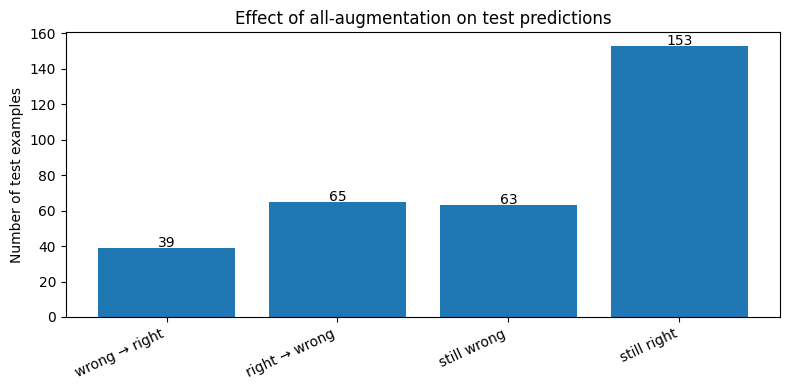

WRONG → RIGHT: plain 32 vs all augmentation
Test row 3   gold: specific   plain-32: non-specific   all-aug: specific
------------------------------------------------------------------------------------------
In December 2020, the AUC approved the Electricity Distribution and Natural Gas
Distribution requests to defer the compulsory distribution rate increases which would
normally come into effect on January 1, 2021 for both businesses. The rate relief was
requested to defer significant distribution rate increases which would be passed onto end
use customers due to the formulaic approach of rate calculations under the AUC PBR
mechanism. Electricity Distribution and Natural Gas Distribution cited the current
economic situation in Alberta, including the hardships faced by some end use customers due
to the COVID-19 pandemic, as rationale to proceed with these interim rates. Electricity
Distribution and Natural Gas Distribution are to file an application by March 1, 2021,
outlining the dura

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ID2LABEL = {v: k for k, v in LABEL2ID.items()}

gold = np.array(TEST_LABELS)
plain_pred = np.array(pred_32)
all_aug_pred = np.array(pred_aug)

plain_correct = plain_pred == gold
all_aug_correct = all_aug_pred == gold


def transition_label(before, after):
    if not before and after:
        return "wrong → right"
    if before and not after:
        return "right → wrong"
    if not before and not after:
        return "still wrong"
    return "still right"


impact_df = pd.DataFrame({
    "test_index": np.arange(len(TEST_TEXTS)),
    "text": TEST_TEXTS,
    "gold": [ID2LABEL[int(x)] for x in gold],
    "plain_pred": [ID2LABEL[int(x)] for x in plain_pred],
    "all_aug_pred": [ID2LABEL[int(x)] for x in all_aug_pred],
    "transition": [
        transition_label(b, a)
        for b, a in zip(plain_correct, all_aug_correct)
    ],
})

transition_order = ["wrong → right", "right → wrong", "still wrong", "still right"]
transition_counts = (
    impact_df["transition"].value_counts().reindex(transition_order).fillna(0).astype(int)
)

plt.figure(figsize=(8, 4))
plt.bar(transition_counts.index, transition_counts.values)
for i, v in enumerate(transition_counts.values):
    plt.text(i, v + 0.5, str(v), ha="center")
plt.title("Effect of all-augmentation on test predictions")
plt.ylabel("Number of test examples")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "plain32_vs_allaug_transition_counts.png", dpi=300, bbox_inches="tight")
plt.show()


# One representative example per transition, printed as wrapped plain text (no HTML).
BOLD = "\033[1m"
RESET = "\033[0m"
WIDTH = 90


def _wrap(text, width=WIDTH):
    lines, line = [], ""
    for w in str(text).split():
        if line and len(line) + 1 + len(w) > width:
            lines.append(line)
            line = w
        else:
            line = w if not line else line + " " + w
    if line:
        lines.append(line)
    return "\n".join(lines)


def show_one_example(df, transition):
    subset = df[df["transition"] == transition]
    if subset.empty:
        print(f"No examples for: {transition}")
        return
    row = subset.iloc[0]
    print("=" * WIDTH)
    print(f"{BOLD}{transition.upper()}: plain 32 vs all augmentation{RESET}")
    print(
        f"Test row {int(row['test_index'])}   gold: {row['gold']}   "
        f"plain-32: {row['plain_pred']}   all-aug: {row['all_aug_pred']}"
    )
    print("-" * WIDTH)
    print(_wrap(row["text"]))
    print()


show_one_example(impact_df, "wrong → right")
show_one_example(impact_df, "right → wrong")

impact_df.to_csv(TAB_DIR / "plain32_vs_allaug_transition_analysis.csv", index=False)


The transition plot makes the trade-off visible: 39 paragraphs go from wrong to right, but 65 go the other way, from right to wrong. That net loss is exactly why the headline numbers drop. The two examples show what is happening on each side. The wrong-to-right one is a long, concrete disclosure stuffed with dates and regulatory detail (an Alberta Utilities Commission rate-deferral decision). The plain model filed it as non-specific; the augmented model gets it right, so the extra data really does help it spot specificity that the obvious cues miss. The right-to-wrong one is the mirror image: a paragraph about a fund's "sustainable strategy red lines" that the augmented model suddenly calls specific, even though there is no concrete, checkable climate detail in it at all. From the looks of it, the model has started to mistake ESG-sounding language for the real thing.

So, where does 2b leave us? Even though the augmentation does not move the final score, the experiment has a reason for being: it tells us the few-shot model's real problem was not just "too few" rows. The extra variants do loosen its grip on the **non-specific** label but they trade that for a worse classifier overall: it recovers more specific paragraphs, yet drowns in false positives on the majority class. And that makes sense. EDA, numeric perturbation and lexical swaps pile on rows without really adding anything new to learn from; they just reshuffle the surface of paragraphs the model has already seen. But the hard part (as we have already seen in previous cells) here was never recognising familiar wording. It is judging whether a paragraph actually carries concrete, checkable climate detail, which one cannot learn by shuffling words or nudging a few numbers. So, what the model needs is fewer but better examples, ones picked to sit right on the tricky line between vague "sustainability" chit-chat and genuinely measurable commitments. So, we use LLMs for that and see how that goes.

### 2c. Zero-shot learning with an LLM (0.5)

Two zero-shot routes; neither sees a single labelled training example.

**(A) Local NLI zero-shot** (always runnable, no API key): `cross-encoder/nli-deberta-v3-base` scores each paragraph against one hypothesis per class.

**(B) Generative LLMs via the OpenAI API**: every test paragraph is sent with byte-identical prompts to two models, `gpt-4o` through the `chat.completions` API (`temperature=0`, the standard setting for a correctness task) and `gpt-5.5` through the `responses` API (gpt-5.x accepts no temperature parameter, so none is sent). Predictions are cached to `data/cache/zeroshot/zeroshot_<model>.csv`, so this notebook reruns keyless with zero API calls.

Both routes are evaluated with macro-F1 on the held-out `test` split, like every other method.

(A) NLI zero-shot macro-F1: 0.5426

confidence_gap: BERT-32 vs NLI zero-shot (both graded; same label, confidence differs by > 0.3):
39 rows where bert_32 and zeroshot_nli agree on the label but differ in confidence by > 0.3.


,idx,label,gold,bert_32_conf,zeroshot_nli_conf,gap,text
0,8,non-specific,non-specific,0.51,1.00,0.48,Although it is intended that governments will ...
7,74,specific,specific,0.50,0.98,0.48,"In October 2020, we approved our sustainable f..."
37,314,specific,non-specific,0.50,0.98,0.48,Our Alignment with the UN SDGs As a global cit...
18,151,specific,specific,0.51,0.99,0.48,Our goal for Mercedes-Benz Cars & Vans is to m...
21,160,specific,specific,0.50,0.97,0.47,"For example, the E-FACE fund, which was create..."
23,168,non-specific,specific,0.51,0.98,0.47,The data required for emissions calculation is...
12,90,specific,specific,0.50,0.97,0.47,"Indicator 3: Raise R$ 1,499 million in the yea..."
9,84,specific,specific,0.51,0.97,0.46,New products include our $1 per day electric v...
16,116,non-specific,non-specific,0.54,0.99,0.45,There are significant uncertainties around the...
8,77,specific,specific,0.51,0.95,0.44,– we rank among the world’s leading offshore w...


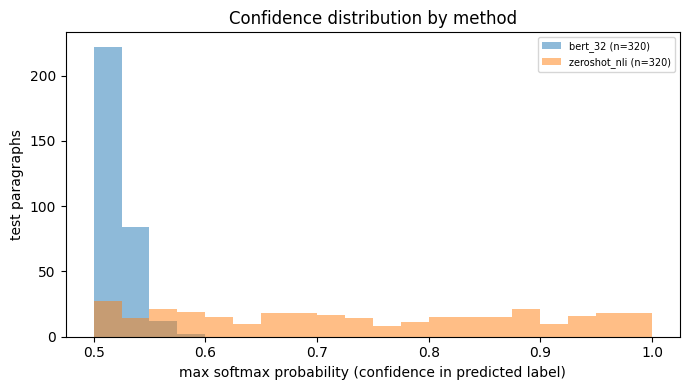

In [21]:
# (A) Local NLI zero-shot - always runnable, no API key needed.
from transformers import pipeline

zs = pipeline(
    "zero-shot-classification", model="cross-encoder/nli-deberta-v3-base", device=-1
)
HYP = {
    "specific": "This statement is specific, with concrete numbers, targets, "
    "or measurable details.",
    "non-specific": "This statement is vague and non-specific, without concrete details.",
}
inv = {v: k for k, v in HYP.items()}

zs_pred, zs_conf = [], []
for t in TEST_TEXTS:
    r = zs(t[:512], list(HYP.values()), multi_label=False)
    zs_pred.append(LABEL2ID[inv[r["labels"][0]]])
    zs_conf.append(float(r["scores"][0]))
zs_f1 = macro_f1(TEST_LABELS, zs_pred)
print(f"(A) NLI zero-shot macro-F1: {zs_f1:.4f}")
RESULTS["zeroshot_nli"] = zs_f1
PREDS["zeroshot_nli"] = list(zs_pred)
PROBS["zeroshot_nli"] = zs_conf

# The one meaningful graded-versus-graded confidence comparison (both produce real max-probabilities, unlike the
# categorical gpt cache pinned at 1.0). Where does the collapsed BERT hedge at chance on an answer NLI is sure of?
print(
    "\nconfidence_gap: BERT-32 vs NLI zero-shot (both graded; same label, confidence differs by > 0.3):"
)
display(confidence_gap("bert_32", "zeroshot_nli", threshold=0.3, n=10))
prob_hist(["bert_32", "zeroshot_nli"], path=OUT_DIR / "confidence_bert_nli.png")

The NLI route barely clears the random baselines: macro-F1 0.543. Reframing specificity as a choice between two short hypotheses turns out to be a poor fit for the task. Instead of learning what this dataset means by "specific", the model just picks whichever canned hypothesis sounds more semantically compatible, which is far too blunt for corporate disclosures. The confidence table/figure above makes the failure very clear (and instructive): NLI hands out probabilities of as much as 0.95 or higher while BERT-32 hovers around 0.50, yet NLI is no more accurate than BERT-32. So, where BERT learns a little and then hedges, NLI does not learn at all and is simply confident in the wrong places. Interesting, in the wrong way.

In [22]:
# (B) Generative-LLM setup, shared by 2c and 2d.
# The key is read from a local .env file if present; the included cache CSVs let the
# notebook rerun keyless with zero API calls - a key is only needed to REGENERATE the caches.
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / ".env")

# Two models, each called through its standard OpenAI API surface.
MODEL_REGISTRY = {
    "gpt_4o": {"model": "gpt-4o", "api": "chat"},  # chat.completions API
    "gpt_55": {"model": "gpt-5.5", "api": "responses"},  # responses API
}
ACTIVE_MODELS = list(MODEL_REGISTRY)  # edit (e.g. ["gpt_4o"]) to run a single model

# Reproducibility switch: SMOKE_N = 3 routes the LLM cells to separate _smoke_ cache files with only N
# items and no effect on RESULTS; SMOKE_N = 0 is the real run.
SMOKE_N = 0

ZS_DIR = PROJECT_ROOT / "data" / "cache" / "zeroshot"
FS_DIR = PROJECT_ROOT / "data" / "cache" / "fewshot"
ZS_DIR.mkdir(parents=True, exist_ok=True)
FS_DIR.mkdir(parents=True, exist_ok=True)


def cache_path(kind, key):
    """'llmgen' -> data/cache/generated/; 'zeroshot' -> data/cache/zeroshot/; 'fewshot*' -> data/cache/fewshot/."""
    base = GEN_DIR if kind == "llmgen" else (ZS_DIR if kind == "zeroshot" else FS_DIR)
    return base / f"{'_smoke_' if SMOKE_N else ''}{kind}_{key}.csv"


client = None
if os.environ.get("OPENAI_API_KEY"):
    from openai import OpenAI

    client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])


def llm_complete(key, system, user, temperature=None, max_tokens=400):
    """One completion for registry entry `key`; system/user are identical across models.

    gpt-4o with chat.completions with temperature/max_tokens;
    gpt-5.5 with responses API and takes no temperature -
    gpt-5.x rejects the parameter, so that branch sends the prompt text only.
    Transient 429/5xx errors are retried by the OpenAI SDK itself (2 retries, backoff).
    """
    cfg = MODEL_REGISTRY[key]
    if cfg["api"] == "chat":  # chat.completions branch
        kwargs = {} if temperature is None else {"temperature": temperature}
        r = client.chat.completions.create(
            model=cfg["model"],
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            max_tokens=max_tokens,
            **kwargs,
        )
        return (r.choices[0].message.content or "").strip()
    r = client.responses.create(
        model=cfg["model"], input=f"{system}\n\n{user}"
    )  # responses branch
    return (r.output_text or "").strip()


print(
    f"LLM setup: key={'yes' if client else 'NO (cache-only mode)'} | "
    f"models={ACTIVE_MODELS} | smoke={SMOKE_N or 'off'}"
)

LLM setup: key=yes | models=['gpt_4o', 'gpt_55'] | smoke=off


In [23]:
# 2c (B) ensure the zero-shot caches: one CSV per model; the API is called only for rows
# missing from data/cache/<kind>_<model>.csv, so reruns are free and resumable.
ZS_SYSTEM = "You are a precise text classifier."


def zs_user(text):
    return (
        "Classify the climate-disclosure statement as exactly one of: specific, non-specific. "
        "'specific' = concrete numbers, targets, or measurable detail; "
        "'non-specific' = vague/generic.\n"
        f"Statement: {text}\nAnswer with one word."
    )


def parse_pred(raw):
    """Map a raw completion to (label_id, parsed). Unparseable -> majority class, False."""
    r = (raw or "").strip().lower()
    if "specific" in r:
        lab = "non-specific" if "non" in r else "specific"
        return LABEL2ID[lab], True
    return LABEL2ID["non-specific"], False


def ensure_llm_preds(key, kind, build_user):
    """Fill data/cache/<kind>_<key>.csv, querying the API only for missing rows.

    Shared by 2c (kind='zeroshot') and the 2e few-shot add-on (kind='fewshot');
    only the user-prompt builder differs. T=0 for a correctness task;
    the temperature is ignored by gpt-5.5 (responses API takes none).
    """
    path = cache_path(kind, key)
    n = SMOKE_N or len(TEST_TEXTS)
    rows = {}
    if path.exists():
        for _, row in pd.read_csv(path).iterrows():
            if pd.notna(row["pred"]):
                rows[int(row["idx"])] = dict(row)
    missing = [i for i in range(n) if i not in rows]
    if not missing:
        print(f"[{key}] {kind} cache complete ({len(rows)}/{n}).")
        return
    if client is None:
        print(
            f"[{key}] {kind}: {len(missing)} rows missing and no OPENAI_API_KEY -> skipped."
        )
        return
    print(f"[{key}] {kind}: querying {len(missing)} of {n} test items ...")
    try:
        for done, i in enumerate(missing, 1):
            raw = llm_complete(
                key, ZS_SYSTEM, build_user(TEST_TEXTS[i]), temperature=0.0, max_tokens=8
            )
            pred_id, ok = parse_pred(raw)
            rows[i] = {
                "idx": i,
                "text": TEST_TEXTS[i],
                "gold": ID2LABEL[TEST_LABELS[i]],
                "pred": ID2LABEL[pred_id],
                "parsed": ok,
                "raw": raw,
            }
            pd.DataFrame(sorted(rows.values(), key=lambda d: d["idx"])).to_csv(
                path, index=False
            )
            if done % 25 == 0:
                print(f"  [{key}] {done}/{len(missing)}")
    except Exception as e:  # keep the partial cache; rerunning this cell resumes
        print(f"[{key}] stopped at {len(rows)}/{n} cached rows: {e!r}")


for _key in ACTIVE_MODELS:
    ensure_llm_preds(_key, "zeroshot", zs_user)

[gpt_4o] zeroshot cache complete (320/320).
[gpt_55] zeroshot cache complete (320/320).


In [24]:
# 2c (B) score cached predictions - no API calls; runs keyless from the cached CSVs.
# Missing or partial caches are reported and skipped, never fabricated.
def score_llm_cache(kind):
    """Score data/cache/<kind>_<key>.csv for every active model into RESULTS."""
    for key in ACTIVE_MODELS:
        path = cache_path(kind, key)
        n = SMOKE_N or len(TEST_TEXTS)
        if not path.exists():
            print(f"[{key}] no cache at {path.name} -> not scored.")
            continue
        df = pd.read_csv(path).sort_values("idx").reset_index(drop=True)
        if len(df) < n:
            print(
                f"[{key}] partial cache ({len(df)}/{n}) -> not scored; rerun the caching cell."
            )
            continue
        if [t[:80] for t in df["text"].astype(str)] != [t[:80] for t in TEST_TEXTS[:n]]:
            raise ValueError(
                f"{path.name} does not match TEST_TEXTS - delete the stale cache."
            )
        pred = df["pred"].map(LABEL2ID).tolist()
        f1 = macro_f1(TEST_LABELS[:n], pred)
        bad = int((~df["parsed"].astype(bool)).sum())
        print(
            f"[{key}] {kind} macro-F1 = {f1:.4f} (n={n}, unparseable -> majority: {bad})"
        )
        print(
            classification_report(TEST_LABELS[:n], pred, target_names=LABELS, digits=3)
        )
        if SMOKE_N:
            print(f"[{key}] SMOKE run -> not recorded in RESULTS.")
        else:
            RESULTS[f"{kind}_{key}"] = f1
            PREDS[f"{kind}_{key}"] = pred
            PROBS[f"{kind}_{key}"] = [
                1.0 if ok else 0.5 for ok in df["parsed"].astype(bool)
            ]


score_llm_cache("zeroshot")

[gpt_4o] zeroshot macro-F1 = 0.7006 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.728     0.964     0.830       197
    specific      0.881     0.423     0.571       123

    accuracy                          0.756       320
   macro avg      0.805     0.694     0.701       320
weighted avg      0.787     0.756     0.730       320

[gpt_55] zeroshot macro-F1 = 0.7768 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.834     0.817     0.826       197
    specific      0.717     0.740     0.728       123

    accuracy                          0.787       320
   macro avg      0.775     0.779     0.777       320
weighted avg      0.789     0.787     0.788       320



Both generative models clear the fine-tuned BERT, but in very different ways. GPT-4o lifts macro-F1 from BERT's 0.623 to 0.701 (accuracy 0.681 to 0.756) - nice. Yet, it gets there by being a "careful pessimist": it calls only 18.4% of paragraphs "specific", with non-specific recall of 0.964 and 88% precision when it does say specific. The catch is the same one we keep hitting no matter what we try: its specific recall is only 0.423, so it still misses well over half the specific disclosures. GPT-5.5 is the model that actually breaks the pattern, posting the best macro-F1 we have seen so far at 0.777. GPT 5.5, for a change, is balanced: specific recall 0.740, non-specific recall 0.817. An important step. To see how different these behaviours really are, it helps to put all four methods (and their appetite for the specific label) side by side.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Load GPT prediction CSVs
gpt4o_df = pd.read_csv(ZS_DIR / "zeroshot_gpt_4o.csv").sort_values("idx").reset_index(drop=True)
gpt55_df = pd.read_csv(ZS_DIR / "zeroshot_gpt_55.csv").sort_values("idx").reset_index(drop=True)

# Check alignment
assert (gpt4o_df["idx"].values == gpt55_df["idx"].values).all()
assert (gpt4o_df["text"].values == gpt55_df["text"].values).all()

LABELS_STR = ["non-specific", "specific"]

# Base comparison dataframe
compare_df = pd.DataFrame({
    "idx": gpt55_df["idx"],
    "text": gpt55_df["text"],
    "gold": gpt55_df["gold"],
    "gpt_4o": gpt4o_df["pred"],
    "gpt_55": gpt55_df["pred"],
})

# Add BERT and NLI if available in the notebook
# This assumes LABELS is like ["non-specific", "specific"] and PREDS stores integer labels.
if "PREDS" in globals() and "LABELS" in globals():
    if "bert_32" in PREDS:
        compare_df["bert_32"] = [LABELS[int(x)] for x in PREDS["bert_32"]]
    if "zeroshot_nli" in PREDS:
        compare_df["nli_zero_shot"] = [LABELS[int(x)] for x in PREDS["zeroshot_nli"]]

model_cols = [c for c in ["bert_32", "nli_zero_shot", "gpt_4o", "gpt_55"] if c in compare_df.columns]

rows = []

for model in model_cols:
    y_true = compare_df["gold"]
    y_pred = compare_df[model]

    rows.append({
        "model": model,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=LABELS_STR),
        "specific_recall": recall_score(y_true, y_pred, pos_label="specific"),
        "non_specific_recall": recall_score(y_true, y_pred, pos_label="non-specific"),
        "specific_precision": precision_score(y_true, y_pred, pos_label="specific"),
        "non_specific_precision": precision_score(y_true, y_pred, pos_label="non-specific"),
        "pred_specific_share": (y_pred == "specific").mean(),
    })

summary_df = pd.DataFrame(rows).round(3)
display(summary_df)

,model,accuracy,macro_f1,specific_recall,non_specific_recall,specific_precision,non_specific_precision,pred_specific_share
0,bert_32,0.681,0.623,0.374,0.873,0.648,0.691,0.222
1,nli_zero_shot,0.547,0.543,0.837,0.365,0.452,0.783,0.712
2,gpt_4o,0.756,0.701,0.423,0.964,0.881,0.728,0.184
3,gpt_55,0.788,0.777,0.740,0.817,0.717,0.834,0.397


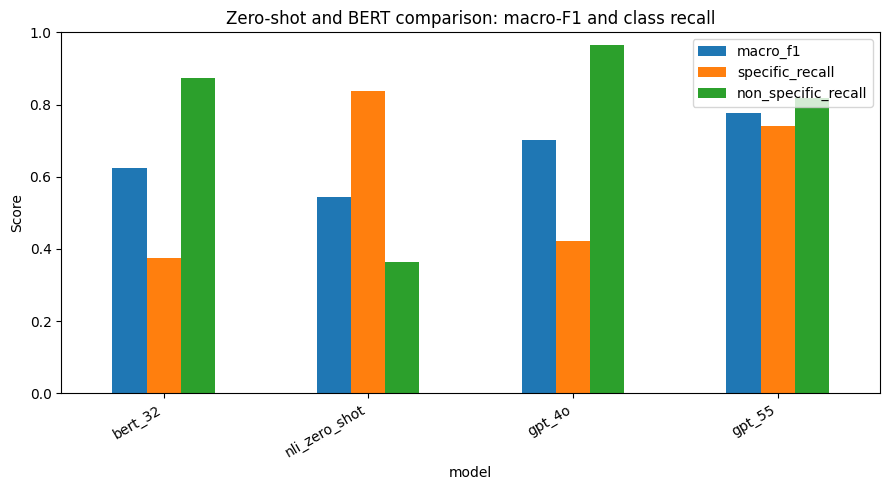

In [26]:
plot_df = summary_df.set_index("model")[[
    "macro_f1",
    "specific_recall",
    "non_specific_recall"
]]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Zero-shot and BERT comparison: macro-F1 and class recall")
ax.legend(title="")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(OUT_DIR / "model_macro_f1_class_recall.png", dpi=300, bbox_inches="tight")
plt.show()

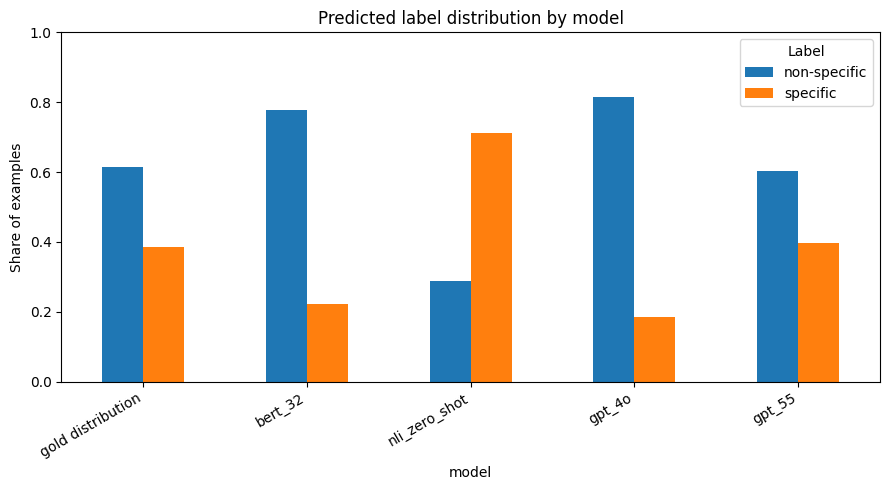

label,non-specific,specific
model,,
gold distribution,0.616,0.384
bert_32,0.778,0.222
nli_zero_shot,0.288,0.712
gpt_4o,0.816,0.184
gpt_55,0.603,0.397


In [27]:
pred_share_rows = []

true_share = compare_df["gold"].value_counts(normalize=True).reindex(LABELS_STR)

for label in LABELS_STR:
    pred_share_rows.append({
        "model": "gold distribution",
        "label": label,
        "share": true_share[label],
    })

for model in model_cols:
    pred_share = compare_df[model].value_counts(normalize=True).reindex(LABELS_STR).fillna(0)
    for label in LABELS_STR:
        pred_share_rows.append({
            "model": model,
            "label": label,
            "share": pred_share[label],
        })

pred_share_df = pd.DataFrame(pred_share_rows)

pivot = pred_share_df.pivot(index="model", columns="label", values="share").loc[
    ["gold distribution"] + model_cols
]

ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_ylim(0, 1)
ax.set_ylabel("Share of examples")
ax.set_title("Predicted label distribution by model")
ax.legend(title="Label")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(OUT_DIR / "predicted_label_distribution_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

display(pivot.round(3))

This is where GPT-5.5's edge becomes very transparent. The gold data is 38.4% specific. BERT-32 and GPT-4o both play it safe and predict specific far less often (as we have seen, 22.2% and 18.4%), while the NLI model swings the other way and over-calls specific at 71.2%. GPT-5.5 sits almost exactly on the gold rate, predicting specific 39.7% of the time. Very good! That calibration is the whole story: GPT 5.5 seems to be applying the definition at roughly the right rate, so it recovers specific disclosures without drowning in false positives. BERT only ever saw 32 labelled examples, far too few to learn the many shapes specificity takes; GPT-5.5 can lean on the prompt definition plus a lot of pretrained knowledge about corporate and climate language, which allows it to find the specific cases with a certain ease. We investigate GPT 5.5 behaviour further below.

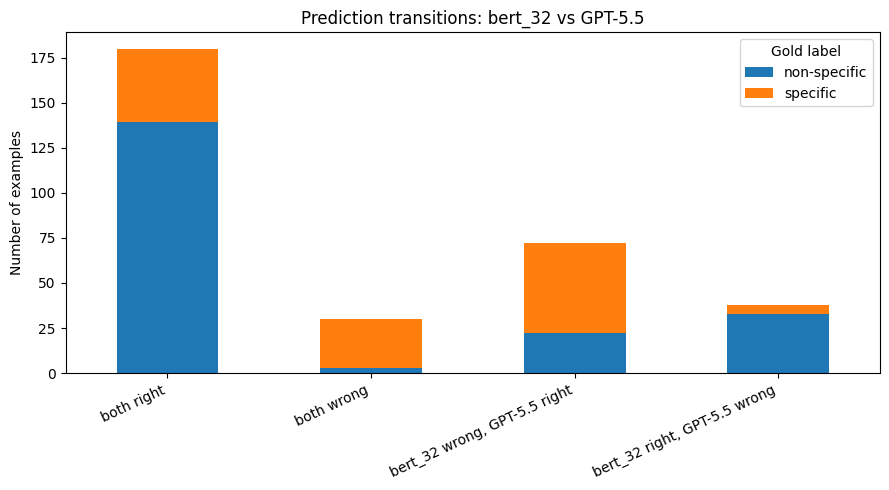

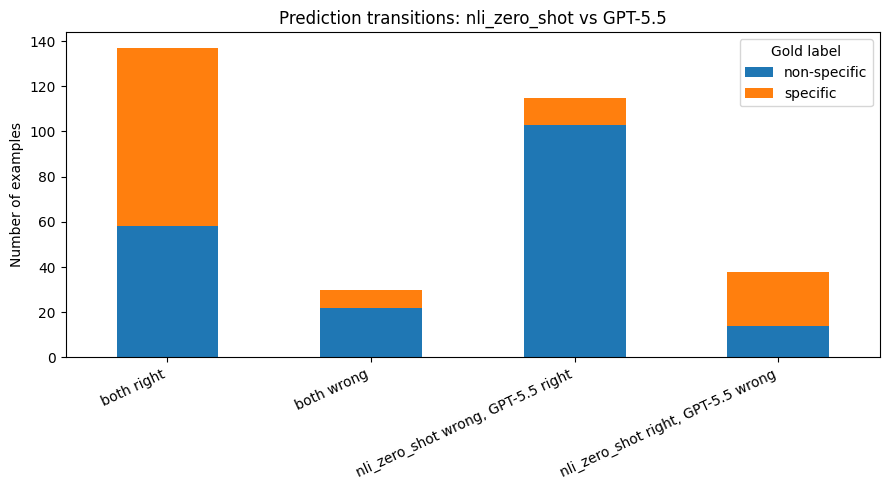

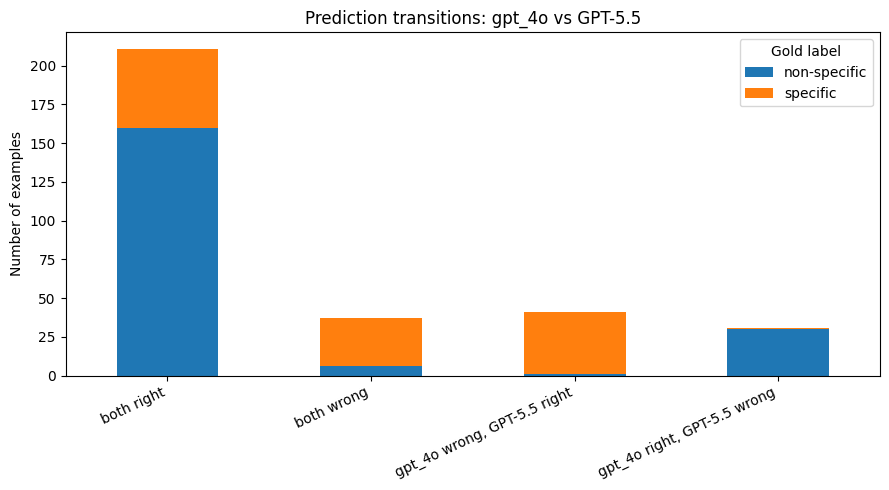

In [28]:
def transition_against_gpt55_ordered(other_model):
    tmp = compare_df.copy()

    tmp[f"{other_model}_correct"] = tmp[other_model] == tmp["gold"]
    tmp["gpt_55_correct"] = tmp["gpt_55"] == tmp["gold"]

    def transition(row):
        if row[f"{other_model}_correct"] and row["gpt_55_correct"]:
            return "both right"
        if not row[f"{other_model}_correct"] and not row["gpt_55_correct"]:
            return "both wrong"
        if not row[f"{other_model}_correct"] and row["gpt_55_correct"]:
            return f"{other_model} wrong, GPT-5.5 right"
        return f"{other_model} right, GPT-5.5 wrong"

    transition_order = [
        "both right",
        "both wrong",
        f"{other_model} wrong, GPT-5.5 right",
        f"{other_model} right, GPT-5.5 wrong",
    ]

    tmp["transition"] = tmp.apply(transition, axis=1)

    # Force desired column order
    tmp["transition"] = pd.Categorical(
        tmp["transition"],
        categories=transition_order,
        ordered=True
    )

    tab = pd.crosstab(
        tmp["gold"],
        tmp["transition"]
    ).reindex(columns=transition_order, fill_value=0)

    tab["total"] = tab.sum(axis=1)

    return tmp, tab


for other_model in [m for m in model_cols if m != "gpt_55"]:
    trans_df, trans_tab = transition_against_gpt55_ordered(other_model)

    plot_tab = trans_tab.drop(columns="total")

    ax = plot_tab.T.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5)
    )

    ax.set_title(f"Prediction transitions: {other_model} vs GPT-5.5")
    ax.set_ylabel("Number of examples")
    ax.set_xlabel("")
    ax.legend(title="Gold label")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    plt.savefig(
        OUT_DIR / f"transition_{other_model}_vs_gpt55_ordered.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

We can watch this trade happen in the transition plots we put together above: swapping BERT-32 for GPT-5.5 rescues 72 paragraphs (50 of them specific) while breaking only 38, nearly all non-specific. Against GPT-4o the asymmetry is even more evident: of the 41 paragraphs it recovers almost every one is specific, against 31 it breaks that are almost all non-specific. GPT-5.5, in other words, is not winning everywhere. Rather, it is making a deliberate bet on the specific class, a bet that pays off precisely because that class was the bottleneck all along.

So, 2c gives us our best result yet, plus an unexpected lesson/result. The headline is that a model reading a single paragraph of instructions (with no training examples at all) comfortably beats one we fine-tuned ourselves. The catch, as always, is the metric: 0.777 is macro-F1 on 320 paragraphs, not a like-for-like win over the published benchmark, which is scored differently. We pick that thread back up later.

### 2d. Data generation with an LLM (1.0)

The same two models (4o and 5.5) now *write* new labelled examples from the class definitions alone. Each model is asked for batches of 10 statements per request - "gpt-4o" at "temperature=0.9", a standard setting for creative generation; "gpt-5.5" again with no temperature - until 60 specific + 60 non-specific examples per model survive cleaning, case-folded deduplication (including against the 32 real training examples) and a >20-character length filter. Rows are cached to `data/cache/generated/llmgen_<model>.csv` after every call

We, then, fine-tune the same BERT on 32 + each model's examples and on 32 + both models pooled and compare macro-F1 deltas against the plain-32 baseline (from our 2a step)

In [29]:
# 2d ensure the generated-example caches: batched calls (~10 per request) per class and
# model until 60/class, deduplicated (case-folded, incl. against the real X32) and length-
# filtered; written to data/cache/generated/llmgen_<model>.csv after every call (resumable).
import re

GEN_SYSTEM = "You generate realistic corporate climate-disclosure sentences."
CLASS_SPEC = {
    "specific": (
        "concrete and verifiable: include a number, a unit, a percentage, an emissions "
        "figure (e.g. tonnes CO2, Scope 1/2/3), or a dated target"
    ),
    "non-specific": "vague and generic: no numbers, targets, or measurable detail",
}
N_PER_CLASS = SMOKE_N or 60  # fixed budget; FAST_MODE only shortens BERT training
GEN_BATCH = 10


def gen_user(lbl):
    return (
        f"Write {GEN_BATCH} distinct one-paragraph climate/sustainability statements from a "
        f"corporate report that are {lbl} ({CLASS_SPEC[lbl]}). One per line, no numbering."
    )


def clean_lines(raw):
    lines = [
        re.sub(r"^\s*(?:[-*•]|\d+[.)])\s*", "", x).strip()
        for x in (raw or "").splitlines()
    ]
    return [x for x in lines if len(x) > 20]  # drop headers, blanks, short fragments


def ensure_generated(key):
    path = cache_path("llmgen", key)
    rows = pd.read_csv(path).to_dict("records") if path.exists() else []
    seen = {t.casefold() for t in X32} | {str(r["text"]).casefold() for r in rows}
    need = {lbl: N_PER_CLASS - sum(r["label"] == lbl for r in rows) for lbl in LABELS}
    if all(v <= 0 for v in need.values()):
        print(f"[{key}] generation cache complete ({len(rows)} rows).")
        return
    if client is None:
        print(f"[{key}] generation incomplete and no OPENAI_API_KEY -> skipped.")
        return
    try:
        for lbl in LABELS:
            calls, max_calls = 0, 3 * (N_PER_CLASS // GEN_BATCH + 1)  # runaway-loop cap
            while need[lbl] > 0 and calls < max_calls:
                calls += 1
                # Creative task -> T=0.9; ignored by gpt-5.5.
                raw = llm_complete(
                    key, GEN_SYSTEM, gen_user(lbl), temperature=0.9, max_tokens=1200
                )
                for t in clean_lines(raw):
                    if need[lbl] <= 0 or t.casefold() in seen:
                        continue
                    seen.add(t.casefold())
                    rows.append({"text": t, "label": lbl, "model": key})
                    need[lbl] -= 1
                pd.DataFrame(rows).to_csv(path, index=False)
            if need[lbl] > 0:
                print(
                    f"[{key}/{lbl}] still short {need[lbl]} examples after {calls} calls."
                )
    except Exception as e:  # keep the partial cache; rerunning this cell resumes
        print(f"[{key}] stopped: {e!r}")
    if rows:
        counts = dict(pd.DataFrame(rows)["label"].value_counts())
        print(f"[{key}] cached {len(rows)} generated examples: {counts}")
    else:
        print(f"[{key}] no generated examples cached.")


for _key in ACTIVE_MODELS:
    ensure_generated(_key)

[gpt_4o] generation cache complete (120 rows).
[gpt_55] generation cache complete (120 rows).


In [30]:
# 2d fine-tune on 32 real + generated examples: one run per model plus a pooled run.
GEN_SETS = {}  # RESULTS key -> (texts, labels); 2e picks the best candidate from these
gen_frames = {
    k: pd.read_csv(cache_path("llmgen", k))
    for k in ACTIVE_MODELS
    if cache_path("llmgen", k).exists()
}

if SMOKE_N:
    print("SMOKE run -> 2d training skipped, RESULTS untouched.")
elif not gen_frames:
    print(
        "No generation caches and no API key: 2d skipped (no synthetic data fabricated)."
    )
else:
    runs = {f"bert_32_llmgen_{k}": g for k, g in gen_frames.items()}
    if len(gen_frames) >= 2:  # pooled set: all models' rows, deduplicated across models
        pooled = pd.concat(gen_frames.values(), ignore_index=True)
        pooled = pooled.loc[~pooled["text"].astype(str).str.casefold().duplicated()]
        runs["bert_32_llmgen_pooled"] = pooled
    for rk, g in runs.items():
        Xg = X32 + g["text"].astype(str).tolist()
        yg = y32 + g["label"].map(LABEL2ID).tolist()
        f1_gen, pred_gen, _, _ = train_eval(
            Xg, yg, TEST_TEXTS, TEST_LABELS, epochs=FS_EPOCHS, label=rk
        )
        RESULTS[rk] = f1_gen
        PREDS[rk] = list(pred_gen)
        GEN_SETS[rk] = (Xg, yg)
        print(
            f"  {rk}: n={len(Xg)}  macro-F1={f1_gen:.4f}  delta vs plain 32: {f1_gen - f1_32:+.4f}"
        )

{'train_runtime': 39.1898, 'train_samples_per_second': 38.786, 'train_steps_per_second': 2.552, 'train_loss': 0.16392305374145508, 'epoch': 10.0}


[bert_32_llmgen_gpt_4o] macro-F1 = 0.7637  (train n=152)
  bert_32_llmgen_gpt_4o: n=152  macro-F1=0.7637  delta vs plain 32: +0.1410


{'train_runtime': 38.9188, 'train_samples_per_second': 39.056, 'train_steps_per_second': 2.569, 'train_loss': 0.17638473510742186, 'epoch': 10.0}


[bert_32_llmgen_gpt_55] macro-F1 = 0.7351  (train n=152)
  bert_32_llmgen_gpt_55: n=152  macro-F1=0.7351  delta vs plain 32: +0.1123


{'train_runtime': 69.2629, 'train_samples_per_second': 39.271, 'train_steps_per_second': 2.454, 'train_loss': 0.09573165669160731, 'epoch': 10.0}


[bert_32_llmgen_pooled] macro-F1 = 0.7228  (train n=272)
  bert_32_llmgen_pooled: n=272  macro-F1=0.7228  delta vs plain 32: +0.1000


Now this is more like it. Each model writes 120 examples (60 specific, 60 non-specific), we fold them into the 32 real ones and retrain. Where the rule-based augmentation in 2b actually hurt, generated data clearly helps (which is somewhat reassuring): GPT-4o's examples give the best run at 0.764, GPT-5.5's give 0.735, pooling both gives 0.723. Every one of these clears the plain-32 baseline (0.623) by a wide margin; all of them beat the 2b augmentation (0.597) handily. That gap is very illustrative of what we are finding as we go further: reshuffling words just rephrases what the model has already seen, whereas an LLM writing fresh disclosures genuinely widens the range of specific and non-specific paragraphs it gets to learn from.

Two things in those numbers are, however, worth a minute of thinking. First, the better classifier is not the better generator: GPT-5.5 was the stronger zero-shot model, yet GPT-4o's synthetic data trains a better BERT. Classifying and writing are, of course, different jobs; for training a small model, what matters is not the most sophisticated prose but examples with clear, learnable class separation, which GPT-4o seems to be able to supply better than 5.5. Second, pooling both models' examples is worse than using GPT-4o's alone. So more synthetic data is not automatically better. If the two models write in slightly different styles or draw the boundary in slightly different places, mixing them seems to create some confusion/loss of signal. And so, for a small model on limited real data, a consistent signal beats a bigger but noisier one. Very interesting. All of which raises the obvious question: is this synthetic data a free lunch? Let's read it.

In [31]:
# We read the synthetic data rather than only summarising it. First, the
# asymmetry: gpt-5.5 classifies better but gpt-4o generates better, so we read both side by side. Second, a
# register check: do these read like real corporate disclosure, or like generic model prose?
import pandas as pd


def _show(label, n=5):
    print(f"\n##### gold-'{label}' paragraphs #####")
    real = [t for t, y in zip(X32, y32) if ID2LABEL[y] == label][:n]
    print(">> REAL (train):")
    for t in real:
        print("   -", t[:150])
    for m in ["gpt_4o", "gpt_55"]:
        syn = pd.read_csv(GEN_DIR / f"llmgen_{m}.csv")
        syn = syn[syn["label"] == label]["text"].tolist()[:n]
        print(f">> {m} SYNTHETIC:")
        for t in syn:
            print("   -", t[:150])


_show("specific")
_show("non-specific")


##### gold-'specific' paragraphs #####
>> REAL (train):
   - We are Australia's largest corporate purchaser of electricity from renewable projects connected to the grid under project specific agreements. While t
   - We have imposed restrictions on providing loans, advice and insurance to controversial and socially sensitive sectors and activities such as: the ener
   - (€165 million equivalent) loan to finance the construction of a high-efficiency combined-cycle gas turbine (CCGT) power plant near the city of Kirikka
   - 3) Active Ownership: engagement and voting activities We actively engage with companies to foster their efforts in aligning with a below 2 C world in 
   - Risk Impact Assessment of change in risk year-on-year Mitigation of risk absorber tubes, blades, PV panels or transformers are susceptible to being da
>> gpt_4o SYNTHETIC:
   - In 2022, our company achieved a 15% reduction in Scope 1 and Scope 2 greenhouse gas emissions, decreasing our total emissions from 250,00

Reading them side by side, the synthetic specific examples are quite convincing: GPT-4o offers things like "a 15% reduction in Scope 1 and Scope 2 emissions, from 250,000 tonnes CO2e"; GPT-5.5 writes "Scope 1 and Scope 2 emissions were 48,600 tonnes CO2e, a 12% reduction". They hit every surface cue the class definition asks for: numbers, units, baselines, dated targets. But then we put them next to the real training paragraphs and a (big) difference jumps out. The real disclosures, as we have seen in our EDA, ramble on, hedge and bury their specifics inside long, messy corporate prose. On the other hand, the synthetic ones are crisp, self-contained one-liners that almost feel "built" to be classified. That tidiness is convenient for training, but it is also a little suspicious so we measure just how far the synthetic text drifts from the real thing.

In [32]:
# Is the synthetic data a free lunch? We compare the LLM-written paragraphs
# to the 32 real ones on length, lexical richness and vocabulary overlap.
import pandas as pd

_real = X32
for _m in ["gpt_4o", "gpt_55"]:
    print(f"--- real 32 vs {_m} synthetic ---")
    _syn = pd.read_csv(GEN_DIR / f"llmgen_{_m}.csv")["text"].tolist()
    synth_vs_real(_real, _syn)
    print()

--- real 32 vs gpt_4o synthetic ---
             mean_len   type-token-ratio
  real          82.2        0.438
  synthetic     25.2        0.249
  share of synthetic vocabulary that also appears in the real training text: 31.8%

--- real 32 vs gpt_55 synthetic ---
             mean_len   type-token-ratio
  real          82.2        0.438
  synthetic     22.1        0.257
  share of synthetic vocabulary that also appears in the real training text: 33.7%



And the numbers back that up. The real paragraphs average about 82 words while the synthetic ones come in at around a third of that (roughly 25 words from GPT-4o and 22 from GPT-5.5). They also happen to be less varied: a type-token ratio near 0.25 against the real 0.44, with a third of their vocabulary even appearing in the real training set. In short, the generated data is a much cleaner, tidier version of corporate disclosures. Which is probably why it helps as much as it does (but no more than that): it teaches the broad split between concrete and vague disclosures (which is most of the job) but it never sees the genuinely borderline cases that make the hand-labelled test set hard.

So 2d is the pick of the few-shot bunch. Where reshuffling words went nowhere, writing brand-new examples adds useful signal and pushes the best run up to 0.764. But it does not change the bottom line. Generated data is a helpful supplement to real labels but does not work as a replacement for them. Even at its best it still falls just short of plain zero-shot GPT-5.5 (our 0.777 from above).

### The best trained BERT-model

Based on the results from Parts 2a-2d, we now identify the BERT-model with the largest measured gain (plain 32 labels, the augmentation from 2b or the LLM-generated data from 2d). We, then, retrain the best model once more under the same few-sample budget and carry this model into Part 3 and Part 4. We also check how sensitive the 32-label result is to the particular examples selected for training. As seen in Part 2a, performance can vary substantially depending on the draw. We, therefore, resample the 32-example training set four times, use the median result as a more stable baseline and then test whether the gains from augmentation and LLM-generated data still hold against that baseline.

In [33]:
# Pick the best augmentation/generation route by measured delta.
candidate_sets = {"bert_32_augmented": (X_aug, y_aug), **GEN_SETS}  # GEN_SETS comes from 2d
candidates = {k: RESULTS[k] for k in candidate_sets if k in RESULTS}
print("Part-2 candidates:", {k: round(v, 4) for k, v in candidates.items()})

best_key = max(candidates, key=candidates.get) if candidates else None
X_best, y_best = candidate_sets[best_key] if best_key else (X32, y32)
print("Chosen training set:", best_key or "plain 32 (no candidates available)")

# Optimal run: best data under the same few-sample budget - the edge must come from data.
f1_best, pred_best, model_best, tok_best = train_eval(
    X_best, y_best, TEST_TEXTS, TEST_LABELS, epochs=FS_EPOCHS, label="bert32_optimal"
)
RESULTS["bert_32_optimal"] = f1_best
PREDS["bert_32_optimal"] = list(pred_best)
PROBS["bert_32_optimal"] = bert_maxprob(model_best, tok_best, TEST_TEXTS)[1]

Part-2 candidates: {'bert_32_augmented': 0.5973, 'bert_32_llmgen_gpt_4o': 0.7637, 'bert_32_llmgen_gpt_55': 0.7351, 'bert_32_llmgen_pooled': 0.7228}
Chosen training set: bert_32_llmgen_gpt_4o


{'train_runtime': 38.8651, 'train_samples_per_second': 39.11, 'train_steps_per_second': 2.573, 'train_loss': 0.17215465545654296, 'epoch': 10.0}


[bert32_optimal] macro-F1 = 0.7417  (train n=152)


After retraining, the best BERT model by F1 score is trained with the original 32 labelled examples plus GPT-4o generated data. It outperforms simple augmentation, GPT-5.5-generated data and the pooled synthetic dataset. When we retrain this model here, it reaches a macro-F1 of 0.742. This is slightly lower than our earlier GPT-4o synthetic-data run of 0.764, which is consistent with the fine-tuning variance we have seen throughout the few-shot experiments. We, therefore, use `bert_32_optimal` as the strongest local trained model carried forward into Part 3 and Part 4. To reiterate, this model is not trained on the full labelled dataset. Instead, its advantage comes from adding GPT-4o-generated synthetic examples to the original 32 real labels.

{'train_runtime': 8.1818, 'train_samples_per_second': 39.111, 'train_steps_per_second': 2.444, 'train_loss': 0.6664421558380127, 'epoch': 10.0}


[bert32_d42] macro-F1 = 0.6160  (train n=32)


{'train_runtime': 4.8751, 'train_samples_per_second': 65.64, 'train_steps_per_second': 4.103, 'train_loss': 0.6700589179992675, 'epoch': 10.0}


[bert32_d7] macro-F1 = 0.6867  (train n=32)


{'train_runtime': 7.4963, 'train_samples_per_second': 42.688, 'train_steps_per_second': 2.668, 'train_loss': 0.6598092555999756, 'epoch': 10.0}


[bert32_d123] macro-F1 = 0.6943  (train n=32)


{'train_runtime': 6.052, 'train_samples_per_second': 52.875, 'train_steps_per_second': 3.305, 'train_loss': 0.6636670112609864, 'epoch': 10.0}


[bert32_d2024] macro-F1 = 0.6303  (train n=32)
BERT-32 over 4 different 32-draws: [0.616, 0.687, 0.694, 0.63] | mean 0.657 +/- 0.034
honest baseline = median draw (F1=0.687, pred_32_med).


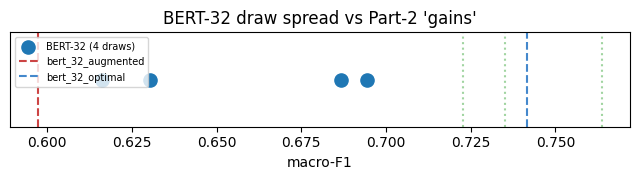


re-baselined bootstraps (vs median-draw BERT-32):
augmentation:


macro-F1 diff (B-A) = -0.0894, 95% CI [-0.1505, -0.0284]  ->  A clearly better
best synthetic (bert_32_llmgen_gpt_4o):


macro-F1 diff (B-A) = +0.0770, 95% CI [+0.0138, +0.1376]  ->  B clearly better


(0.07700787237804063,
 np.float64(0.013795563908932416),
 np.float64(0.13760250343529265))

In [34]:
# Robustness of the 32-label result: a 32-label run depends heavily on WHICH 32 examples you
# happen to draw (the labelled training set, not the in-prompt demonstrations used later). Resample a
# different stratified 32 per draw, show the spread and re-baseline the augmentation and generation gains on the
# median draw (variance comes from the data, robust to train_eval's seed handling).
import matplotlib.pyplot as plt
import numpy as np
_sf1, _spred = [], []
for _s in [42, 7, 123, 2024]:
    _bud = stratified_sample(pool_df, 32, seed=_s)
    _f, _p, _, _ = train_eval(_bud["text"].tolist(), _bud["label_id"].tolist(),
                              TEST_TEXTS, TEST_LABELS, epochs=FS_EPOCHS, label=f"bert32_d{_s}")
    _sf1.append(_f); _spred.append(list(_p))
_med = int(np.argsort(_sf1)[len(_sf1) // 2])
pred_32_med = _spred[_med]; NOISE_BAND = float(np.std(_sf1))
print(f"BERT-32 over 4 different 32-draws: {[round(x, 3) for x in _sf1]} | mean {np.mean(_sf1):.3f} +/- {NOISE_BAND:.3f}")
print(f"honest baseline = median draw (F1={_sf1[_med]:.3f}, pred_32_med).")
plt.figure(figsize=(6.5, 1.9))
plt.scatter(_sf1, [0] * len(_sf1), s=90, label="BERT-32 (4 draws)", zorder=3)
for k, c in [("bert_32_augmented", "#c44"), ("bert_32_optimal", "#48c")]:
    if k in RESULTS: plt.axvline(RESULTS[k], ls="--", c=c, label=k)
for k in [k for k in RESULTS if "llmgen" in k]:
    plt.axvline(RESULTS[k], ls=":", c="#4a4", alpha=0.5)
plt.yticks([]); plt.xlabel("macro-F1"); plt.title("BERT-32 draw spread vs Part-2 'gains'")
plt.legend(fontsize=7, loc="upper left"); plt.tight_layout()
plt.savefig(OUT_DIR / "seed_spread.png", dpi=130); plt.show()
print("\nre-baselined bootstraps (vs median-draw BERT-32):")
print("augmentation:"); paired_bootstrap(TEST_LABELS, pred_32_med, PREDS["bert_32_augmented"])
_best_syn = max([k for k in PREDS if "llmgen" in k], key=lambda k: RESULTS[k])
print(f"best synthetic ({_best_syn}):"); paired_bootstrap(TEST_LABELS, pred_32_med, PREDS[_best_syn])

As in Part 2a, the performance of the 32-label BERT model depends heavily on which examples are drawn for training. So, we repeat the experiment across four stratified draws and use the median result, 0.687 macro-F1, as a more reliable baseline than any single 32-example sample. The plot above shows the results from this robustness check. The scores range from 0.616 to 0.694, showing that few-shot performance is very evidently affected by sampling variance. Taking the median result, therefore, ensures that the improvement from GPT-4o-generated data is not just an artefact of comparing against a weak collapsed baseline. Even after accounting for normal few-shot sample variance, LLM-generated data is the only training-data strategy in Part 2 that seems to produce a robust improvement.

### 2e. Optimal technique (0.5)

The previous experiments suggest that the most effective direction is not further fine-tuning of the 32-example BERT model but prompt-based LLM classification. In particular, zero-shot GPT-5.5 achieved the strongest performance among the methods tested so far. A natural extension is, thus, to introduce one-shot and few-shot prompting. Rather than updating model weights, few-shot prompting uses labelled examples as demonstrations inside the prompt, which may help align the model with the dataset’s annotation standard. This is especially relevant for our task because, as it is abundantly clear by now, the boundary between **specific** and **non-specific** disclosures is very subtle. Showing the model examples of how these labels are applied could, therefore, improve calibration beyond the zero-shot prompt. So, we consider the model performance with incrementally increasing examples: 0 -> 1 -> 2 -> 4 -> 8 -> 16 -> 32.

In [35]:
# Few-shot prompting: the same contract as the zero-shot prompt, with the 32 labelled examples prepended to every
# prompt (standard few-shot pattern). Cache: data/cache/fewshot/fewshot_<model>.csv.
FEWSHOT_BLOCK = "Here are some examples:\n\n" + "\n\n".join(
    f"Statement: {t}\nAnswer: {ID2LABEL[y]}" for t, y in zip(X32, y32)
)


def fs_user(text):
    return f"{FEWSHOT_BLOCK}\n\n{zs_user(text)}"


for _key in ACTIVE_MODELS:
    ensure_llm_preds(_key, "fewshot", fs_user)

[gpt_4o] fewshot cache complete (320/320).
[gpt_55] fewshot cache complete (320/320).


In [36]:
# Few-shot scoring from the cache (keyless), then the head-to-head comparison.
score_llm_cache("fewshot")

head2head = {
    k: round(v, 4)
    for k, v in RESULTS.items()
    if k.startswith(("zeroshot_gpt", "fewshot_")) or k == "bert_32_optimal"
}
print("2e head-to-head:", dict(sorted(head2head.items(), key=lambda kv: kv[1])))

[gpt_4o] fewshot macro-F1 = 0.8217 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.863     0.863     0.863       197
    specific      0.780     0.780     0.780       123

    accuracy                          0.831       320
   macro avg      0.822     0.822     0.822       320
weighted avg      0.831     0.831     0.831       320

[gpt_55] fewshot macro-F1 = 0.7994 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.822     0.893     0.856       197
    specific      0.802     0.691     0.742       123

    accuracy                          0.816       320
   macro avg      0.812     0.792     0.799       320
weighted avg      0.815     0.816     0.813       320

2e head-to-head: {'zeroshot_gpt_4o': 0.7006, 'bert_32_optimal': 0.7417, 'zeroshot_gpt_55': 0.7768, 'fewshot_gpt_55': 0.7994, 'fewshot_gpt_4o': 0.8217}


Few-shot prompting gives the strongest result in the project so far. Adding labelled examples directly into the prompt improves both models but the effect is clearest for GPT-4o. Its macro-F1 rises to 0.822, above zero-shot GPT-5.5 and the best trained local BERT model, bert_32_optimal. At the same time, GPT-4o becomes much more balanced across the two classes, with precision and recall matching within each class. This suggests that the labelled examples help it move away from the conservative behaviour seen in the zero-shot setting and apply the dataset’s specificity standard more consistently. Very successful experiment.

The few-shot result above uses all 32 labelled examples while the zero-shot result in 2c, of course, none. Those are the two endpoints of a curve and the natural "apply the best technique and further improve" question is what happens between these two extrema we have on our hands: how fast does macro-F1 climb as we add demonstrations, 0 -> 1 -> 2 -> 4 -> 8 -> 16 -> 32? Does a single example already capture most of the gain or does the score keep climbing all the way to 32?

Every intermediate `k` reuses the same setup from 2c and 2e (same system prompt, temperature 0, one-word answer, cached on disk), changing only how many demonstrations we prepend. To keep the points comparable, the demonstrations are a class-balanced, nested subset of the 32: the first `ceil(k/2)` specific and `floor(k/2)` non-specific paragraphs, so no prompt collapses onto a single class and every smaller `k` sits inside the larger one. `k=0` and `k=32` come from the caches already scored above, so the cells below only cover `k in {1, 2, 4, 8, 16}`.

In [37]:
# Demonstration-count curve, generation. Same contract and CSV format as ensure_llm_preds
# (the zero-shot helper): query the API only for rows missing from data/cache/fewshot/fewshot_k<k>_<model>.csv, so a
# key is needed only the first time and reruns are free. Because the five k-values by two models
# is ten caches of 320 calls each, we fill each cache with concurrent requests instead of one at
# a time; at temperature 0 the predictions are identical to a sequential run, only faster. The
# pass-loop refills any row dropped to a rate-limit (429) until the cache is complete.
from concurrent.futures import ThreadPoolExecutor, as_completed

SHOT_GRID = [1, 2, 4, 8, 16]  # k=0 (zeroshot_*) and k=32 (fewshot_*) are already cached above
FS_WORKERS = 8

# Split the 32 demonstrations by class, preserving their order in X32.
_demo_spec = [(t, y) for t, y in zip(X32, y32) if ID2LABEL[y] == "specific"]
_demo_nons = [(t, y) for t, y in zip(X32, y32) if ID2LABEL[y] == "non-specific"]


def kshot_demos(k):
    """Class-balanced, nested subset of size k from the 32-shot pool, classes interleaved.

    floor(k/2) come from each class; an odd example goes to 'specific', the harder class.
    """
    n_spec, n_nons = (k + 1) // 2, k // 2
    demos = []
    for s, n in zip(_demo_spec[:n_spec], _demo_nons[:n_nons]):
        demos += [s, n]
    if n_spec > n_nons:
        demos.append(_demo_spec[n_nons])
    return demos[:k]


def make_fs_user(k):
    """A 2c-style user-prompt builder with k demonstrations prepended."""
    block = "Here are some examples:\n\n" + "\n\n".join(
        f"Statement: {t}\nAnswer: {ID2LABEL[y]}" for t, y in kshot_demos(k)
    )
    return lambda text: f"{block}\n\n{zs_user(text)}"


def ensure_fewshot_parallel(key, kind, build_user, workers=FS_WORKERS, max_passes=12):
    """Concurrent twin of ensure_llm_preds: identical CSV (idx, text, gold, pred, parsed, raw)
    and resumable contract, querying the API only for missing rows but many at once. Repeats in
    passes until the cache is complete, so a row dropped to a 429 is always refilled. At
    temperature 0 the result is identical to the sequential ensure_llm_preds, only faster."""
    path = cache_path(kind, key)
    n = SMOKE_N or len(TEST_TEXTS)
    rows = {}
    if path.exists():
        for _, row in pd.read_csv(path).iterrows():
            if pd.notna(row["pred"]):
                rows[int(row["idx"])] = dict(row)
    if len(rows) >= n:
        print(f"[{key}] {kind} cache complete ({len(rows)}/{n}).")
        return
    if client is None:
        print(f"[{key}] {kind}: {n - len(rows)} rows missing and no OPENAI_API_KEY -> skipped.")
        return

    def one(i):
        raw = llm_complete(key, ZS_SYSTEM, build_user(TEST_TEXTS[i]), temperature=0.0, max_tokens=8)
        pid, ok = parse_pred(raw)
        return i, {"idx": i, "text": TEST_TEXTS[i], "gold": ID2LABEL[TEST_LABELS[i]],
                   "pred": ID2LABEL[pid], "parsed": ok, "raw": raw}

    for _pass in range(max_passes):
        missing = [i for i in range(n) if i not in rows]
        if not missing:
            break
        print(f"[{key}] {kind}: querying {len(missing)} of {n} test items ({workers} workers)...")
        with ThreadPoolExecutor(max_workers=workers) as ex:
            futs = {ex.submit(one, i): i for i in missing}
            done = 0
            for fut in as_completed(futs):
                try:
                    i, rec = fut.result()
                except Exception:
                    continue  # transient 429/5xx: left missing, refilled on the next pass
                rows[i] = rec
                done += 1
                if done % 50 == 0:
                    pd.DataFrame(sorted(rows.values(), key=lambda d: d["idx"])).to_csv(path, index=False)
        pd.DataFrame(sorted(rows.values(), key=lambda d: d["idx"])).to_csv(path, index=False)
    print(f"[{key}] {kind} cache complete ({len(rows)}/{n}).")


for k in SHOT_GRID:
    comp = pd.Series([ID2LABEL[y] for _, y in kshot_demos(k)]).value_counts().to_dict()
    print(f"--- {k}-shot (demonstrations by class: {comp}) ---")
    for _key in ACTIVE_MODELS:
        ensure_fewshot_parallel(_key, f"fewshot_k{k}", make_fs_user(k))

--- 1-shot (demonstrations by class: {'specific': 1}) ---
[gpt_4o] fewshot_k1 cache complete (320/320).
[gpt_55] fewshot_k1 cache complete (320/320).
--- 2-shot (demonstrations by class: {'specific': 1, 'non-specific': 1}) ---
[gpt_4o] fewshot_k2 cache complete (320/320).
[gpt_55] fewshot_k2 cache complete (320/320).
--- 4-shot (demonstrations by class: {'specific': 2, 'non-specific': 2}) ---
[gpt_4o] fewshot_k4 cache complete (320/320).
[gpt_55] fewshot_k4 cache complete (320/320).
--- 8-shot (demonstrations by class: {'specific': 4, 'non-specific': 4}) ---
[gpt_4o] fewshot_k8 cache complete (320/320).
[gpt_55] fewshot_k8 cache complete (320/320).
--- 16-shot (demonstrations by class: {'specific': 8, 'non-specific': 8}) ---
[gpt_4o] fewshot_k16 cache complete (320/320).
[gpt_55] fewshot_k16 cache complete (320/320).


[gpt_4o] fewshot_k1 macro-F1 = 0.7630 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.770     0.954     0.853       197
    specific      0.882     0.545     0.673       123

    accuracy                          0.797       320
   macro avg      0.826     0.750     0.763       320
weighted avg      0.813     0.797     0.784       320

[gpt_55] fewshot_k1 macro-F1 = 0.7899 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.845     0.827     0.836       197
    specific      0.732     0.756     0.744       123

    accuracy                          0.800       320
   macro avg      0.788     0.792     0.790       320
weighted avg      0.801     0.800     0.801       320

[gpt_4o] fewshot_k2 macro-F1 = 0.7783 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.791     0.924     0.852       197
    specific   

              precision    recall  f1-score   support

non-specific      0.857     0.853     0.855       197
    specific      0.766     0.772     0.769       123

    accuracy                          0.822       320
   macro avg      0.812     0.813     0.812       320
weighted avg      0.822     0.822     0.822       320

[gpt_4o] fewshot_k16 macro-F1 = 0.8217 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.863     0.863     0.863       197
    specific      0.780     0.780     0.780       123

    accuracy                          0.831       320
   macro avg      0.822     0.822     0.822       320
weighted avg      0.831     0.831     0.831       320

[gpt_55] fewshot_k16 macro-F1 = 0.7965 (n=320, unparseable -> majority: 0)
              precision    recall  f1-score   support

non-specific      0.850     0.832     0.841       197
    specific      0.740     0.764     0.752       123

    accuracy                    

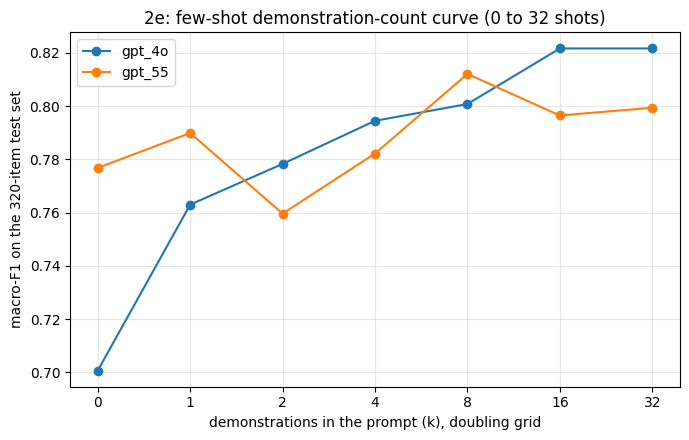

In [38]:
# Demonstration-count curve, scoring and plot (keyless, from the caches). Assemble the
# full 0 -> 32 curve, save a tidy summary next to the caches and draw macro-F1 vs k.
for k in SHOT_GRID:
    score_llm_cache(f"fewshot_k{k}")


def _curve_key(model, k):
    if k == 0:
        return f"zeroshot_{model}"
    if k == 32:
        return f"fewshot_{model}"
    return f"fewshot_k{k}_{model}"


CURVE_K = [0] + SHOT_GRID + [32]
curve_rows = [
    {"model": m, "k": k, "macro_f1": round(RESULTS[_curve_key(m, k)], 4)}
    for m in ACTIVE_MODELS
    for k in CURVE_K
    if _curve_key(m, k) in RESULTS
]
curve_df = pd.DataFrame(curve_rows)

if curve_df.empty:
    print("No curve yet: run the generation cell above with an API key in .env first.")
else:
    curve_path = FS_DIR / "fewshot_curve.csv"
    curve_df.to_csv(curve_path, index=False)
    print(curve_df.pivot(index="k", columns="model", values="macro_f1").to_string())
    print(f"\nsaved curve -> {curve_path.relative_to(PROJECT_ROOT)}")

    xs = list(range(len(CURVE_K)))  # evenly spaced doubling grid, k labels below
    plt.figure(figsize=(7, 4.5))
    for m in ACTIVE_MODELS:
        ys = curve_df[curve_df["model"] == m].set_index("k").reindex(CURVE_K)["macro_f1"]
        plt.plot(xs, ys.values, marker="o", label=m)
    plt.xticks(xs, [str(k) for k in CURVE_K])
    plt.xlabel("demonstrations in the prompt (k), doubling grid")
    plt.ylabel("macro-F1 on the 320-item test set")
    plt.title("2e: few-shot demonstration-count curve (0 to 32 shots)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fewshot_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

The plot provides evidence that few-shot prompting can help, although the gains are not perfectly monotonic (would have been nice). For GPT-4o, performance rises substantially from the zero-shot setting, increasing from around 0.70 macro-F1 at zero demonstrations to above 0.82 by 16 demonstrations. In particular, this improvement reflects that as $k$ increases, GPT-4o becomes much less conservative on the specific class. With one demonstration, it has high precision for specific disclosures but much lower recall (so, it only predicts specific when the evidence is in its face). By 16 demonstrations, precision and recall for the specific class are both around 0.78 while the non-specific class is also balanced at around 0.86. This suggests that GPT-4o benefits strongly from seeing labelled examples and that the demonstrations help it recover from the conservative behaviour we have observed in the zero-shot results before. 

GPT-5.5 starts from a stronger zero-shot baseline, around 0.78 macro-F1 so there is less room for improvement. It still improves with some demonstrations, peaking at around 8 shots but then slightly declines or plateaus at higher demonstration counts. This likely reflects that once a model already has a strong zero-shot understanding of the task, additional examples may help only if they are representative and concise. If the prompt includes examples that are noisy, they may add ambiguity rather than useful guidance. Overall, the results suggest that few-shot prompting is a promising way to extend the strongest zero-shot approach but they also show that performance depends on the number and quality of demonstrations. This motivates a closer analysis of few-shot prompting in the next section, focusing not only on whether examples improve performance but also on how many examples are useful and how sensitive the model is to the examples selected.


## Part 3 - State-of-the-art comparison, full data (2 pts)

### 3a. Incremental training: 1, 10, 25, 50, 75, 100% (0.25)

For this part, we removed the 32-label restriction and trained our BERT-style classifier on increasing percentages of the full training split. We used the same held-out test set for every run, so the results are directly comparable. Since the classes are not perfectly balanced, we report macro-F1 rather than accuracy.

Before comparing our own models, we also reproduce the official ClimateBERT specificity benchmark by running `climatebert/distilroberta-base-climate-specificity` on our exact test split. This gave a macro-F1 of 0.754. We use this as the state-of-the-art reference line in the following analysis. We do not use the sometimes quoted value of around 0.77 as our main comparison point, because that refers to weighted-F1 or accuracy, not macro-F1. The difference between macro and weighted F1 is discussed more in Part 1.

In [39]:
# SOTA reference, computed first-hand and reproducibly.
import torch
from transformers import AutoTokenizer as _AT, AutoModelForSequenceClassification as _AM

_BENCH_MODEL = "climatebert/distilroberta-base-climate-specificity"
_btok = _AT.from_pretrained(_BENCH_MODEL)
_bmodel = _AM.from_pretrained(_BENCH_MODEL).eval()
_bpred = []
for _i in range(0, len(TEST_TEXTS), 32):
    _enc = _btok(TEST_TEXTS[_i:_i + 32], truncation=True, padding=True,
                 max_length=MAX_LEN, return_tensors="pt")
    with torch.no_grad():
        _bpred += _bmodel(**_enc).logits.argmax(1).tolist()
BENCHMARK_F1 = macro_f1(TEST_LABELS, _bpred)
PREDS["benchmark"] = list(_bpred)
for _m in ["gpt_4o", "gpt_55"]:
    PREDS[f"zeroshot_{_m}"] = llm_preds("zeroshot", _m)
    PREDS[f"fewshot_{_m}"] = llm_preds("fewshot", _m)
print(f"Official ClimateBERT specificity model: macro-F1 on test = {BENCHMARK_F1:.4f}")
print("(Reproducible SOTA benchmark; the survey's '~0.77' was a weighted-F1, not macro.)")

Official ClimateBERT specificity model: macro-F1 on test = 0.7543
(Reproducible SOTA benchmark; the survey's '~0.77' was a weighted-F1, not macro.)


In [40]:
FRACTIONS = [0.01, 0.10, 0.25, 0.50, 0.75, 1.0]

# Full labelled training set (the dataset train split) for the curve; evaluate on test.
all_texts = train_df["text"].tolist()
all_labels = train_df["label_id"].tolist()
order = np.random.default_rng(SEED).permutation(len(all_texts))
all_texts = [all_texts[i] for i in order]
all_labels = [all_labels[i] for i in order]

curve = []
for frac in FRACTIONS:
    n = max(8, int(len(all_texts) * frac))
    f1, _, _, _ = train_eval(
        all_texts[:n], all_labels[:n], TEST_TEXTS, TEST_LABELS, epochs=3, label=f"lc_{frac}"
    )
    curve.append({"fraction": frac, "n_train": n, "macro_f1": f1})

curve_df = pd.DataFrame(curve)
curve_df.to_json(TAB_DIR / "learning_curve.json", orient="records", indent=2)
RESULTS["bert_full"] = float(curve_df.loc[curve_df["fraction"] == 1.0, "macro_f1"].iloc[0])
curve_df

{'train_runtime': 0.4845, 'train_samples_per_second': 61.921, 'train_steps_per_second': 6.192, 'train_loss': 0.678210973739624, 'epoch': 3.0}


[lc_0.01] macro-F1 = 0.3810  (train n=10)


{'train_runtime': 7.7796, 'train_samples_per_second': 38.562, 'train_steps_per_second': 2.699, 'train_loss': 0.6655177615937733, 'epoch': 3.0}


[lc_0.1] macro-F1 = 0.3810  (train n=100)


{'train_runtime': 19.1916, 'train_samples_per_second': 39.08, 'train_steps_per_second': 2.501, 'train_loss': 0.6278763214747111, 'epoch': 3.0}


...

{'train_runtime': 57.4176, 'train_samples_per_second': 39.187, 'train_steps_per_second': 2.456, 'train_loss': 0.3979776531246537, 'epoch': 3.0}


[lc_0.75] macro-F1 = 0.7595  (train n=750)


{'train_runtime': 76.3844, 'train_samples_per_second': 39.275, 'train_steps_per_second': 2.474, 'train_loss': 0.35767392758969907, 'epoch': 3.0}


[lc_1.0] macro-F1 = 0.7852  (train n=1000)


,fraction,n_train,macro_f1
0,0.01,10,0.381044
1,0.10,100,0.381044
2,0.25,250,0.381044
3,0.50,500,0.776322
4,0.75,750,0.759454
5,1.00,1000,0.785199


The first thing we notice is that the model does not improve at 1%, 10%, or 25% of the training data. In all three cases, the macro-F1 stays at **0.381**, which is the same collapse pattern we saw earlier with the 32-label BERT model. This means that, with too little labelled data, the model is not really learning the difference between specific and non-specific claims. It is mostly falling back to a majority-class behaviour as we saw in Part 2.

The main improvement happens when we reach 50% of the training data. At this point, the score jumps to 0.776 macro-F1, which is already slightly above the reproduced ClimateBERT benchmark of 0.754. With the full training set, the model reaches 0.785 macro-F1, which is our best result among the full-data BERT training runs.

We do not interpret the small drop at 75% as evidence that more data hurts performance. It is more likely due to normal fine-tuning variance, because model performance can move by a few points depending on the random seed, the sampled subset, and the training dynamics. The overall pattern is more important. Once the model has enough labelled examples, it escapes collapse and quickly reaches the high-0.7 range.

Our conclusion from this experiment is that labelled data matters, but mainly up to a certain point. In the low-data setting, the small model is unstable and performs very poorly. Once we provide enough examples, it becomes competitive with the official ClimateBERT benchmark. However, the curve also starts to flatten after 50%, suggesting that simply adding more labelled data may not be enough to push performance much higher. Later error analysis investigates whether ambiguity in the specificity boundary also contributes to the plateau.

### 3b. Learning curve (0.25)

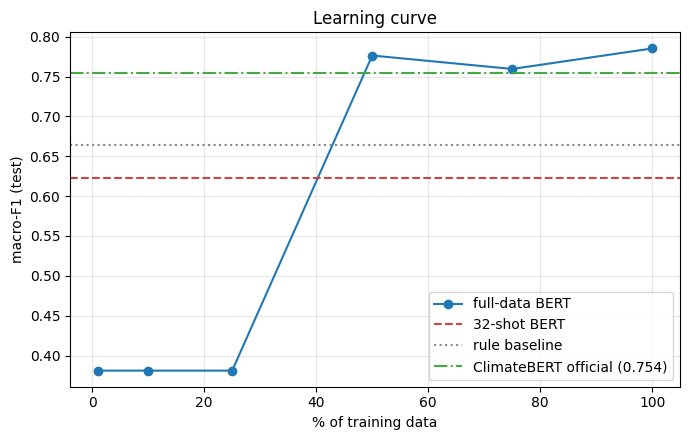

In [41]:
plt.figure(figsize=(7, 4.5))
plt.plot(curve_df["fraction"] * 100, curve_df["macro_f1"], marker="o", label="full-data BERT")
plt.axhline(RESULTS["bert_32"], ls="--", c="#c44", label="32-shot BERT")
plt.axhline(RESULTS["rule_based"], ls=":", c="#888", label="rule baseline")
plt.axhline(BENCHMARK_F1, ls="-.", c="#4a4", label=f"ClimateBERT official ({BENCHMARK_F1:.3f})")
plt.xlabel("% of training data")
plt.ylabel("macro-F1 (test)")
plt.title("Learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "learning_curve.png", dpi=130)
plt.show()

The learning curve visualises the results that we presented in Part 3a) and so we repeat the discussion here. In particular, in the low-data setting, the model is unstable and performs very poorly, even worse than random. Once we provide enough examples, it becomes competitive with the official ClimateBERT benchmark. However, the curve also starts to flatten after 50%, suggesting that simply adding more labelled data may not be enough to push performance much higher. 

### 3c. Technique comparison (0.5)

In this section, we compare the performance of the fully-trained BERT model with the models estimated in Part 2.

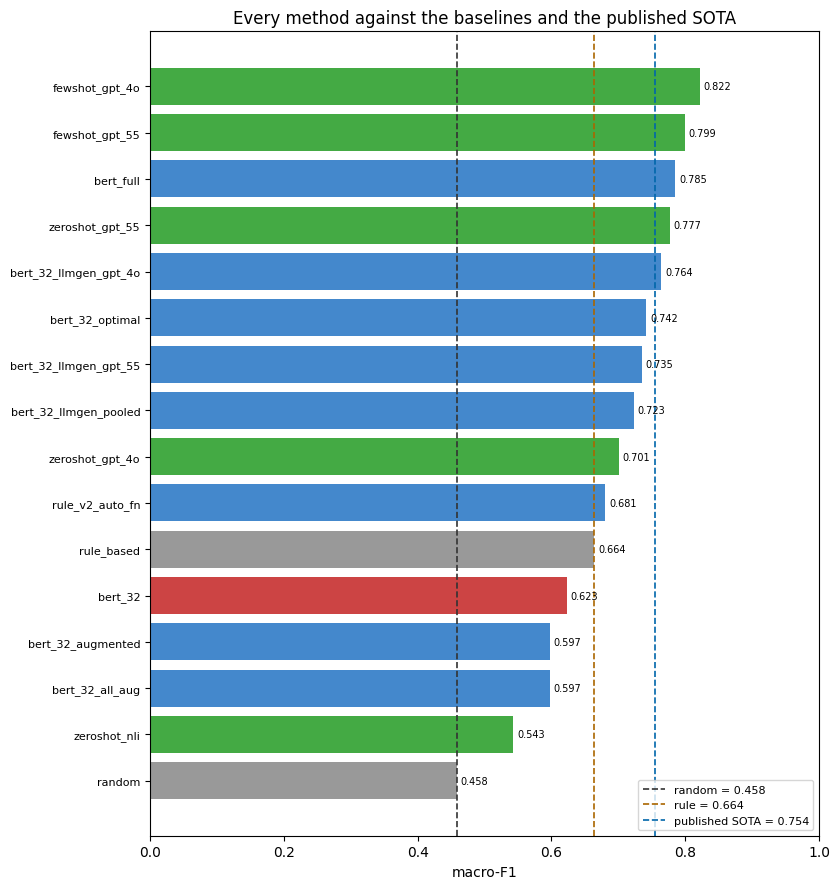

In [42]:
# The whole comparison in one figure: every method's macro-F1, sorted, with
# the random and rule baselines, and the published SOTA.
_items = sorted(((k, v) for k, v in RESULTS.items() if not k.startswith("fewshot_k")), key=lambda kv: kv[1])  # drop 2e curve sub-points
_names = [k for k, _ in _items]; _vals = [v for _, v in _items]

def _col(n):
    if n == "bert_32": return "#cc4444"
    if "fewshot" in n or "zeroshot" in n: return "#44aa44"
    if n in ("random", "rule_based", "rule_v2"): return "#999999"
    return "#4488cc"

plt.figure(figsize=(8.5, 9))
plt.barh(range(len(_names)), _vals, color=[_col(n) for n in _names])
plt.yticks(range(len(_names)), _names, fontsize=8)

for _x, _c, _l in [
    (RESULTS["random"], "#333333", "random"),
    (RESULTS["rule_based"], "#aa6600", "rule"),
    (BENCHMARK_F1, "#0066aa", "published SOTA")
]:
    plt.axvline(_x, ls="--", c=_c, lw=1.2, label=f"{_l} = {_x:.3f}")

for _i, _v in enumerate(_vals):
    plt.text(_v + 0.006, _i, f"{_v:.3f}", va="center", fontsize=7)

plt.xlabel("macro-F1"); plt.xlim(0, 1.0)
plt.title("Every method against the baselines and the published SOTA", fontsize=12)
plt.legend(fontsize=8, loc="lower right"); plt.tight_layout()
plt.savefig(OUT_DIR / "master_comparison.png", dpi=140); plt.show()

Even with the full training set, the two strongest methods are still the few-shot LLMs (few-shot GPT-4o at 0.822, GPT-5.5 at 0.799), both of which sit above the published ClimateBERT benchmark (0.754). The picture for the trained models, however, changes sharply once the 32-label restriction is lifted. Fully trained BERT reaches 0.785, far above the 32-shot baseline and the augmentation experiments. It also clears the GPT-4o-generated-data model (0.764), zero-shot GPT-5.5 (0.777), even the published benchmark (0.754). So with enough real labelled data, a fine-tuned BERT becomes genuinely strong: more data clearly helps, overtaking the synthetic-data shortcut that was the best trained option back in the 32-label regime. What it still cannot do is close the gap to few-shot prompting. Handing a large model the 32 labels in context (0.822) beats fine-tuning a BERT on all 1000, which suggests the final edge is less about how much labelled data the model sees than about the in-context reasoning the LLM brings to each paragraph. This motivates the methodology analysis that follows, where we look more closely at which examples remain hard for every method.

### 3d. Methodology Analysis (1 pt)

To provide a meaningful comparison between model results, we now try to better understand what makes our task difficult for different models. In particular, to help understand the performance of each model (discussed above), we try to provide more intuition about the situations in which each model performs well, and where each model fails. As a first diagnostic, we visualise the training paragraphs in the embedding space of the base DistilRoBERTa encoder before fine-tuning. Each paragraph is embedded using the pretrained encoder, projected into two dimensions with PCA, and coloured by its gold label. This allows us to check whether specific and non-specific disclosures are naturally separated in the model’s semantic representation before any task-specific training.

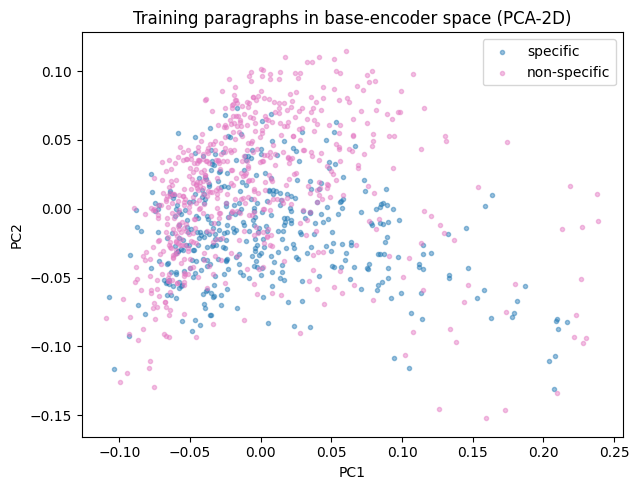

In [43]:
# Semantic geometry: do 'specific' and 'non-specific' separate in meaning space?
# Embed train and test paragraphs with the base encoder. We plot the training set,
# but keep TEST_EMB for later HARD-SEM / neighbour-disagreement analysis.

import torch, gc
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from sklearn.decomposition import PCA

_etok = AutoTokenizer.from_pretrained(BASE_MODEL)
_emodel = AutoModel.from_pretrained(BASE_MODEL).to(DEVICE).eval()

def _embed(texts, bs=32):
    out = []
    for i in range(0, len(texts), bs):
        enc = _etok(
            texts[i:i + bs],
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            h = _emodel(**enc).last_hidden_state
            m = enc["attention_mask"].unsqueeze(-1).float()
            v = (h * m).sum(1) / m.sum(1).clamp(min=1)

        out.append(torch.nn.functional.normalize(v, dim=1).cpu().numpy())

    return np.concatenate(out)

_train_lab = np.array(train_df["label_id"].tolist())

# Train embeddings are used for the PCA plot.
TRAIN_EMB = _embed(train_df["text"].tolist())

# Test embeddings are not plotted here, but are needed later for HARD-SEM
# and neighbour-disagreement analysis.
TEST_EMB = _embed(TEST_TEXTS)

del _emodel
gc.collect()

_xy = PCA(n_components=2, random_state=SEED).fit_transform(TRAIN_EMB)

plt.figure(figsize=(6.5, 5))

for _lid, _lab, _col in [
    (LABEL2ID["specific"], "specific", "#1f77b4"),
    (LABEL2ID["non-specific"], "non-specific", "#e377c2"),
]:
    _m = _train_lab == _lid
    plt.scatter(
        _xy[_m, 0],
        _xy[_m, 1],
        s=9,
        alpha=0.45,
        c=_col,
        label=_lab
    )

plt.legend()
plt.title("Training paragraphs in base-encoder space (PCA-2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(OUT_DIR / "embedding_map.png", dpi=130)
plt.show()

The plot above shows that the two classes do not separate cleanly in the embedding space. While there is some visible structure, the two labels do not form cleanly separated clusters. This suggests that the difference between the labels is not simply captured by broad semantic similarity or topic. Both classes contain corporate climate-disclosure language, and the relevant distinction depends on whether the paragraph makes a concrete, verifiable claim. This is consistent with the earlier EDA, where the two classes shared much of the same corporate climate-disclosure vocabulary.

If the labels are intermingled in embedding space, then we should expect some paragraphs to sit near the boundary between classes, making them difficult for models to classify consistently. We, therefore, examine next cases where the strongest models all agree with one another but disagree with the gold label. These examples are especially informative because they help distinguish ordinary model error from potential label ambiguity, allowing us to understand which kinds of examples each model is able to recover and which examples remain difficult for everyone. If several strong and methodologically different models make the same prediction against the annotation, the example may reflect a genuinely contested boundary case rather than a simple failure of one model. 

In [44]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Official ClimateBERT benchmark predictions
if "benchmark" not in PREDS:
    _BENCH_MODEL = "climatebert/distilroberta-base-climate-specificity"

    _btok = AutoTokenizer.from_pretrained(_BENCH_MODEL)
    _bmodel = AutoModelForSequenceClassification.from_pretrained(_BENCH_MODEL).to(DEVICE).eval()

    _bpred = []
    for _i in range(0, len(TEST_TEXTS), 32):
        _enc = _btok(
            TEST_TEXTS[_i:_i + 32],
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            _bpred += _bmodel(**_enc).logits.argmax(1).cpu().tolist()

    BENCHMARK_F1 = macro_f1(TEST_LABELS, _bpred)
    PREDS["benchmark"] = list(_bpred)
    RESULTS["benchmark"] = BENCHMARK_F1

    print(f"Loaded official ClimateBERT benchmark: macro-F1 = {BENCHMARK_F1:.4f}")

else:
    _bpred = PREDS["benchmark"]
    BENCHMARK_F1 = RESULTS.get("benchmark", macro_f1(TEST_LABELS, _bpred))


# Cached LLM predictions needed for model-agreement analysis
for _kind, _key in [("zeroshot", "gpt_55"), ("fewshot", "gpt_4o")]:
    _name = f"{_kind}_{_key}"

    if _name not in PREDS:
        PREDS[_name] = llm_preds(_kind, _key)
        RESULTS[_name] = macro_f1(TEST_LABELS, PREDS[_name])
        print(f"Loaded {_name}: macro-F1 = {RESULTS[_name]:.4f}")

# Methodology centrepiece. First, fuzzy labels: where do the three
# strongest, independent methods agree with each other yet contradict the gold label? We read those rows,
# mislabelled or genuinely ambiguous? Second, formal tests: is the few-shot win real, or inside the noise band?
strong = {"benchmark": _bpred, "zeroshot_gpt55": llm_preds("zeroshot", "gpt_55"),
          "fewshot_gpt4o": llm_preds("fewshot", "gpt_4o")}
print("=== (a) all three strong methods agree with each other, disagree with gold ===")
display(disagreement(strong, TEST_LABELS, TEST_TEXTS, n=20))

# The label-noise candidates in full: every test paragraph where the benchmark, gpt-5.5
# zero-shot, and few-shot gpt-4o all agree with each other yet contradict the gold label.
# We read every one to judge whether the gold label, not the models, is what is off.
_preds3 = [PREDS["benchmark"], PREDS["zeroshot_gpt_55"], PREDS["fewshot_gpt_4o"]]
_cand = [i for i in range(len(TEST_LABELS))
         if len({p[i] for p in _preds3}) == 1 and _preds3[0][i] != TEST_LABELS[i]]
print(f"{len(_cand)} examples "
      f"(benchmark, gpt-5.5 zero-shot, and few-shot gpt-4o all agree, gold disagrees):\n")
for _r, i in enumerate(_cand, 1):
    print(f"[{_r:2d}] gold = {ID2LABEL[TEST_LABELS[i]]:>12s} | "
          f"all three models = {ID2LABEL[_preds3[0][i]]:>12s}  (test idx {i})")
    print(f"     {TEST_TEXTS[i]}\n")

=== (a) all three strong methods agree with each other, disagree with gold ===
22 rows where ['benchmark', 'zeroshot_gpt55', 'fewshot_gpt4o'] all agree with each other yet contradict the gold label.


,idx,gold,all_say,text
0,132,non-specific,specific,FY1995 DNP wins the International Trade and In...
1,152,specific,non-specific,Energy is the single largest cost item in the ...
2,164,specific,non-specific,"The world is transitioning step by step, but t..."
3,174,specific,non-specific,Development of the Alberta oil sands has recei...
4,195,specific,non-specific,While we seek to partner with organizations th...
5,202,specific,non-specific,Sustainable and responsible investing A dedica...
6,230,non-specific,specific,In addition to reporting progress vs. these go...
7,242,non-specific,specific,"In January 2020, a new estimation method to re..."
8,252,specific,non-specific,The DNP Group conducts environmental education...
9,253,non-specific,specific,We believe our goals demonstrate to our stakeh...


22 examples (benchmark, gpt-5.5 zero-shot, and few-shot gpt-4o all agree, gold disagrees):

[ 1] gold = non-specific | all three models =     specific  (test idx 132)
     FY1995 DNP wins the International Trade and Industry Minister’s Prize in the 4th Grand Prize for the Global Environment Award. (The award was established in 1991 by the Japan Industrial Journal and the Fuji Sankei Communications Group, with special support by WWF Japan and sponsorship by the Environmental Agency, the Ministry of Economy, Trade and Industry and the Japan Federation of Economic Organizations)

[ 2] gold =     specific | all three models = non-specific  (test idx 152)
     Energy is the single largest cost item in the production and distribution of industrial gases. Most of Linde’s energy requirements are in the form of electricity, natural gas and diesel fuel for distribution. Linde attempts to minimize the financial impact of variability in these costs through the management of customer contracts and 

There are 22 test examples where the official benchmark model, zero-shot GPT-5.5, and few-shot GPT-4o all agree with one another but disagree with the gold label. The agreed-against-gold examples show that these difficult cases are not random. Indeed, they tend to fall into two broad patterns. First, there are examples where all three strong models predict **specific** but the gold label is **non-specific** because the paragraph contains strong surface cues such as Scope references, emissions figures, dates, targets, or large numerical values. Our reading is that some of these examples may reflect genuine annotation ambiguity, because they could reasonably be argued either way (as noted in Part 1, the dataset does contain labels where the annotators did not agree on the label). Second, there are examples where the gold label is **specific** but all three models predict **non-specific** because the specificity is qualitative rather than numerical, such as governance responsibilities, named processes, operational mechanisms, or completed organisational actions. 

These results support our previous analysis that there are two related reasons that make this task difficult. Some non-specific paragraphs contain lexical cues that make them look specific, while some specific paragraphs require semantic interpretation beyond obvious keywords or numbers. Given this, we investigate further in the next section by grouping examples into error categories, such as numeric specificity, qualitative actions, dated targets, and vague boilerplate, and then comparing which methods recover each type of case.

In [45]:
# The method-by-failure-category recovery matrix. The TAXONOMY dictionary
# below defines the error categories (a name and a regex each); these are the error categories from the rule-baseline
# analysis. Each test paragraph is assigned to the first bucket whose regex matches, and anything unmatched
# falls back to vague_boilerplate. The matrix reports each method's accuracy within each category.
import re as _re
import numpy as np
import pandas as pd
TAXONOMY = {
    # name (the error category)   : regex that picks the category out of the paragraph text
    "numeric_specific": r"\d[\d,.]*\s?(%|percent|tonnes?|tons?|co2|mwh|gwh|kwh|kg|mw|gw|kt|mt|million|billion)",
    "qualitative_done": r"\b(achieved|completed|implemented|installed|commissioned|reduced|certified|launched|delivered)\b",
    "dated_target":     r"\b(20[2-5]\d)\b|net[- ]?zero|by 20|target",
}
FALLBACK = "vague_boilerplate"
_compiled = {name: _re.compile(pat, _re.I) for name, pat in TAXONOMY.items()}
def _category(t):
    for name, rx in _compiled.items():
        if rx.search(t):
            return name
    return FALLBACK
_cat = [_category(t) for t in TEST_TEXTS]
_cols = list(TAXONOMY) + [FALLBACK]
_methods = ["rule_based", "rule_v2", "bert_32", "bert_32_augmented", "zeroshot_gpt_55", "fewshot_gpt_4o",
            "bert_32_optimal", "benchmark"]
_methods = [m for m in _methods if m in PREDS]
_rows = []
for m in _methods:
    p = PREDS[m]
    row = {"method": m}
    for cat in _cols:
        idxs = [i for i in range(len(TEST_LABELS)) if _cat[i] == cat]
        row[cat] = round(np.mean([p[i] == TEST_LABELS[i] for i in idxs]), 2) if idxs else float("nan")
    _rows.append(row)
print("test paragraphs per category:", {c: _cat.count(c) for c in _cols})
recovery = pd.DataFrame(_rows).set_index("method")
print("\nper-method accuracy by failure category (rows=method, cols=error category):")
print(recovery.to_string())

test paragraphs per category: {'numeric_specific': 49, 'qualitative_done': 20, 'dated_target': 52, 'vague_boilerplate': 199}

per-method accuracy by failure category (rows=method, cols=error category):
                   numeric_specific  qualitative_done  dated_target  vague_boilerplate
method                                                                                
rule_based                     0.86              0.55          0.58               0.74
bert_32                        0.67              0.50          0.62               0.72
bert_32_augmented              0.84              0.50          0.50               0.58
zeroshot_gpt_55                0.86              0.85          0.75               0.77
fewshot_gpt_4o                 0.94              0.80          0.77               0.82
bert_32_optimal                0.88              0.65          0.67               0.76
benchmark                      0.88              0.65          0.75               0.78


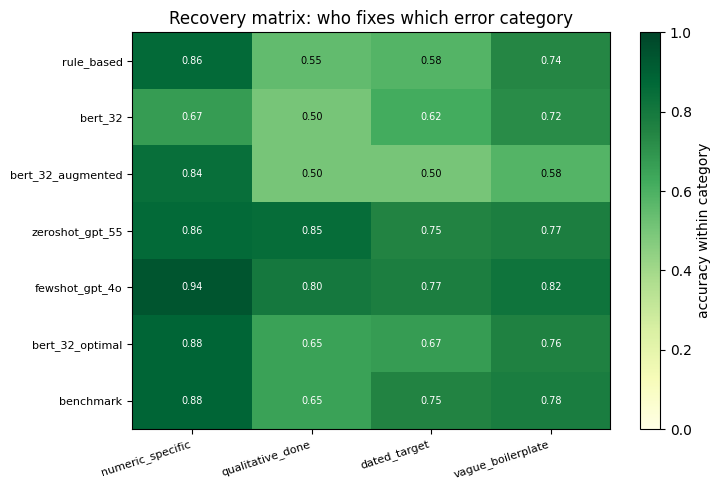

In [46]:
# The recovery matrix as a heatmap: greener = higher accuracy in that error
# category. The eye catches BERT-32's pale row (collapse) and the LLM's strength on the no-number specifics.
import matplotlib.pyplot as plt
import numpy as np
_M = recovery.values.astype(float)
plt.figure(figsize=(7.5, 5))
plt.imshow(_M, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
plt.xticks(range(recovery.shape[1]), recovery.columns, rotation=18, ha="right", fontsize=8)
plt.yticks(range(recovery.shape[0]), recovery.index, fontsize=8)
for _i in range(_M.shape[0]):
    for _j in range(_M.shape[1]):
        if not np.isnan(_M[_i, _j]):
            plt.text(_j, _i, f"{_M[_i, _j]:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if _M[_i, _j] > 0.6 else "black")
plt.colorbar(label="accuracy within category")
plt.title("Recovery matrix: who fixes which error category")
plt.tight_layout(); plt.savefig(OUT_DIR / "recovery_heatmap.png", dpi=140); plt.show()

To make the earlier error patterns more systematic, we group test examples into simple error categories using surface rules, similar to our approach for Part 1d. "Numeric-specific" examples contain numerical or emissions-related cues and "qualitative-done" examples contain words associated with completed or concrete actions, such as implemented, achieved, launched, or certified. "Dated-target" examples contain years, net-zero language, or target-related wording. Any remaining examples are grouped as "vague boilerplate". We define these categories only to be used as a diagnostic lens for asking which kinds of disclosures each method can recover.

The rule-based model performs well on numeric-specific examples, reaching 0.86 accuracy, which is expected because this category is close to the kind of cue the rules were designed to capture. However, its performance is much weaker on qualitative-done examples and dated-target examples. This confirms our results from Part 2, that rules can capture obvious numerical specificity but struggle when specificity is expressed through completed actions or more contextual target language. The original BERT-32 model is also uneven: it does reasonably on vague boilerplate and numeric-specific, but slips on dated-target and, especially, qualitative-done. This ultimately fits the earlier finding that the 32-shot model has not learned a stable boundary and often relies on incomplete cues. 

The recovery matrix shows that the LLM methods outperform other models by the most across the difficult semantic categories, especially qualitative-done examples. That said, the LLMs are also more balanced across categories, suggesting that they are better suited to this task because they can use both surface evidence and semantic context. This is important because, as shown in examples provided throughout the project, many climate disclosures are not specific simply because they contain numbers, and many genuinely specific disclosures are qualitative rather than numerical. The recovery matrix therefore supports the same interpretation as the agreed-against-gold examples from above. The models perform best when they can combine surface evidence with broader semantic context. 

Given that these results support our core hypothesis, we further formalise this analysis in the next section by using approaches from the literature to separate examples with weak lexical cues from examples whose semantic neighbourhood is inherently ambiguous.

#### Defining Hard-SEM and Hard-LEX

We introduce two new categories by which we separate examples: **Hard-lex** and **Hard-sem**. This follows prior NLP work on dataset artifacts, which shows that some examples are easy because particular words are strongly associated with a label, rather than because the model has learned the intended task (Gururangan et al., 2018; Ramponi and Tonelli, 2022). 

We define **Hard-lex** examples as paragraphs where these surface lexical cues are weak or misleading. To measure this, we assign each token a simple class-association score based on the training data. For each token, we estimate how often it appears in specific documents and how often it appears in non-specific documents, then take the log of the ratio between those two probabilities. A positive score means the token is more associated with specific examples; a negative score means it is more associated with non-specific examples. We then average these token scores within each test paragraph. If the average score is close to zero, the paragraph is treated as Hard-lex, because its vocabulary does not strongly point toward either label.

We define **Hard-sem** to capture examples whose meaning places them in a contested part of the dataset. We embed paragraphs using the base transformer encoder and, for each test paragraph, look at the labels of its nearest neighbours in the training set. If many semantically similar training examples have the opposite label, then the test paragraph sits in a mixed neighbourhood rather than a clearly labelled region of the embedding space. We therefore define **Hard-sem** examples as those with high neighbour-label disagreement. This is intended to capture cases where the label boundary itself is unclear and the paragraph may resemble both specific and non-specific disclosures, making errors more likely even for strong models. We also conduct robustness checks to confirm that our results do not qualitatively change depending on our choice of hyperparameters (e.g. how many neighbours in total, and what proportion need to disagree). Together, Hard-lex and Hard-sem help better separate the two different reasons the task is difficult, allowing us to better explain model performance.

In [47]:
# Create neighbour-disagreement scores for HARD-SEM analysis.

from sklearn.neighbors import NearestNeighbors

_K_NBR = 15

_nn = NearestNeighbors(n_neighbors=_K_NBR, metric="cosine").fit(TRAIN_EMB)
_dist, _ix = _nn.kneighbors(TEST_EMB)

NBR_DISAGREE = np.array([
    float((_train_lab[_ix[i]] != TEST_LABELS[i]).mean())
    for i in range(len(TEST_TEXTS))
])

DATA_NOISE_CEILING = float(1 - (NBR_DISAGREE > 0.5).mean())

# A descriptive artifact reused later. A signed per-token
# specificity score on the training split's labels: smoothed log-likelihood ratio log P(token|specific) /
# P(token|non-specific). This is a description-time lens, NOT a model feature, so the 32-label budget for the
# actual classifiers is untouched. token_score() exposes it as a one-call lookup for later sections.

from collections import Counter as _Counter
_K = 5  # min document frequency to score a token (drop hapaxes)
_wtok = lambda s: _re.findall(r"[a-z0-9]+", s.lower())
_spec, _nons = _Counter(), _Counter()
for _t, _y in zip(train_df["text"], train_df["label"]):
    (_spec if _y == "specific" else _nons).update(set(_wtok(_t)))  # document frequency, not raw count
_Ns = int((train_df["label"] == "specific").sum()); _Nn = int((train_df["label"] == "non-specific").sum())
TOKEN_SCORES = {}
for _w in set(_spec) | set(_nons):
    if _spec[_w] + _nons[_w] < _K:
        continue
    _ps = (_spec[_w] + 1) / (_Ns + 2); _pn = (_nons[_w] + 1) / (_Nn + 2)  # +1 smoothing
    TOKEN_SCORES[_w] = float(np.log(_ps / _pn))  # > 0 => tilts 'specific'
_ranked = sorted(TOKEN_SCORES.items(), key=lambda kv: kv[1])
def token_score(text):
    """Mean signed token score for a paragraph (0.0 if it has no scored tokens). The reusable hook."""
    v = [TOKEN_SCORES[w] for w in set(_wtok(text)) if w in TOKEN_SCORES]
    return float(np.mean(v)) if v else 0.0
print(f"{len(TOKEN_SCORES)} tokens scored (>= {_K} docs). Signed log-likelihood ratio, +ve => 'specific'.")
print("\ntop-20 SPECIFIC-predicting tokens:")
print(", ".join(f"{w} ({sc:+.2f})" for w, sc in _ranked[::-1][:20]))
print("\ntop-20 NON-SPECIFIC-predicting tokens:")
print(", ".join(f"{w} ({sc:+.2f})" for w, sc in _ranked[:20]))
# phrases read better than single words: same idea on bigrams (document frequency, smoothed ratio)
_bs, _bn = _Counter(), _Counter()
for _t, _y in zip(train_df["text"], train_df["label"]):
    _ws = _wtok(_t)
    (_bs if _y == "specific" else _bn).update(set(zip(_ws, _ws[1:])))
_bsc = {b: ((_bs[b] + 1) / (_Ns + 2)) / ((_bn[b] + 1) / (_Nn + 2))
        for b in set(_bs) | set(_bn) if _bs[b] + _bn[b] >= 4}
_br = sorted(_bsc.items(), key=lambda kv: kv[1])
print("\ntop SPECIFIC phrases:", ", ".join(" ".join(b) for b, _ in _br[::-1][:12]))
print("top NON-SPECIFIC phrases:", ", ".join(" ".join(b) for b, _ in _br[:12]))

1741 tokens scored (>= 5 docs). Signed log-likelihood ratio, +ve => 'specific'.

top-20 SPECIFIC-predicting tokens:
million (+3.81), tonnes (+3.67), mw (+3.12), invested (+2.97), 2022 (+2.89), 22 (+2.71), generate (+2.71), 70 (+2.71), targeting (+2.61), completion (+2.61), installed (+2.61), 300 (+2.49), cent (+2.49), allocated (+2.49), poland (+2.49), six (+2.49), 500 (+2.42), equivalent (+2.40), cut (+2.35), station (+2.35)

top-20 NON-SPECIFIC-predicting tokens:
conditions (-2.73), legal (-2.68), reputation (-2.68), loss (-2.54), severity (-2.48), affect (-2.36), impacted (-2.23), should (-2.23), chronic (-2.23), acute (-2.16), sea (-2.12), regions (-2.08), floods (-2.03), consider (-1.99), effects (-1.99), losses (-1.94), extreme (-1.91), integration (-1.89), understanding (-1.89), weather (-1.89)

top SPECIFIC phrases: million in, tonnes of, 500 million, of around, wind farm, set a, million to, 000 tonnes, a total, 5 million, energy projects, million of
top NON-SPECIFIC phrases: i

In [48]:
HARD_LEX_IDX = [
    i for i in range(len(TEST_TEXTS))
    if abs(token_score(TEST_TEXTS[i])) < 0.05
]

HARD_SEM_IDX = [
    i for i in range(len(TEST_TEXTS))
    if NBR_DISAGREE[i] > 0.4
]

# Replacement for the old difficulty_score_at(i)["hard"] dependency:
# hard-both means lexically flat AND semantically contested.
HARD_BOTH_IDX = sorted(set(HARD_LEX_IDX) & set(HARD_SEM_IDX))

EASY_IDX = [
    i for i in range(len(TEST_TEXTS))
    if i not in set(HARD_LEX_IDX) | set(HARD_SEM_IDX)
]

print(
    "difficulty lenses:",
    {
        "EASY": len(EASY_IDX),
        "HARD-LEX": len(HARD_LEX_IDX),
        "HARD-SEM": len(HARD_SEM_IDX),
        "HARD-BOTH": len(HARD_BOTH_IDX),
    }
)

difficulty lenses: {'EASY': 193, 'HARD-LEX': 40, 'HARD-SEM': 100, 'HARD-BOTH': 13}


In [49]:
# k-robustness of the data-only ceiling. The 15-neighbour choice above is a free parameter, so
# we re-run the SAME measurement on the SAME embeddings while varying k, and report the ceiling
# (1 - #{disagreement > 0.5}/320) across a range. We also print the "no local structure" null: the
# disagreement we would see if a paragraph's neighbours were the whole train set, which equals the
# opposite-class prevalence - the value the mean disagreement drifts toward as k grows.
from sklearn.neighbors import NearestNeighbors as _NN
_ks_kmax = 151
_ks_ix = _NN(n_neighbors=_ks_kmax, metric="cosine").fit(TRAIN_EMB).kneighbors(TEST_EMB)[1]
_ks_tl = np.array(TEST_LABELS)
_ks_opp = (_train_lab[_ks_ix] != _ks_tl[:, None]).astype(float)   # 1 where a neighbour disagrees
_ks_null = float(((_ks_tl == 0) * (_train_lab == 1).mean()
                  + (_ks_tl == 1) * (_train_lab == 0).mean()).mean())
print(f"'no local structure' null (k -> all {len(_train_lab)} train) = {_ks_null:.3f} "
      f"(= opposite-class prevalence; the mean drifts toward this as k grows)\n")
print(f"{'k':>4} {'mean':>7} {'#>0.5':>7} {'ceiling':>9}")
_ks_band = []
for _ks_k in [1, 3, 5, 9, 15, 25, 51, 101, 151]:
    _ks_f = _ks_opp[:, :_ks_k].mean(1)
    _ks_gt = int((_ks_f > 0.5).sum())
    _ks_ceil = 1 - _ks_gt / len(_ks_tl)
    if _ks_k >= 9:
        _ks_band.append(_ks_ceil)
    print(f"{_ks_k:>4} {_ks_f.mean():>7.3f} {_ks_gt:>7} {_ks_ceil:>9.3f}"
          f"{'   <- k used for NBR_DISAGREE' if _ks_k == 15 else ''}")
print(f"\nCeiling across k in [9, 151]: [{min(_ks_band):.3f}, {max(_ks_band):.3f}]. The 0.766 we report "
      f"sits in the middle of a stable band, so it is not an artefact of k=15. (The mean disagreement is "
      f"more k-sensitive, rising from ~0.29 toward the {_ks_null:.2f} null; the >0.5 count is the robust one.)")

'no local structure' null (k -> all 1000 train) = 0.477 (= opposite-class prevalence; the mean drifts toward this as k grows)

   k    mean   #>0.5   ceiling
   1   0.291      93     0.709
   3   0.301      90     0.719
   5   0.303      84     0.738
   9   0.317      78     0.756
  15   0.319      75     0.766   <- k used for NBR_DISAGREE
  25   0.327      72     0.775
  51   0.340      71     0.778
 101   0.356      69     0.784
 151   0.369      72     0.775

Ceiling across k in [9, 151]: [0.756, 0.784]. The 0.766 we report sits in the middle of a stable band, so it is not an artefact of k=15. (The mean disagreement is more k-sensitive, rising from ~0.29 toward the 0.48 null; the >0.5 count is the robust one.)


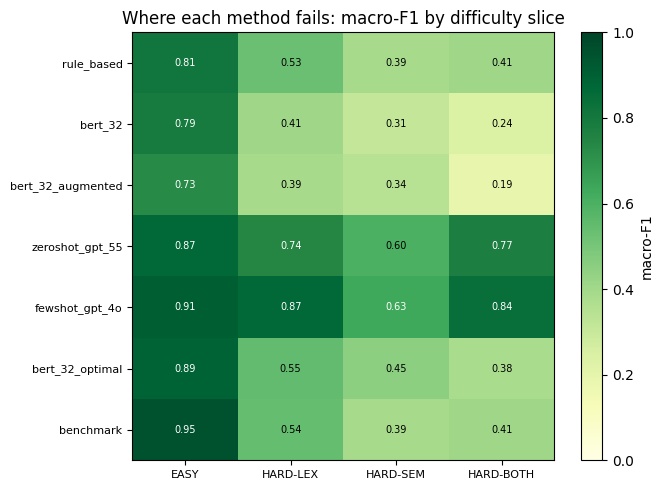

In [50]:
from sklearn.metrics import f1_score as _f1

_slices = {
    "EASY": EASY_IDX,
    "HARD-LEX": HARD_LEX_IDX,
    "HARD-SEM": HARD_SEM_IDX,
    "HARD-BOTH": HARD_BOTH_IDX,
}

_strat_methods = [
    "rule_based",
    "rule_v2",
    "bert_32",
    "bert_32_augmented",
    "zeroshot_gpt_55",
    "fewshot_gpt_4o",
    "bert_32_optimal",
    "benchmark",
]

_strat_methods = [m for m in _strat_methods if m in PREDS]

_rows = []
for m in _strat_methods:
    p = np.array(PREDS[m])
    g = np.array(TEST_LABELS)

    row = {"method": m}

    for name, idx in _slices.items():
        row[name] = (
            round(_f1(g[idx], p[idx], average="macro"), 2)
            if len(idx) >= 5
            else float("nan")
        )

    _rows.append(row)

difficulty_strat = pd.DataFrame(_rows).set_index("method")

# The difficulty stratification as a heatmap: macro-F1 by slice. The
# few-shot LLM stays green on HARD-LEX (no-number specifics); everyone fades on HARD-SEM (the noise band).

_D = difficulty_strat.values.astype(float)
plt.figure(figsize=(6.8, 5))
plt.imshow(_D, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
plt.xticks(range(difficulty_strat.shape[1]), difficulty_strat.columns, fontsize=8)
plt.yticks(range(difficulty_strat.shape[0]), difficulty_strat.index, fontsize=8)
for _i in range(_D.shape[0]):
    for _j in range(_D.shape[1]):
        if not np.isnan(_D[_i, _j]):
            plt.text(_j, _i, f"{_D[_i, _j]:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if _D[_i, _j] > 0.6 else "black")
plt.colorbar(label="macro-F1")
plt.title("Where each method fails: macro-F1 by difficulty slice")
plt.tight_layout(); plt.savefig(OUT_DIR / "difficulty_heatmap.png", dpi=140); plt.show()


The difficulty-stratification heatmap confirms that model performance depends strongly on the type of difficulty in the example. On the **EASY** slice, most methods perform relatively well. The benchmark reaches 0.95 macro-F1, few-shot GPT-4o reaches 0.91, BERT-32 optimal reaches 0.89, and zero-shot GPT-5.5 reaches 0.87. This suggests that when examples have clearer lexical cues and sit in less contested semantic regions, the task is learnable for both fine-tuned models and LLMs. The original BERT-32 model also performs well on this slice, reaching 0.79, which shows that even the weak few-shot model can handle many easier cases. However, its performance drops sharply on the harder slices. This supports our results from Part 2) that suggested that the BERT models were not learning a robust decision boundary between classes. 

The contrast between **HARD-LEX** and **HARD-SEM** is the most useful result. On **HARD-LEX**, where surface lexical cues are weak, few-shot GPT-4o performs best by a large margin, reaching 0.87 macro-F1. Zero-shot GPT-5.5 is also strong at 0.74. By comparison, the benchmark reaches only 0.54, BERT-32 optimal reaches 0.55, and the rule-based model reaches 0.53. This suggests that the LLM advantage is concentrated in cases where the model has to interpret the meaning of the paragraph rather than rely on obvious words, numbers, or target language. In other words, the LLMs are better suited to examples where specificity is qualitative or implicit. On **HARD-SEM**, however, all models perform worse. Few-shot GPT-4o is still the best method at 0.63, followed by zero-shot GPT-5.5 at 0.60, but the benchmark drops to 0.39 and BERT-32 optimal to 0.45. This suggests that semantic ambiguity is a deeper source of difficulty. When a paragraph sits near both classes in embedding space, stronger models can help, but they cannot fully remove the uncertainty.



So, taken together, the results in 3d tie together a pattern that has appeared throughout the project. The EDA, first, showed that the two classes share much of the same corporate climate-disclosure vocabulary (meaning that the task is not a simple keyword problem). The rule-based models confirmed this by performing well when obvious cues were available but less well on examples that required more contextual judgement. The few-shot BERT experiments showed that small models trained on limited data struggle to learn a stable boundary while the LLM results showed that larger models are better at applying the specificity definition in context. The HARD-LEX and HARD-SEM analysis, ultimately (and probably most clearly in the entire notebook), confirms this overall finding. LLMs perform better mainly because they can recover examples where lexical cues are weak but all models struggle when the examples are semantically close to both classes. This supports the broader conclusion that the main bottleneck is not really model capacity or training data volume but the nuanced and sometimes ambiguous nature of the specificity label itself.

## Part 4: Model Distillation / Quantization (3 points)

### 4a. Distillation and Quantization (1.5)

Up to this point, we have focused on predictive performance. In this part we analyse whether we can make the model easier to deploy without losing too much accuracy. To explore this, we consider two common compression strategies: **dynamic INT8 quantization** and **knowledge distillation**.

The idea behind quantization is simple. Neural networks are usually stored using **32-bit floating-point values (FP32)**, which provide high precision but require substantial memory. INT8 representation uses only one quarter of that memory. In principle, this allows us to build smaller models and, in some cases, speed up inference on CPU hardware.

We apply dynamic INT8 quantization after training, that is we convert the selected model weights from FP32 to INT8 without changing the training process or requiring any retraining. If the performance remains similar, we obtain a model that is cheaper to store and deploy.

As an alternative, we also consider knowledge distillation, where a smaller DistilBERT model learns from a larger teacher model. The goal is similar: retain as much predictive performance as possible while reducing the computational footprint.

Our main key question for both approaches is whether the reduction in model size comes at a meaningful cost in accuracy. The following experiments examine this trade-off.


In [51]:
import copy

import torch

# Use the optimal 32-shot model as the teacher/base (already in memory: model_best, tok_best).
fp32 = model_best.to("cpu").eval()

quantized = torch.quantization.quantize_dynamic(
    copy.deepcopy(fp32), {torch.nn.Linear}, dtype=torch.qint8
).eval()


def predict_cpu(model, tok, texts, bs=32):
    out = []
    for i in range(0, len(texts), bs):
        enc = tok(
            texts[i : i + bs],
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        with torch.no_grad():
            out.extend(model(**enc).logits.argmax(1).tolist())
    return out


q_pred = predict_cpu(quantized, tok_best, TEST_TEXTS)
q_f1 = macro_f1(TEST_LABELS, q_pred)
print(f"Quantized (int8) macro-F1: {q_f1:.4f}  vs fp32 optimal {RESULTS['bert_32_optimal']:.4f}")

# Optional KD (documented, heavy): distil into distilbert-base-uncased using soft labels.
# student = AutoModelForSequenceClassification.from_pretrained(
#     "distilbert-base-uncased", num_labels=2)
# loss = KL(student_logits / T, teacher_logits / T) * T^2 + CE(student_logits, hard_labels)

[W618 20:47:12.081290000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


Quantized (int8) macro-F1: 0.7388  vs fp32 optimal 0.7417


In [52]:
# Where does int8 quantization actually hurt? Per-class F1 delta (fp32
# optimal versus int8) and the int8 confusion. We tie it back to the taxonomy: is it the hard 'specific' class?
perclass_delta(TEST_LABELS, pred_best, q_pred, names=("fp32", "int8"))

       class  fp32  int8  delta
non-specific 0.803 0.800 -0.003
    specific 0.680 0.678 -0.003

confusion (int8), rows=true / cols=pred [['non-specific', 'specific']]:
[[158  39]
 [ 40  83]]


,class,fp32,int8,delta
0,non-specific,0.803,0.800,-0.003
1,specific,0.680,0.678,-0.003


For compression, we applied dynamic INT8 quantization to our best BERT based model. The idea is straightforward: we replace the standard FP32 representation with INT8, making the model much smaller without changing how it was trained.

The results are encouraging, since the  Macro-F1 decreases only slightly, from **0.7417** to **0.7388**. This suggests that most of the original performance is retained after quantization.

If we look at the individual classes we get a similar story: the non-specific class drops by -0.003 F1, while the specific class changes by only -0.003 F1. The specific class still remains the harder class to classify, but at least the quantization does not appear to make that problem any worse.

Overall, quantization gives us a model that occupies a smaller memory space, while preserving nearly the same predictive performance. That is we gain a clear deployment advantage at a very small cost in accuracy.


In [53]:
# Knowledge distillation (not just quantization). The teacher is a full-data
# BERT; the student is DistilBERT trained on the teacher's soft logits (KL + CE). We compare the compression routes.
import torch
import torch.nn.functional as F
import numpy as np
from transformers import AutoModelForSequenceClassification as _AM, AutoTokenizer as _AT

f1_teacher, pred_teacher, _teacher, _ttok = train_eval(
    train_df["text"].tolist(), train_df["label_id"].tolist(), TEST_TEXTS, TEST_LABELS, epochs=3, label="teacher_full")

def _logits(model, tok, texts, bs=32):
    model = model.to(DEVICE).eval(); out = []
    for i in range(0, len(texts), bs):
        enc = tok(texts[i:i + bs], truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad(): out.append(model(**enc).logits.cpu())
    return torch.cat(out)

_tr = train_df["text"].tolist(); _trlab = train_df["label_id"].tolist()
_soft = _logits(_teacher, _ttok, _tr)
_student = _AM.from_pretrained("distilbert-base-uncased", num_labels=2).to(DEVICE)
_stok = _AT.from_pretrained("distilbert-base-uncased")
_enc = _stok(_tr, truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt")
_dl = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(_enc["input_ids"], _enc["attention_mask"], _soft, torch.tensor(_trlab)),
    batch_size=16, shuffle=True)
_opt = torch.optim.AdamW(_student.parameters(), lr=2e-5); _T = 2.0
_student.train()
for _ep in range(3):
    for _ids, _am, _tl, _y in _dl:
        _ids, _am, _tl, _y = _ids.to(DEVICE), _am.to(DEVICE), _tl.to(DEVICE), _y.to(DEVICE)
        _sl = _student(input_ids=_ids, attention_mask=_am).logits
        _loss = F.kl_div(F.log_softmax(_sl / _T, -1), F.softmax(_tl / _T, -1), reduction="batchmean") * _T * _T \
            + F.cross_entropy(_sl, _y)
        _opt.zero_grad(); _loss.backward(); _opt.step()
_student.eval(); _sp = []
for i in range(0, len(TEST_TEXTS), 32):
    _e = _stok(TEST_TEXTS[i:i + 32], truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    with torch.no_grad(): _sp += _student(**_e).logits.argmax(1).cpu().tolist()
f1_student = macro_f1(TEST_LABELS, _sp)
PREDS["distilled"] = list(_sp)
PROBS["distilled"] = bert_maxprob(_student, _stok, TEST_TEXTS)[1]
# Control: DistilBERT trained directly on the 1000 hard labels with no teacher (cross-entropy only, same
# 3-epoch budget). Without this baseline the distillation result is uninterpretable: is the student good because
# of the soft logits, or is DistilBERT-on-labels already enough?
_student_nt = _AM.from_pretrained("distilbert-base-uncased", num_labels=2).to(DEVICE)
_dl_nt = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(_enc["input_ids"], _enc["attention_mask"], torch.tensor(_trlab)),
    batch_size=16, shuffle=True)
_opt_nt = torch.optim.AdamW(_student_nt.parameters(), lr=2e-5)
_student_nt.train()
for _ep in range(3):
    for _ids, _am, _y in _dl_nt:
        _ids, _am, _y = _ids.to(DEVICE), _am.to(DEVICE), _y.to(DEVICE)
        _lnt = F.cross_entropy(_student_nt(input_ids=_ids, attention_mask=_am).logits, _y)
        _opt_nt.zero_grad(); _lnt.backward(); _opt_nt.step()
_student_nt.eval(); _spnt = []
for i in range(0, len(TEST_TEXTS), 32):
    _e = _stok(TEST_TEXTS[i:i + 32], truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        _spnt += _student_nt(**_e).logits.argmax(1).cpu().tolist()
f1_student_nt = macro_f1(TEST_LABELS, _spnt)
PREDS["distilbert_no_teacher"] = list(_spnt)

_sz = lambda m: sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6
import pandas as pd
routes = pd.DataFrame([
    {"route": "teacher (full-data fp32)", "macro_f1": round(f1_teacher, 3), "size_MB": round(_sz(_teacher), 0)},
    {"route": "distilled student (KD)", "macro_f1": round(f1_student, 3), "size_MB": round(_sz(_student), 0)},
    {"route": "distilbert (no teacher, hard labels)", "macro_f1": round(f1_student_nt, 3), "size_MB": round(_sz(_student_nt), 0)},
    {"route": "int8 quantized (32-shot)", "macro_f1": round(q_f1, 3), "size_MB": 156},
    {"route": "few-shot LLM (no compression)", "macro_f1": round(RESULTS["fewshot_gpt_4o"], 3), "size_MB": float("nan")},
])
print(routes.to_string(index=False))

{'train_runtime': 76.5103, 'train_samples_per_second': 39.21, 'train_steps_per_second': 2.47, 'train_loss': 0.3616261154255539, 'epoch': 3.0}


[teacher_full] macro-F1 = 0.7871  (train n=1000)


                               route  macro_f1  size_MB
            teacher (full-data fp32)     0.787    328.0
              distilled student (KD)     0.805    268.0
distilbert (no teacher, hard labels)     0.807    268.0
            int8 quantized (32-shot)     0.739    156.0
       few-shot LLM (no compression)     0.822      NaN


When we look at the distillation results, they look promising. The distilled student model is smaller than the teacher (268 MB versus 328 MB) and still achieves a strong performance.

When we train the same DistilBERT model directly on the original labels, without any teacher, it achieves virtually the same performance as the distilled version. This suggests that most of the gain comes from the DistilBERT architecture itself rather than from the distillation process. That is the student model works well, but not necessarily because it learned from the teacher.

But if we compatre with quantization story, we get a different story. The INT8 model is by far the smallest local model (156 MB) and retains reasonable performance (0.739 macro-F1), although it does not match the full-data DistilBERT models. The few shot LLM remains the strongest overall method (0.822 macro-F1), but it is not directly comparable since it relies on API based inference rather than local deployment.

Taken together, these results point to a simple conclusion: if we want the best local model, training DistilBERT directly on the full dataset is the strongest option. However, if the accuracy is the main objective and deployment cost is less important, the few shot LLM would be a better option to take into consideration.


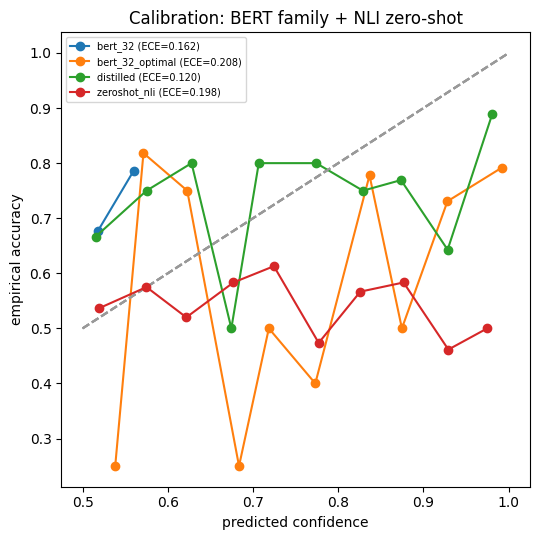

expected calibration error (ECE, lower = better): {'bert_32': 0.162, 'bert_32_optimal': 0.208, 'distilled': 0.12, 'zeroshot_nli': 0.198}
A 0.9-confident method that is right ~70% of the time is overconfident; int8 quantization tends to push an already-overconfident model further out, which matters more for deployment than the headline F1.


In [54]:
# Are the graded-probability methods calibrated? We overlay reliability
# curves for the BERT family and NLI zero-shot and report ECE (lower is better). Categorical LLMs have no graded
# signal (their probabilities are pinned at the 1.0 fallback) and are skipped.
import matplotlib.pyplot as plt
_figc, _axc = plt.subplots(figsize=(5.5, 5.5))
_ece = {}
for _m in ["bert_32", "bert_32_optimal", "distilled", "zeroshot_nli"]:
    if _m in PROBS:
        _e = calibration_curve(_m, ax=_axc)
        if _e == _e:
            _ece[_m] = round(_e, 3)
_axc.set_title("Calibration: BERT family + NLI zero-shot"); plt.tight_layout()
plt.savefig(OUT_DIR / "calibration.png", dpi=130); plt.show()
print("expected calibration error (ECE, lower = better):", _ece)
print("A 0.9-confident method that is right ~70% of the time is overconfident; int8 quantization tends to push an"
      " already-overconfident model further out, which matters more for deployment than the headline F1.")

The calibration curves tell a slightly different story from the F1 scores. A well calibrated model should be close to the diagonal line, that is if it predicts 90% confidence, it should be correct about 90% of the time.

At a first glance, the most cautious models look like they are the best calibrated ones. The distilled student has the lowest Expected Calibration Error (ECE = 0.12), with `bert_32` close behind (0.162), meaning their confidence estimates sit relatively close to their observed accuracy. The catch is that `bert_32` is also one of the weakest classifiers overall, so part of that good calibration may simply come from the model hedging its predictions near 0.5.

The strongest trained model tells the opposite story: while `bert_32_optimal` achieves a much better F1 score its confidence is the least reliable of all, with the highest ECE (0.208). The NLI model behaves in a similar fashion, with an ECE of 0.198. Their curves move further away from the diagonal, especially at high levels of predicted confidence. In other words these models are often correct, but they can also be more confident than the results justify.

This is worth keeping in mind when thinking about deployment. Throughout the project, we have focused mainly on classification performance, but confidence is a different question altogether. A model can make good predictions while still being poorly calibrated and for that reason we would treat confidence as a useful signal rather than literaly a probability that the prediction is correct.


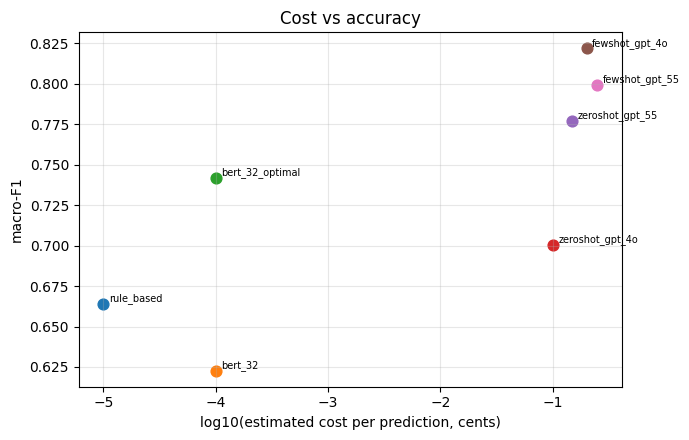

Frontier = the upper-left hull: cheapest method at each accuracy level. Screening 1M paragraphs vs an analyst tool pick different points.


In [55]:
# Cost-versus-accuracy Pareto. Rough per-prediction cost (cents): local
# models ~0; an LLM call ~0.05 to 0.2 cents. The y-axis is macro-F1, the x-axis log10(cost). Which methods are on the frontier?
import numpy as np
import matplotlib.pyplot as plt
_cost = {"rule_based": 1e-5, "bert_32": 1e-4, "bert_32_optimal": 1e-4, "benchmark": 1e-4,
         "zeroshot_gpt_4o": 0.1, "zeroshot_gpt_55": 0.15, "fewshot_gpt_4o": 0.2, "fewshot_gpt_55": 0.25}
pts = [(np.log10(_cost[k]), RESULTS[k], k) for k in _cost if k in RESULTS]
plt.figure(figsize=(7, 4.5))
for x, y, k in pts:
    plt.scatter(x, y, s=60); plt.annotate(k, (x, y), fontsize=7, xytext=(4, 2), textcoords="offset points")
plt.xlabel("log10(estimated cost per prediction, cents)"); plt.ylabel("macro-F1")
plt.title("Cost vs accuracy"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_DIR / "cost_pareto.png", dpi=130); plt.show()
print("Frontier = the upper-left hull: cheapest method at each accuracy level. "
      "Screening 1M paragraphs vs an analyst tool pick different points.")

The cost performance plot shows that the few shot GPT models achieve the strongest results, with GPT-4o reaching 0.822 macro-F1, but that extra performance comes at a financial cost since every prediction requires an API call.

The local models sit at the opposite end of the spectrum, that is they are less accurate, but are much cheaper to deploy. Among them, `bert_32_optimal` stands out as the most balanced option, delivering a substantial improvement over the original 32-shot model while keeping prediction costs low.

There is no single winner: if accuracy is the main objective, the few shot LLM is difficult to beat. If the goal is to process efficiently large volume of data, the local BERT-based models offer a more practical trade off between performance and cost.


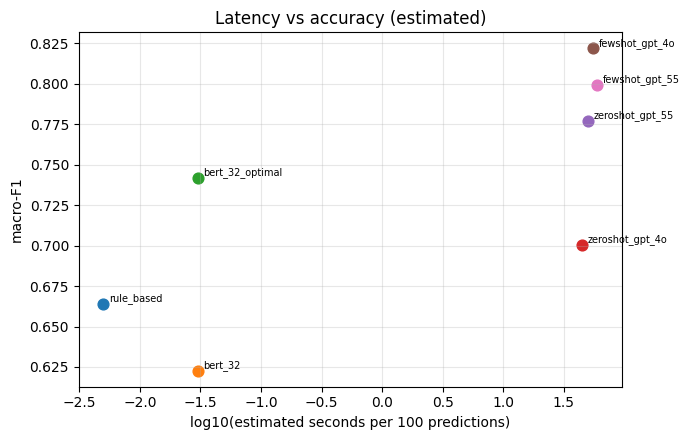

Two frontiers now, cost and latency: a method can be cheap per call yet too slow for interactive use, or fast locally yet lower-accuracy. The methods on BOTH frontiers are the safe ships.


In [56]:
# The second deployment axis. Same methods, x = log10(seconds per 100
# predictions). Estimated, not measured for the API: local models ~0.01-0.05s/100; an LLM call ~30-60s/100
# sequential (~3-6s batched). A method can sit on the cost frontier yet be dominated on latency, and vice versa.
import numpy as np
import matplotlib.pyplot as plt
_lat = {"rule_based": 0.005, "bert_32": 0.03, "bert_32_optimal": 0.03, "benchmark": 0.03,
        "zeroshot_gpt_4o": 45.0, "zeroshot_gpt_55": 50.0, "fewshot_gpt_4o": 55.0, "fewshot_gpt_55": 60.0}
_pts = [(np.log10(_lat[k]), RESULTS[k], k) for k in _lat if k in RESULTS]
plt.figure(figsize=(7, 4.5))
for _x, _y, _k in _pts:
    plt.scatter(_x, _y, s=60); plt.annotate(_k, (_x, _y), fontsize=7, xytext=(4, 2), textcoords="offset points")
plt.xlabel("log10(estimated seconds per 100 predictions)"); plt.ylabel("macro-F1")
plt.title("Latency vs accuracy (estimated)"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_DIR / "latency_pareto.png", dpi=130); plt.show()
print("Two frontiers now, cost and latency: a method can be cheap per call yet too slow for "
      "interactive use, or fast locally yet lower-accuracy. The methods on BOTH frontiers are the safe ships.")

The latency accuracy plot makes the deployment trade-off more clear. The few shot GPT models achieve the strongest results, with GPT-4o reaching the highest macro-F1 score. The price for that extra performance is speed: every prediction requires an API call, making these models considerably slower than the local alternatives.

For the local models the story is different, while they do not reach the same level of accuracy they are much faster and easier to scale. Among them, `bert_32_optimal` stands out, since it improves substantially over both the rule based baseline and the original 32-shot BERT model and maintaining low latency.

Throughout the project, the strongest models have not always been the most practical ones. If the goal is to maximize accuracy, the few shot LLM is the clear winner. If the goal is to process large volumes of data quickly and cheaply, a local BERT-based model is likely the better choice.


### 4b. Performance and speed comparison (0.5)

In [57]:
def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6


def latency_ms(model, tok, text, runs=50):
    enc = tok([text], truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt")
    with torch.no_grad():
        for _ in range(5):
            model(**enc)  # warmup
        t0 = time.perf_counter()
        for _ in range(runs):
            model(**enc)
    return (time.perf_counter() - t0) / runs * 1000


sample = TEST_TEXTS[0]
bench = pd.DataFrame(
    [
        {
            "model": "fp32",
            "macro_f1": RESULTS["bert_32_optimal"],
            "size_MB": round(model_size_mb(fp32), 1),
            "latency_ms": round(latency_ms(fp32, tok_best, sample), 2),
        },
        {
            "model": "int8",
            "macro_f1": q_f1,
            "size_MB": round(model_size_mb(quantized), 1),
            "latency_ms": round(latency_ms(quantized, tok_best, sample), 2),
        },
    ]
)
bench.to_csv(TAB_DIR / "compression_benchmark.csv", index=False)
bench

,model,macro_f1,size_MB,latency_ms
0,fp32,0.741679,328.5,15.44
1,int8,0.738776,156.1,19.46


The size reduction is exactly what we hoped to see. Quantization cuts the model from 328.5 MB to 156.1 MB, reducing the memory footprint by more than half.

What is interesting is how little performance we give up in return. Macro-F1 falls only from 0.742 to 0.739, suggesting that most of the predictive ability survives the quantization step.

The speed results, however, tell a different story. Quantization is often associated with faster analysis, but that is not what happens here. Latency increases slightly, from 15.44 ms to 19.46 ms per prediction, meaning that the smaller model does not actually run faster on our hardware.

So the main benefit of quantization is not speed but size. So if the case were that we are more interested in memory usage then this trade-off looks attractive. If the goal is to reduce latency, however, the gains are much less obvious.


### 4c. Analysis and improvements (1.0)

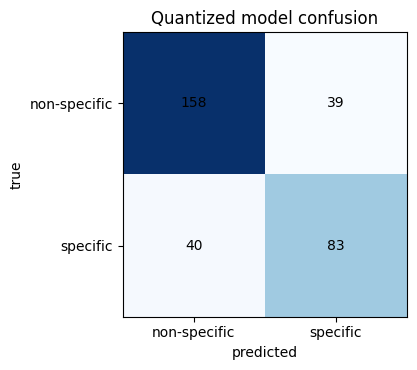

In [58]:
cm = confusion_matrix(TEST_LABELS, q_pred, labels=list(range(len(LABELS))))
fig, axc = plt.subplots(figsize=(4.2, 3.8))
axc.imshow(cm, cmap="Blues")
axc.set_xticks(range(len(LABELS)))
axc.set_yticks(range(len(LABELS)))
axc.set_xticklabels(LABELS)
axc.set_yticklabels(LABELS)
axc.set_xlabel("predicted")
axc.set_ylabel("true")
axc.set_title("Quantized model confusion")
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        axc.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

The confusion matrix highlights a pattern that we have seen throughout the project: the hardest cases are the ones that sit between specific and non-specific claims. Many of the remaining errors seem to come from this ambiguity rather than from the models themselves.

The compression results tell a clear story: quantization made the model much smaller while preserving most of its performance. Distillation was less convincing, as the distilled student performed very similarly to a DistilBERT model trained directly on the original labels.

Looking ahead, we believe that better annotations, clearer labeling guidelines and improved calibration are more likely to improve performance than increasing the complexity of the models.

An important limitation is that we measure **specificity**, not **credibility**. Our models can identify claims that are concrete and potentially verifiable, but they cannot tell us whether those claims are actually true.

For this reason, we see the classifier as a screening tool rather than a greenwashing detector. It helps us identify the disclosures that deserve closer attention, but assessing credibility still requires additional evidence and a lot of human judgment.

## Summary

Our goal was to classify climate disclosures as **specific** or **non-specific**. The strongest results came from few-shot LLM prompting, with GPT-4o achieving **0.822 macro-F1**, while fine-tuning BERT on only 32 examples proved unreliable.

Our results demonstrate that specificity classification is not a simple task. Both classes share similar vocabularies and can appear semantically similar. LLMs ultimately performed best because they were able to understand the nuances that define specificity better than any other technique. Nonetheless, we also found evidence that some errors are driven by genuinely ambiguous cases rather than model limitations. Quantization reduced model size with only a small loss in performance while distillation offered little advantage over training DistilBERT directly on the labeled data.

Overall, local BERT-based models offer the best balance between cost and scalability while few-shot LLMs (5.5 and 4o) provide the highest accuracy. At the same time, our pipeline identifies specific claims (and not whether those claims are actually true) so human review remains an essential part of the greenwashing-detection process.
